In [ ]:
# ============================================================
# STEP 1 — EXTRACT UJIIndoorLoc AND INSPECT THE DATASET
# ============================================================

import os
import zipfile
import pandas as pd
import numpy as np

ZIP_PATH = "/content/ujiindoorloc.zip"
EXTRACT_DIR = "/content/ujiindoorloc"

print("=" * 70)
print("STEP 1: DATASET EXTRACTION AND INSPECTION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check ZIP file
# ------------------------------------------------------------
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"ZIP file not found at {ZIP_PATH}. "
        "Please make sure ujiindoorloc.zip is uploaded to Colab."
    )

file_size_mb = os.path.getsize(ZIP_PATH) / (1024 ** 2)
print(f"ZIP found: {ZIP_PATH}")
print(f"ZIP size: {file_size_mb:.2f} MB")

# ------------------------------------------------------------
# 2. Extract safely
# ------------------------------------------------------------
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    bad_file = z.testzip()
    if bad_file is not None:
        raise zipfile.BadZipFile(
            f"Corrupted ZIP file. First bad file: {bad_file}"
        )

    z.extractall(EXTRACT_DIR)

print("\nExtraction completed successfully.")

# ------------------------------------------------------------
# 3. Show extracted files
# ------------------------------------------------------------
all_files = []

for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        full_path = os.path.join(root, f)
        all_files.append(full_path)

print(f"\nNumber of extracted files: {len(all_files)}")

for f in all_files[:50]:
    print(" -", f)

# ------------------------------------------------------------
# 4. Find CSV files
# ------------------------------------------------------------
csv_files = [
    f for f in all_files
    if f.lower().endswith(".csv")
]

print(f"\nCSV files found: {len(csv_files)}")

for f in csv_files:
    print(" -", f)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV files were found after extraction."
    )

# ------------------------------------------------------------
# 5. Identify likely training/test files
# ------------------------------------------------------------
train_candidates = [
    f for f in csv_files
    if "train" in os.path.basename(f).lower()
]

test_candidates = [
    f for f in csv_files
    if "test" in os.path.basename(f).lower()
]

print("\nTraining candidates:")
for f in train_candidates:
    print(" -", f)

print("\nTesting candidates:")
for f in test_candidates:
    print(" -", f)

# ------------------------------------------------------------
# 6. Load the first likely training CSV
# ------------------------------------------------------------
if train_candidates:
    train_path = train_candidates[0]
else:
    # Fallback: choose the largest CSV
    train_path = max(csv_files, key=os.path.getsize)

print(f"\nSelected dataset file:")
print(train_path)

# ------------------------------------------------------------
# 7. Read dataset
# ------------------------------------------------------------
df = pd.read_csv(train_path)

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

print("\nColumn names:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 8. Display first rows
# ------------------------------------------------------------
print("\nFirst 5 rows:")
display(df.head())

# ------------------------------------------------------------
# 9. Data types
# ------------------------------------------------------------
print("\nData types:")
print(df.dtypes.value_counts())

# ------------------------------------------------------------
# 10. Missing values
# ------------------------------------------------------------
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0].sort_values(ascending=False)

print("\nMissing-value summary:")
if len(missing_nonzero) == 0:
    print("No missing values.")
else:
    print(missing_nonzero)

# ------------------------------------------------------------
# 11. Identify important metadata columns
# ------------------------------------------------------------
possible_metadata = [
    "BUILDINGID",
    "FLOOR",
    "SPACEID",
    "RELATIVEPOSITION",
    "USERID",
    "PHONEID",
    "TIMESTAMP",
    "LONGITUDE",
    "LATITUDE"
]

print("\nDetected important columns:")
for col in possible_metadata:
    if col in df.columns:
        print(f" - {col}")

# ------------------------------------------------------------
# 12. Check RSSI/AP columns
# ------------------------------------------------------------
ap_columns = []

for col in df.columns:
    col_str = str(col)
    if col_str.startswith("WAP"):
        ap_columns.append(col)

print(f"\nWi-Fi AP signal columns detected: {len(ap_columns)}")

if ap_columns:
    print("First 15 AP columns:")
    print(ap_columns[:15])

    print("\nExample AP signal statistics:")
    print(df[ap_columns[:10]].describe().T)

# ------------------------------------------------------------
# 13. Basic value inspection
# ------------------------------------------------------------
print("\nUnique-value counts for important metadata:")
for col in possible_metadata:
    if col in df.columns:
        print(
            f"{col:20s} -> "
            f"{df[col].nunique(dropna=True):,} unique values"
        )

print("\n" + "=" * 70)
print("STEP 1 COMPLETED")
print("=" * 70)

STEP 1: DATASET EXTRACTION AND INSPECTION
ZIP found: /content/ujiindoorloc.zip
ZIP size: 1.40 MB

Extraction completed successfully.

Number of extracted files: 2
 - /content/ujiindoorloc/UJIndoorLoc/validationData.csv
 - /content/ujiindoorloc/UJIndoorLoc/trainingData.csv

CSV files found: 2
 - /content/ujiindoorloc/UJIndoorLoc/validationData.csv
 - /content/ujiindoorloc/UJIndoorLoc/trainingData.csv

Training candidates:
 - /content/ujiindoorloc/UJIndoorLoc/trainingData.csv

Testing candidates:

Selected dataset file:
/content/ujiindoorloc/UJIndoorLoc/trainingData.csv

DATASET SUMMARY
Rows    : 19,937
Columns : 529

Column names:
['WAP001', 'WAP002', 'WAP003', 'WAP004', 'WAP005', 'WAP006', 'WAP007', 'WAP008', 'WAP009', 'WAP010', 'WAP011', 'WAP012', 'WAP013', 'WAP014', 'WAP015', 'WAP016', 'WAP017', 'WAP018', 'WAP019', 'WAP020', 'WAP021', 'WAP022', 'WAP023', 'WAP024', 'WAP025', 'WAP026', 'WAP027', 'WAP028', 'WAP029', 'WAP030', 'WAP031', 'WAP032', 'WAP033', 'WAP034', 'WAP035', 'WAP036', '

,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710



Data types:
int64      527
float64      2
Name: count, dtype: int64

Missing-value summary:
No missing values.

Detected important columns:
 - BUILDINGID
 - FLOOR
 - SPACEID
 - RELATIVEPOSITION
 - USERID
 - PHONEID
 - TIMESTAMP
 - LONGITUDE
 - LATITUDE

Wi-Fi AP signal columns detected: 520
First 15 AP columns:
['WAP001', 'WAP002', 'WAP003', 'WAP004', 'WAP005', 'WAP006', 'WAP007', 'WAP008', 'WAP009', 'WAP010', 'WAP011', 'WAP012', 'WAP013', 'WAP014', 'WAP015']

Example AP signal statistics:
          count        mean        std    min    25%    50%    75%    max
WAP001  19937.0   99.823644   5.866842  -97.0  100.0  100.0  100.0  100.0
WAP002  19937.0   99.820936   5.798156  -90.0  100.0  100.0  100.0  100.0
WAP003  19937.0  100.000000   0.000000  100.0  100.0  100.0  100.0  100.0
WAP004  19937.0  100.000000   0.000000  100.0  100.0  100.0  100.0  100.0
WAP005  19937.0   99.613733   8.615657  -97.0  100.0  100.0  100.0  100.0
WAP006  19937.0   97.130461  22.931890  -98.0  100.0  100.0 

In [ ]:
# ============================================================
# STEP 2 — CLEAN RSSI FEATURES AND CREATE LINK-QUALITY LABEL
# ============================================================

import os
import numpy as np
import pandas as pd

print("=" * 70)
print("STEP 2: RSSI CLEANING + LINK QUALITY LABEL CREATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------
TRAIN_PATH = "/content/ujiindoorloc/UJIndoorLoc/trainingData.csv"
VAL_PATH   = "/content/ujiindoorloc/UJIndoorLoc/validationData.csv"

# ------------------------------------------------------------
# 2. Load datasets
# ------------------------------------------------------------
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Training shape   : {train_df.shape}")
print(f"Validation shape : {val_df.shape}")

# ------------------------------------------------------------
# 3. Identify WAP/RSSI columns
# ------------------------------------------------------------
wap_columns = [
    col for col in train_df.columns
    if str(col).startswith("WAP")
]

print(f"\nNumber of WAP/RSSI features: {len(wap_columns)}")

if len(wap_columns) != 520:
    print("WARNING: Expected approximately 520 WAP columns.")

# ------------------------------------------------------------
# 4. The UJIIndoorLoc dataset uses 100 for an
#    undetected / unavailable access point.
#    Convert it to NaN for signal calculations.
# ------------------------------------------------------------
train_rssi = train_df[wap_columns].replace(100, np.nan)
val_rssi   = val_df[wap_columns].replace(100, np.nan)

# ------------------------------------------------------------
# 5. Basic signal statistics for every observation
# ------------------------------------------------------------

# Strongest detected access-point signal
train_max_rssi = train_rssi.max(axis=1)
val_max_rssi   = val_rssi.max(axis=1)

# Average detected signal
train_mean_rssi = train_rssi.mean(axis=1)
val_mean_rssi   = val_rssi.mean(axis=1)

# Number of detected access points
train_detected_count = train_rssi.notna().sum(axis=1)
val_detected_count   = val_rssi.notna().sum(axis=1)

# ------------------------------------------------------------
# 6. Handle rows with no detected APs
# ------------------------------------------------------------
train_max_rssi = train_max_rssi.fillna(-100)
val_max_rssi   = val_max_rssi.fillna(-100)

train_mean_rssi = train_mean_rssi.fillna(-100)
val_mean_rssi   = val_mean_rssi.fillna(-100)

# ------------------------------------------------------------
# 7. Create a 4-level wireless link-quality target
#
#    Excellent : strongest RSSI >= -55 dBm
#    Good      : -65 <= RSSI < -55 dBm
#    Fair      : -75 <= RSSI < -65 dBm
#    Poor      : RSSI < -75 dBm
#
#    NOTE:
#    This is a DERIVED target because UJIIndoorLoc does not
#    contain a native link-quality label.
# ------------------------------------------------------------

def create_quality_label(max_rssi):
    if max_rssi >= -55:
        return 3       # Excellent
    elif max_rssi >= -65:
        return 2       # Good
    elif max_rssi >= -75:
        return 1       # Fair
    else:
        return 0       # Poor

train_quality = train_max_rssi.apply(create_quality_label)
val_quality   = val_max_rssi.apply(create_quality_label)

quality_names = {
    0: "Poor",
    1: "Fair",
    2: "Good",
    3: "Excellent"
}

train_quality_names = train_quality.map(quality_names)
val_quality_names   = val_quality.map(quality_names)

# ------------------------------------------------------------
# 8. Print quality distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING LINK-QUALITY DISTRIBUTION")
print("=" * 70)

train_counts = train_quality_names.value_counts()
train_percent = train_quality_names.value_counts(normalize=True) * 100

for class_id, class_name in quality_names.items():
    count = int(train_counts.get(class_name, 0))
    pct = float(train_percent.get(class_name, 0))
    print(f"{class_id} - {class_name:10s}: {count:6d} samples ({pct:6.2f}%)")

print("\n" + "=" * 70)
print("VALIDATION LINK-QUALITY DISTRIBUTION")
print("=" * 70)

val_counts = val_quality_names.value_counts()
val_percent = val_quality_names.value_counts(normalize=True) * 100

for class_id, class_name in quality_names.items():
    count = int(val_counts.get(class_name, 0))
    pct = float(val_percent.get(class_name, 0))
    print(f"{class_id} - {class_name:10s}: {count:6d} samples ({pct:6.2f}%)")

# ------------------------------------------------------------
# 9. Create client information
# ------------------------------------------------------------

if "PHONEID" not in train_df.columns:
    raise ValueError("PHONEID column was not found.")

train_clients = train_df["PHONEID"]
val_clients   = val_df["PHONEID"]

print("\n" + "=" * 70)
print("FEDERATED CLIENT INFORMATION")
print("=" * 70)

print("Training clients:", sorted(train_clients.unique().tolist()))
print("Number of training clients:", train_clients.nunique())

print("\nSamples per training client:")
print(train_clients.value_counts().sort_index())

# ------------------------------------------------------------
# 10. Measure link statistics by client
# ------------------------------------------------------------

client_summary = pd.DataFrame({
    "PHONEID": train_clients,
    "Max_RSSI": train_max_rssi,
    "Mean_RSSI": train_mean_rssi,
    "Detected_APs": train_detected_count,
    "Quality": train_quality
})

client_summary_stats = client_summary.groupby("PHONEID").agg(
    samples=("PHONEID", "size"),
    avg_max_rssi=("Max_RSSI", "mean"),
    avg_mean_rssi=("Mean_RSSI", "mean"),
    avg_detected_aps=("Detected_APs", "mean"),
    poor_rate=("Quality", lambda x: (x == 0).mean()),
    fair_rate=("Quality", lambda x: (x == 1).mean()),
    good_rate=("Quality", lambda x: (x == 2).mean()),
    excellent_rate=("Quality", lambda x: (x == 3).mean())
)

print("\n" + "=" * 70)
print("CLIENT / NON-IID INSPECTION")
print("=" * 70)

display(client_summary_stats.round(3))

# ------------------------------------------------------------
# 11. Save processed metadata for the next steps
# ------------------------------------------------------------

processed_train = train_df.copy()
processed_val = val_df.copy()

processed_train["MAX_RSSI"] = train_max_rssi
processed_train["MEAN_RSSI"] = train_mean_rssi
processed_train["DETECTED_APS"] = train_detected_count
processed_train["LINK_QUALITY"] = train_quality
processed_train["LINK_QUALITY_NAME"] = train_quality_names

processed_val["MAX_RSSI"] = val_max_rssi
processed_val["MEAN_RSSI"] = val_mean_rssi
processed_val["DETECTED_APS"] = val_detected_count
processed_val["LINK_QUALITY"] = val_quality
processed_val["LINK_QUALITY_NAME"] = val_quality_names

# ------------------------------------------------------------
# 12. Store in memory for the next cells
# ------------------------------------------------------------

X_train_raw = train_rssi.copy()
X_val_raw = val_rssi.copy()

y_train = train_quality.astype(np.int32).values
y_val = val_quality.astype(np.int32).values

client_train = train_clients.astype(np.int32).values
client_val = val_clients.astype(np.int32).values

# ------------------------------------------------------------
# 13. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PROCESSED DATA SUMMARY")
print("=" * 70)

print(f"X_train shape : {X_train_raw.shape}")
print(f"X_val shape   : {X_val_raw.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_val shape   : {y_val.shape}")

print(f"\nTrain clients : {len(np.unique(client_train))}")
print(f"Val clients   : {len(np.unique(client_val))}")

print("\nExample target labels:")
for i in range(4):
    print(f"{i} -> {quality_names[i]}")

print("\n" + "=" * 70)
print("STEP 2 COMPLETED")
print("=" * 70)

STEP 2: RSSI CLEANING + LINK QUALITY LABEL CREATION
Training shape   : (19937, 529)
Validation shape : (1111, 529)

Number of WAP/RSSI features: 520

TRAINING LINK-QUALITY DISTRIBUTION
0 - Poor      :   1281 samples (  6.43%)
1 - Fair      :   3034 samples ( 15.22%)
2 - Good      :   7256 samples ( 36.39%)
3 - Excellent :   8366 samples ( 41.96%)

VALIDATION LINK-QUALITY DISTRIBUTION
0 - Poor      :     35 samples (  3.15%)
1 - Fair      :    159 samples ( 14.31%)
2 - Good      :    365 samples ( 32.85%)
3 - Excellent :    552 samples ( 49.68%)

FEDERATED CLIENT INFORMATION
Training clients: [1, 3, 6, 7, 8, 10, 11, 13, 14, 16, 17, 18, 19, 22, 23, 24]
Number of training clients: 16

Samples per training client:
PHONEID
1      507
3      610
6     1383
7     1596
8      913
10     440
11     498
13    4516
14    4835
16     192
17     841
18     374
19     980
22     724
23    1091
24     437
Name: count, dtype: int64

CLIENT / NON-IID INSPECTION


,samples,avg_max_rssi,avg_mean_rssi,avg_detected_aps,poor_rate,fair_rate,good_rate,excellent_rate
PHONEID,,,,,,,,
1,507,-66.430,-84.071,10.037,0.221,0.183,0.357,0.239
3,610,-54.382,-76.438,17.207,0.010,0.162,0.270,0.557
6,1383,-61.737,-77.653,17.051,0.163,0.228,0.294,0.315
7,1596,-56.744,-80.843,23.691,0.040,0.157,0.419,0.384
8,913,-59.262,-80.060,17.426,0.076,0.181,0.380,0.364
10,440,-66.082,-83.572,14.282,0.123,0.389,0.334,0.155
11,498,-51.333,-75.025,22.430,0.000,0.052,0.263,0.685
13,4516,-58.839,-80.188,15.549,0.048,0.171,0.391,0.391
14,4835,-54.448,-74.553,17.975,0.023,0.099,0.353,0.525



PROCESSED DATA SUMMARY
X_train shape : (19937, 520)
X_val shape   : (1111, 520)
y_train shape : (19937,)
y_val shape   : (1111,)

Train clients : 16
Val clients   : 11

Example target labels:
0 -> Poor
1 -> Fair
2 -> Good
3 -> Excellent

STEP 2 COMPLETED


In [ ]:
# ============================================================
# STEP 3 — STRICT TRAIN / VALIDATION / TEST SPLIT
#           FOR NON-IID FEDERATED LEARNING
# ============================================================

import os
import random
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("=" * 75)
print("STEP 3: STRICT TRAIN / VALIDATION / TEST FEDERATED SPLIT")
print("=" * 75)

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# 2. Paths
# ------------------------------------------------------------
TRAIN_PATH = "/content/ujiindoorloc/UJIndoorLoc/trainingData.csv"
EXTERNAL_PATH = "/content/ujiindoorloc/UJIndoorLoc/validationData.csv"

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(TRAIN_PATH)

if not os.path.exists(EXTERNAL_PATH):
    raise FileNotFoundError(EXTERNAL_PATH)

# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------
df = pd.read_csv(TRAIN_PATH)
external_df = pd.read_csv(EXTERNAL_PATH)

print("\nOriginal training dataset :", df.shape)
print("External dataset          :", external_df.shape)

# ------------------------------------------------------------
# 4. Detect WAP features
# ------------------------------------------------------------
wap_columns = [
    c for c in df.columns
    if str(c).startswith("WAP")
]

print("\nOriginal WAP features:", len(wap_columns))

# ------------------------------------------------------------
# 5. Convert missing WAP value
#
#    UJIIndoorLoc uses 100 as unavailable/no detected signal.
#    Convert it to -100 dBm.
# ------------------------------------------------------------
X_raw = (
    df[wap_columns]
    .replace(100, -100)
    .astype(np.float32)
)

X_external_raw = (
    external_df[wap_columns]
    .replace(100, -100)
    .astype(np.float32)
)

# ------------------------------------------------------------
# 6. Remove constant features
# ------------------------------------------------------------
feature_std = X_raw.std(axis=0)

feature_mask = feature_std > 0

selected_features = [
    c for c, keep in zip(wap_columns, feature_mask)
    if keep
]

X_raw = X_raw.loc[:, feature_mask]
X_external_raw = X_external_raw.loc[:, feature_mask]

print("Constant features removed:",
      int(np.sum(~feature_mask)))

print("Final WAP features:",
      len(selected_features))

# ------------------------------------------------------------
# 7. Create RSSI-derived link-quality labels
#
# 0 = Poor
# 1 = Fair
# 2 = Good
# 3 = Excellent
# ------------------------------------------------------------
def create_link_quality(X):
    rssi = X.replace(-100, np.nan)

    max_rssi = rssi.max(axis=1)

    max_rssi = max_rssi.fillna(-100)

    y = np.select(
        [
            max_rssi >= -55,
            max_rssi >= -65,
            max_rssi >= -75
        ],
        [
            3,
            2,
            1
        ],
        default=0
    ).astype(np.int32)

    return y, max_rssi.astype(np.float32)


y_all, max_rssi_all = create_link_quality(X_raw)

y_external, max_rssi_external = create_link_quality(
    X_external_raw
)

quality_names = {
    0: "Poor",
    1: "Fair",
    2: "Good",
    3: "Excellent"
}

# ------------------------------------------------------------
# 8. PHONEID = federated client
# ------------------------------------------------------------
phone_ids = df["PHONEID"].astype(int).values
external_phone_ids = external_df["PHONEID"].astype(int).values

unique_clients = sorted(
    np.unique(phone_ids).tolist()
)

client_to_index = {
    phone: idx
    for idx, phone in enumerate(unique_clients)
}

index_to_client = {
    idx: phone
    for phone, idx in client_to_index.items()
}

client_ids = np.array(
    [
        client_to_index[p]
        for p in phone_ids
    ],
    dtype=np.int32
)

external_client_ids = np.array(
    [
        client_to_index[p]
        if p in client_to_index
        else -1
        for p in external_phone_ids
    ],
    dtype=np.int32
)

print("\n" + "=" * 75)
print("FEDERATED CLIENTS")
print("=" * 75)

for idx in range(len(unique_clients)):

    phone = index_to_client[idx]

    count = np.sum(
        client_ids == idx
    )

    print(
        f"Client {idx:2d} "
        f"| PHONEID={phone:2d} "
        f"| Samples={count:5d}"
    )

print("\nTotal clients:", len(unique_clients))

# ------------------------------------------------------------
# 9. STRICT 70 / 15 / 15 SPLIT PER CLIENT
#
# Each client gets:
#
# TRAIN      = 70%
# VALIDATION = 15%
# TEST       = 15%
#
# Test is never exposed to training or early stopping.
# ------------------------------------------------------------
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0
) < 1e-6

train_indices = []
val_indices = []
test_indices = []

print("\n" + "=" * 75)
print("CREATING CLIENT-WISE 70/15/15 SPLIT")
print("=" * 75)

for client_idx in range(len(unique_clients)):

    indices = np.where(
        client_ids == client_idx
    )[0]

    client_labels = y_all[indices]

    # --------------------------------------------------------
    # First split:
    # 70% TRAIN
    # 30% temporary
    # --------------------------------------------------------
    class_counts = pd.Series(
        client_labels
    ).value_counts()

    can_stratify_first = (
        len(class_counts) >= 2
        and class_counts.min() >= 2
        and len(indices) >= 12
    )

    if can_stratify_first:

        train_idx, temp_idx = train_test_split(
            indices,
            test_size=(VAL_RATIO + TEST_RATIO),
            random_state=SEED,
            stratify=client_labels
        )

    else:

        train_idx, temp_idx = train_test_split(
            indices,
            test_size=(VAL_RATIO + TEST_RATIO),
            random_state=SEED,
            shuffle=True
        )

    # --------------------------------------------------------
    # Second split:
    #
    # temp = 30%
    #
    # half → validation
    # half → test
    #
    # Therefore:
    # 15% validation
    # 15% test
    # --------------------------------------------------------
    temp_labels = y_all[temp_idx]

    temp_class_counts = pd.Series(
        temp_labels
    ).value_counts()

    can_stratify_second = (
        len(temp_class_counts) >= 2
        and temp_class_counts.min() >= 2
        and len(temp_idx) >= 6
    )

    if can_stratify_second:

        val_idx, test_idx = train_test_split(
            temp_idx,
            test_size=0.50,
            random_state=SEED,
            stratify=temp_labels
        )

    else:

        val_idx, test_idx = train_test_split(
            temp_idx,
            test_size=0.50,
            random_state=SEED,
            shuffle=True
        )

    train_indices.extend(
        train_idx.tolist()
    )

    val_indices.extend(
        val_idx.tolist()
    )

    test_indices.extend(
        test_idx.tolist()
    )

    print(
        f"Client {client_idx:2d} "
        f"(PHONEID={index_to_client[client_idx]:2d}) | "
        f"Total={len(indices):5d} | "
        f"Train={len(train_idx):4d} | "
        f"Val={len(val_idx):4d} | "
        f"Test={len(test_idx):4d}"
    )

# Convert to numpy
train_indices = np.array(
    train_indices,
    dtype=np.int32
)

val_indices = np.array(
    val_indices,
    dtype=np.int32
)

test_indices = np.array(
    test_indices,
    dtype=np.int32
)

# ------------------------------------------------------------
# 10. Check for overlap
# ------------------------------------------------------------
train_set = set(train_indices.tolist())
val_set = set(val_indices.tolist())
test_set = set(test_indices.tolist())

print("\n" + "=" * 75)
print("DATA LEAKAGE CHECK")
print("=" * 75)

print(
    "Train ∩ Validation:",
    len(train_set.intersection(val_set))
)

print(
    "Train ∩ Test:",
    len(train_set.intersection(test_set))
)

print(
    "Validation ∩ Test:",
    len(val_set.intersection(test_set))
)

if (
    len(train_set.intersection(val_set)) == 0
    and
    len(train_set.intersection(test_set)) == 0
    and
    len(val_set.intersection(test_set)) == 0
):
    print("\n✓ NO OVERLAP — SPLIT IS CLEAN")
else:
    raise RuntimeError(
        "DATA LEAKAGE DETECTED"
    )

# ------------------------------------------------------------
# 11. Create raw datasets
# ------------------------------------------------------------
X_train_raw = X_raw.iloc[
    train_indices
].values.astype(np.float32)

X_val_raw = X_raw.iloc[
    val_indices
].values.astype(np.float32)

X_test_raw = X_raw.iloc[
    test_indices
].values.astype(np.float32)

y_train = y_all[
    train_indices
]

y_val = y_all[
    val_indices
]

y_test = y_all[
    test_indices
]

clients_train = client_ids[
    train_indices
]

clients_val = client_ids[
    val_indices
]

clients_test = client_ids[
    test_indices
]

# ------------------------------------------------------------
# 12. SCALE USING TRAINING SET ONLY
# ------------------------------------------------------------
scaler = MinMaxScaler(
    feature_range=(0.0, 1.0),
    clip=True
)

X_train = scaler.fit_transform(
    X_train_raw
).astype(np.float32)

X_val = scaler.transform(
    X_val_raw
).astype(np.float32)

X_test = scaler.transform(
    X_test_raw
).astype(np.float32)

X_external = scaler.transform(
    X_external_raw.values
).astype(np.float32)

# ------------------------------------------------------------
# 13. Dataset sizes
# ------------------------------------------------------------
print("\n" + "=" * 75)
print("FINAL THREE-WAY DATASET")
print("=" * 75)

print(
    f"TRAIN      : {X_train.shape} "
    f"({len(y_train):,} samples)"
)

print(
    f"VALIDATION : {X_val.shape} "
    f"({len(y_val):,} samples)"
)

print(
    f"TEST       : {X_test.shape} "
    f"({len(y_test):,} samples)"
)

print(
    f"EXTERNAL   : {X_external.shape} "
    f"({len(y_external):,} samples)"
)

# ------------------------------------------------------------
# 14. Distribution function
# ------------------------------------------------------------
def show_distribution(name, y):

    print("\n" + name)

    counts = (
        pd.Series(y)
        .value_counts()
        .sort_index()
    )

    percentages = (
        pd.Series(y)
        .value_counts(
            normalize=True
        )
        .sort_index() * 100
    )

    for cls in range(4):

        count = int(
            counts.get(cls, 0)
        )

        pct = float(
            percentages.get(cls, 0)
        )

        print(
            f"  {cls} - "
            f"{quality_names[cls]:10s}: "
            f"{count:6d} "
            f"({pct:6.2f}%)"
        )

show_distribution(
    "TRAINING DISTRIBUTION",
    y_train
)

show_distribution(
    "VALIDATION DISTRIBUTION",
    y_val
)

show_distribution(
    "TEST DISTRIBUTION",
    y_test
)

show_distribution(
    "EXTERNAL DISTRIBUTION",
    y_external
)

# ------------------------------------------------------------
# 15. Verify each federated client exists in train/val/test
# ------------------------------------------------------------
print("\n" + "=" * 75)
print("CLIENT DISTRIBUTION ACROSS TRAIN / VAL / TEST")
print("=" * 75)

client_distribution = []

for client_idx in range(
    len(unique_clients)
):

    n_train = np.sum(
        clients_train == client_idx
    )

    n_val = np.sum(
        clients_val == client_idx
    )

    n_test = np.sum(
        clients_test == client_idx
    )

    client_distribution.append(
        {
            "Client": client_idx,
            "PHONEID": index_to_client[client_idx],
            "Train": n_train,
            "Validation": n_val,
            "Test": n_test,
            "Total": (
                n_train +
                n_val +
                n_test
            )
        }
    )

client_distribution_df = pd.DataFrame(
    client_distribution
)

display(
    client_distribution_df
)

# ------------------------------------------------------------
# 16. Numerical checks
# ------------------------------------------------------------
print("\n" + "=" * 75)
print("NUMERICAL SANITY CHECK")
print("=" * 75)

for name, arr in [
    ("X_train", X_train),
    ("X_val", X_val),
    ("X_test", X_test),
    ("X_external", X_external)
]:

    print(
        f"{name:12s} | "
        f"NaN={np.isnan(arr).sum():6d} | "
        f"Inf={np.isinf(arr).sum():6d} | "
        f"Min={arr.min():.4f} | "
        f"Max={arr.max():.4f}"
    )

# ------------------------------------------------------------
# 17. Build final federated data object
# ------------------------------------------------------------
federated_data = {

    # Main three-way split
    "X_train": X_train,
    "y_train": y_train,

    "X_val": X_val,
    "y_val": y_val,

    "X_test": X_test,
    "y_test": y_test,

    # Federated client IDs
    "clients_train": clients_train,
    "clients_val": clients_val,
    "clients_test": clients_test,

    # External dataset
    "X_external": X_external,
    "y_external": y_external,
    "external_client_ids": external_client_ids,

    # Client mappings
    "unique_clients": unique_clients,
    "client_to_index": client_to_index,
    "index_to_client": index_to_client,

    # Features
    "selected_features": selected_features,

    # Scaler
    "scaler": scaler,

    # Original indices
    "train_indices": train_indices,
    "val_indices": val_indices,
    "test_indices": test_indices
}

# ------------------------------------------------------------
# 18. Save
# ------------------------------------------------------------
SAVE_PATH = (
    "/content/federated_data_3way.pkl"
)

with open(
    SAVE_PATH,
    "wb"
) as f:

    pickle.dump(
        federated_data,
        f
    )

print("\nSaved:")
print(SAVE_PATH)

# ------------------------------------------------------------
# 19. Final confirmation
# ------------------------------------------------------------
print("\n" + "=" * 75)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 75)

print("""
DATA FLOW:

TRAIN
  ↓
Local client training
  ↓
Federated aggregation

VALIDATION
  ↓
Early stopping / model selection
  ↓
NEVER used for final reporting

TEST
  ↓
Final main performance
  ↓
NEVER used during training

EXTERNAL
  ↓
Additional generalization evaluation
""")

print("=" * 75)

STEP 3: STRICT TRAIN / VALIDATION / TEST FEDERATED SPLIT

Original training dataset : (19937, 529)
External dataset          : (1111, 529)

Original WAP features: 520
Constant features removed: 55
Final WAP features: 465

FEDERATED CLIENTS
Client  0 | PHONEID= 1 | Samples=  507
Client  1 | PHONEID= 3 | Samples=  610
Client  2 | PHONEID= 6 | Samples= 1383
Client  3 | PHONEID= 7 | Samples= 1596
Client  4 | PHONEID= 8 | Samples=  913
Client  5 | PHONEID=10 | Samples=  440
Client  6 | PHONEID=11 | Samples=  498
Client  7 | PHONEID=13 | Samples= 4516
Client  8 | PHONEID=14 | Samples= 4835
Client  9 | PHONEID=16 | Samples=  192
Client 10 | PHONEID=17 | Samples=  841
Client 11 | PHONEID=18 | Samples=  374
Client 12 | PHONEID=19 | Samples=  980
Client 13 | PHONEID=22 | Samples=  724
Client 14 | PHONEID=23 | Samples= 1091
Client 15 | PHONEID=24 | Samples=  437

Total clients: 16

CREATING CLIENT-WISE 70/15/15 SPLIT
Client  0 (PHONEID= 1) | Total=  507 | Train= 354 | Val=  76 | Test=  77
Client 

,Client,PHONEID,Train,Validation,Test,Total
0,0,1,354,76,77,507
1,1,3,427,91,92,610
2,2,6,968,207,208,1383
3,3,7,1117,239,240,1596
4,4,8,639,137,137,913
5,5,10,308,66,66,440
6,6,11,348,75,75,498
7,7,13,3161,677,678,4516
8,8,14,3384,725,726,4835
9,9,16,134,29,29,192



NUMERICAL SANITY CHECK
X_train      | NaN=     0 | Inf=     0 | Min=0.0000 | Max=1.0000
X_val        | NaN=     0 | Inf=     0 | Min=0.0000 | Max=1.0000
X_test       | NaN=     0 | Inf=     0 | Min=0.0000 | Max=1.0000
X_external   | NaN=     0 | Inf=     0 | Min=0.0000 | Max=1.0000

Saved:
/content/federated_data_3way.pkl

STEP 3 COMPLETED SUCCESSFULLY

DATA FLOW:

TRAIN
  ↓
Local client training
  ↓
Federated aggregation

VALIDATION
  ↓
Early stopping / model selection
  ↓
NEVER used for final reporting

TEST
  ↓
Final main performance
  ↓
NEVER used during training

EXTERNAL
  ↓
Additional generalization evaluation



In [ ]:
# ============================================================
# STEP 4 — STRONG CENTRALIZED DEEP LEARNING BASELINE
#
# STRICT PROTOCOL:
# TRAIN      -> model training
# VALIDATION -> early stopping / model selection
# TEST       -> untouched until final evaluation
# ============================================================

import os
import random
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()

print("=" * 75)
print("STEP 4: STRONG CENTRALIZED DEEP LEARNING BASELINE")
print("=" * 75)

print("TensorFlow:", tf.__version__)

# ------------------------------------------------------------
# 2. Load the STRICT 3-WAY split from Step 3
# ------------------------------------------------------------
DATA_PATH = "/content/federated_data_3way.pkl"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"{DATA_PATH} not found. "
        "Run the corrected Step 3 first."
    )

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f)

train_indices = np.asarray(
    data["train_indices"],
    dtype=np.int32
)

val_indices = np.asarray(
    data["val_indices"],
    dtype=np.int32
)

test_indices = np.asarray(
    data["test_indices"],
    dtype=np.int32
)

selected_features = data["selected_features"]

print("\nSaved split loaded successfully.")

print("Train indices:", len(train_indices))
print("Validation indices:", len(val_indices))
print("Test indices:", len(test_indices))

# ------------------------------------------------------------
# 3. Load ORIGINAL training CSV
# ------------------------------------------------------------
TRAIN_PATH = "/content/ujiindoorloc/UJIndoorLoc/trainingData.csv"

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(TRAIN_PATH)

df = pd.read_csv(TRAIN_PATH)

# ------------------------------------------------------------
# 4. Load WAP data
# ------------------------------------------------------------
X_all_raw = (
    df[selected_features]
    .replace(100, -100)
    .astype(np.float32)
)

print("\nOriginal feature matrix:")
print(X_all_raw.shape)

# ------------------------------------------------------------
# 5. Create link-quality labels
#
# 0 = Poor
# 1 = Fair
# 2 = Good
# 3 = Excellent
# ------------------------------------------------------------
def create_link_quality(X):

    rssi_for_stats = X.replace(
        -100,
        np.nan
    )

    max_rssi = (
        rssi_for_stats
        .max(axis=1)
        .fillna(-100)
        .values
    )

    y = np.select(
        [
            max_rssi >= -55,
            max_rssi >= -65,
            max_rssi >= -75
        ],
        [
            3,
            2,
            1
        ],
        default=0
    )

    return (
        y.astype(np.int32),
        max_rssi.astype(np.float32)
    )


y_all, max_rssi_all = create_link_quality(
    X_all_raw
)

# ------------------------------------------------------------
# 6. Signal-statistics feature engineering
# ------------------------------------------------------------
def create_signal_statistics(X):

    # Convert unavailable APs into NaN for statistics.
    signal = X.replace(
        -100,
        np.nan
    )

    # Main statistics.
    max_rssi = (
        signal.max(axis=1)
        .fillna(-100)
        .values
    )

    mean_rssi = (
        signal.mean(axis=1)
        .fillna(-100)
        .values
    )

    median_rssi = (
        signal.median(axis=1)
        .fillna(-100)
        .values
    )

    std_rssi = (
        signal.std(axis=1)
        .fillna(0)
        .values
    )

    detected_aps = (
        signal.notna()
        .sum(axis=1)
        .values
    )

    # Sort each row by signal strength.
    # NaN values are replaced with -100.
    signal_array = (
        signal
        .fillna(-100)
        .values
    )

    sorted_signal = np.sort(
        signal_array,
        axis=1
    )[:, ::-1]

    # Top-3 strongest AP average.
    top3_mean = np.mean(
        sorted_signal[:, :3],
        axis=1
    )

    # Top-5 strongest AP average.
    top5_mean = np.mean(
        sorted_signal[:, :5],
        axis=1
    )

    stats = np.column_stack(
        [
            max_rssi,
            mean_rssi,
            median_rssi,
            std_rssi,
            detected_aps,
            top3_mean,
            top5_mean
        ]
    ).astype(np.float32)

    return stats


signal_stats = create_signal_statistics(
    X_all_raw
)

print("\nEngineered signal-statistics shape:")
print(signal_stats.shape)

print("\nStatistics:")
print(
    pd.DataFrame(
        signal_stats,
        columns=[
            "max_rssi",
            "mean_rssi",
            "median_rssi",
            "std_rssi",
            "detected_aps",
            "top3_mean",
            "top5_mean"
        ]
    ).describe().round(3)
)

# ------------------------------------------------------------
# 7. Create combined feature matrix
# ------------------------------------------------------------
X_combined = np.concatenate(
    [
        X_all_raw.values,
        signal_stats
    ],
    axis=1
).astype(np.float32)

print("\nCombined feature matrix:")
print(X_combined.shape)

# ------------------------------------------------------------
# 8. Extract TRAIN / VALIDATION / TEST
# ------------------------------------------------------------
X_train_raw = X_combined[
    train_indices
]

X_val_raw = X_combined[
    val_indices
]

X_test_raw = X_combined[
    test_indices
]

y_train = y_all[
    train_indices
]

y_val = y_all[
    val_indices
]

y_test = y_all[
    test_indices
]

# ------------------------------------------------------------
# 9. SCALE USING TRAINING DATA ONLY
# ------------------------------------------------------------
scaler = MinMaxScaler(
    feature_range=(0.0, 1.0),
    clip=True
)

X_train = scaler.fit_transform(
    X_train_raw
).astype(np.float32)

X_val = scaler.transform(
    X_val_raw
).astype(np.float32)

X_test = scaler.transform(
    X_test_raw
).astype(np.float32)

print("\n" + "=" * 75)
print("SCALING CHECK")
print("=" * 75)

for name, arr in [
    ("TRAIN", X_train),
    ("VALIDATION", X_val),
    ("TEST", X_test)
]:

    print(
        f"{name:12s} | "
        f"shape={arr.shape} | "
        f"min={arr.min():.4f} | "
        f"max={arr.max():.4f} | "
        f"NaN={np.isnan(arr).sum()} | "
        f"Inf={np.isinf(arr).sum()}"
    )

# ------------------------------------------------------------
# 10. Verify label distribution
# ------------------------------------------------------------
quality_names = {
    0: "Poor",
    1: "Fair",
    2: "Good",
    3: "Excellent"
}

def show_distribution(name, y):

    counts = (
        pd.Series(y)
        .value_counts()
        .sort_index()
    )

    percentages = (
        pd.Series(y)
        .value_counts(
            normalize=True
        )
        .sort_index() * 100
    )

    print("\n" + name)

    for cls in range(4):

        count = int(
            counts.get(cls, 0)
        )

        percentage = float(
            percentages.get(cls, 0)
        )

        print(
            f"  {cls} - "
            f"{quality_names[cls]:10s}: "
            f"{count:6d} "
            f"({percentage:6.2f}%)"
        )


show_distribution(
    "TRAINING DISTRIBUTION",
    y_train
)

show_distribution(
    "VALIDATION DISTRIBUTION",
    y_val
)

show_distribution(
    "TEST DISTRIBUTION",
    y_test
)

# ------------------------------------------------------------
# 11. Verify no overlap again
# ------------------------------------------------------------
train_set = set(
    train_indices.tolist()
)

val_set = set(
    val_indices.tolist()
)

test_set = set(
    test_indices.tolist()
)

assert len(
    train_set.intersection(val_set)
) == 0

assert len(
    train_set.intersection(test_set)
) == 0

assert len(
    val_set.intersection(test_set)
) == 0

print("\n✓ Train/Validation/Test overlap = ZERO")

# ------------------------------------------------------------
# 12. Define strong MLP architecture
#
# LayerNormalization is used instead of BatchNormalization.
# This same architecture will later be used for FL.
# ------------------------------------------------------------
NUM_FEATURES = X_train.shape[1]
NUM_CLASSES = 4

def build_strong_mlp(
    input_dim,
    num_classes=4
):

    inputs = tf.keras.Input(
        shape=(input_dim,),
        name="wireless_features"
    )

    # --------------------------------------------------------
    # Block 1
    # --------------------------------------------------------
    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal"
    )(inputs)

    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.Dropout(
        0.15
    )(x)

    # --------------------------------------------------------
    # Block 2
    # --------------------------------------------------------
    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.Dropout(
        0.15
    )(x)

    # --------------------------------------------------------
    # Block 3
    # --------------------------------------------------------
    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.Dropout(
        0.10
    )(x)

    # --------------------------------------------------------
    # Block 4
    # --------------------------------------------------------
    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal"
    )(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name="link_quality"
    )(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Strong_Centralized_Wireless_MLP"
    )


model = build_strong_mlp(
    NUM_FEATURES,
    NUM_CLASSES
)

# ------------------------------------------------------------
# 13. Compile
# ------------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("\n" + "=" * 75)
print("MODEL ARCHITECTURE")
print("=" * 75)

model.summary()

# ------------------------------------------------------------
# 14. Callbacks
#
# Validation is the ONLY criterion used for model selection.
# ------------------------------------------------------------
checkpoint_path = (
    "/content/best_centralized_wireless_mlp.keras"
)

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# 15. Train
# ------------------------------------------------------------
print("\n" + "=" * 75)
print("STARTING CENTRALIZED TRAINING")
print("=" * 75)

history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=60,

    batch_size=256,

    callbacks=callbacks,

    shuffle=True,

    verbose=1
)

# ------------------------------------------------------------
# 16. Reload BEST model selected ONLY by validation accuracy
# ------------------------------------------------------------
print("\n" + "=" * 75)
print("LOADING BEST VALIDATION MODEL")
print("=" * 75)

best_model = tf.keras.models.load_model(
    checkpoint_path
)

# ------------------------------------------------------------
# 17. Validation evaluation
# ------------------------------------------------------------
val_probabilities = best_model.predict(
    X_val,
    batch_size=512,
    verbose=0
)

val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

val_accuracy = accuracy_score(
    y_val,
    val_predictions
)

val_balanced_accuracy = (
    balanced_accuracy_score(
        y_val,
        val_predictions
    )
)

val_precision, val_recall, val_f1, _ = (
    precision_recall_fscore_support(
        y_val,
        val_predictions,
        average="weighted",
        zero_division=0
    )
)

val_macro_precision, val_macro_recall, val_macro_f1, _ = (
    precision_recall_fscore_support(
        y_val,
        val_predictions,
        average="macro",
        zero_division=0
    )
)

print("\n" + "=" * 75)
print("VALIDATION PERFORMANCE")
print("=" * 75)

print(f"Accuracy           : {val_accuracy:.4f}")
print(f"Balanced Accuracy  : {val_balanced_accuracy:.4f}")
print(f"Weighted Precision : {val_precision:.4f}")
print(f"Weighted Recall    : {val_recall:.4f}")
print(f"Weighted F1       : {val_f1:.4f}")
print(f"Macro Precision    : {val_macro_precision:.4f}")
print(f"Macro Recall       : {val_macro_recall:.4f}")
print(f"Macro F1           : {val_macro_f1:.4f}")

print("\nValidation Classification Report:")

print(
    classification_report(
        y_val,
        val_predictions,
        target_names=[
            "Poor",
            "Fair",
            "Good",
            "Excellent"
        ],
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 18. IMPORTANT:
#     TEST IS USED ONLY NOW FOR FINAL EVALUATION.
# ------------------------------------------------------------
print("\n" + "=" * 75)
print("FINAL TEST EVALUATION")
print("=" * 75)

test_probabilities = best_model.predict(
    X_test,
    batch_size=512,
    verbose=0
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        test_predictions
    )
)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="weighted",
        zero_division=0
    )
)

test_macro_precision, test_macro_recall, test_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0
    )
)

print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Balanced Accuracy  : {test_balanced_accuracy:.4f}")
print(f"Weighted Precision : {test_precision:.4f}")
print(f"Weighted Recall    : {test_recall:.4f}")
print(f"Weighted F1       : {test_f1:.4f}")
print(f"Macro Precision    : {test_macro_precision:.4f}")
print(f"Macro Recall       : {test_macro_recall:.4f}")
print(f"Macro F1           : {test_macro_f1:.4f}")

# ------------------------------------------------------------
# 19. Test classification report
# ------------------------------------------------------------
print("\nTest Classification Report:")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Poor",
            "Fair",
            "Good",
            "Excellent"
        ],
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 20. Test confusion matrix
# ------------------------------------------------------------
test_cm = confusion_matrix(
    y_test,
    test_predictions
)

print("\nTest Confusion Matrix:")
print(test_cm)

# ------------------------------------------------------------
# 21. Per-class test accuracy
# ------------------------------------------------------------
print("\nPer-class Test Accuracy:")

for cls in range(4):

    mask = y_test == cls

    class_accuracy = np.mean(
        test_predictions[mask] == y_test[mask]
    )

    print(
        f"{quality_names[cls]:10s}: "
        f"{class_accuracy:.4f}"
    )

# ------------------------------------------------------------
# 22. Save FINAL model
# ------------------------------------------------------------
FINAL_MODEL_PATH = (
    "/content/centralized_wireless_mlp_FINAL.keras"
)

best_model.save(
    FINAL_MODEL_PATH
)

# ------------------------------------------------------------
# 23. Save scaler
# ------------------------------------------------------------
SCALER_PATH = (
    "/content/centralized_wireless_scaler.pkl"
)

with open(
    SCALER_PATH,
    "wb"
) as f:

    pickle.dump(
        scaler,
        f
    )

# ------------------------------------------------------------
# 24. Save training history
# ------------------------------------------------------------
history_df = pd.DataFrame(
    history.history
)

HISTORY_PATH = (
    "/content/centralized_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

# ------------------------------------------------------------
# 25. Save metrics
# ------------------------------------------------------------
metrics = {
    "Validation_Accuracy":
        float(val_accuracy),

    "Validation_Balanced_Accuracy":
        float(val_balanced_accuracy),

    "Validation_Weighted_F1":
        float(val_f1),

    "Validation_Macro_F1":
        float(val_macro_f1),

    "Test_Accuracy":
        float(test_accuracy),

    "Test_Balanced_Accuracy":
        float(test_balanced_accuracy),

    "Test_Weighted_F1":
        float(test_f1),

    "Test_Macro_F1":
        float(test_macro_f1)
}

METRICS_PATH = (
    "/content/centralized_baseline_metrics.pkl"
)

with open(
    METRICS_PATH,
    "wb"
) as f:

    pickle.dump(
        metrics,
        f
    )

# ------------------------------------------------------------
# 26. Save updated federated data
#
# The SAME scaler and SAME feature construction will be used
# in later federated experiments.
# ------------------------------------------------------------
data["X_train"] = X_train
data["X_val"] = X_val
data["X_test"] = X_test

data["y_train"] = y_train
data["y_val"] = y_val
data["y_test"] = y_test

data["scaler"] = scaler
data["num_features_final"] = NUM_FEATURES

data["signal_feature_names"] = [
    "max_rssi",
    "mean_rssi",
    "median_rssi",
    "std_rssi",
    "detected_aps",
    "top3_mean",
    "top5_mean"
]

FINAL_DATA_PATH = (
    "/content/federated_data_3way_final.pkl"
)

with open(
    FINAL_DATA_PATH,
    "wb"
) as f:

    pickle.dump(
        data,
        f
    )

# ------------------------------------------------------------
# 27. Final summary
# ------------------------------------------------------------
best_epoch = (
    int(
        np.argmax(
            history.history["val_accuracy"]
        )
    ) + 1
)

print("\n" + "=" * 75)
print("STEP 4 COMPLETED")
print("=" * 75)

print(
    f"Number of input features : "
    f"{NUM_FEATURES}"
)

print(
    f"Best validation epoch   : "
    f"{best_epoch}"
)

print(
    f"Best validation accuracy: "
    f"{val_accuracy:.4f}"
)

print(
    f"FINAL TEST accuracy     : "
    f"{test_accuracy:.4f}"
)

print(
    f"FINAL TEST balanced acc : "
    f"{test_balanced_accuracy:.4f}"
)

print(
    f"FINAL TEST weighted F1  : "
    f"{test_f1:.4f}"
)

print("\nSaved files:")

print(FINAL_MODEL_PATH)
print(SCALER_PATH)
print(HISTORY_PATH)
print(METRICS_PATH)
print(FINAL_DATA_PATH)

print("=" * 75)

STEP 4: STRONG CENTRALIZED DEEP LEARNING BASELINE
TensorFlow: 2.20.0

Saved split loaded successfully.
Train indices: 13949
Validation indices: 2990
Test indices: 2998

Original feature matrix:
(19937, 465)

Engineered signal-statistics shape:
(19937, 7)

Statistics:
        max_rssi  mean_rssi  median_rssi   std_rssi  detected_aps  top3_mean  \
count  19937.000  19937.000    19937.000  19937.000     19937.000  19937.000   
mean     -57.132    -78.765      -80.976     10.884        17.983    -61.455   
std       13.189      5.935        6.703      3.706         7.337     10.875   
min     -100.000   -100.000     -100.000      0.000         0.000   -100.000   
25%      -64.000    -82.359      -85.500      8.547        13.000    -67.000   
50%      -58.000    -78.821      -82.000     10.870        17.000    -61.333   
75%      -50.000    -75.571      -77.000     13.141        22.000    -55.333   
max        0.000    -51.053      -42.000     35.923        51.000      0.000   

       top5

Model: "Strong_Centralized_Wireless_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ wireless_features (InputLayer)  │ (None, 472)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       121,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ link_quality (Dense)            │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,572 (896.77 KB)

 Trainable params: 229,572 (896.77 KB)

 Non-trainable params: 0 (0.00 B)


STARTING CENTRALIZED TRAINING
Epoch 1/60
52/55 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4694 - loss: 1.2082
Epoch 1: val_accuracy improved from None to 0.72140, saving model to /content/best_centralized_wireless_mlp.keras

Epoch 1: finished saving model to /content/best_centralized_wireless_mlp.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5485 - loss: 0.9931 - val_accuracy: 0.7214 - val_loss: 0.6347 - learning_rate: 0.0010
Epoch 2/60
53/55 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7169 - loss: 0.6395
Epoch 2: val_accuracy improved from 0.72140 to 0.82742, saving model to /content/best_centralized_wireless_mlp.keras

Epoch 2: finished saving model to /content/best_centralized_wireless_mlp.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7416 - loss: 0.5855 - val_accuracy: 0.8274 - val_loss: 0.4113 - learning_rate: 0.0010
Epoch 3/60
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7956 - loss: 0.4604
Epoch 3: val_accuracy improved from 0.82742

In [ ]:
# ============================================================
# STEP 5 — OPTIMIZED NON-IID FEDAVG
#
# TRAIN      -> local client training
# VALIDATION -> best-round selection
# TEST       -> final evaluation ONLY
# ============================================================

import os
import random
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()

print("=" * 75)
print("STEP 5: OPTIMIZED NON-IID FEDAVG")
print("=" * 75)

print("TensorFlow:", tf.__version__)

# ============================================================
# 2. HARDWARE CHECK
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:

    print("\nGPU detected:")
    for gpu in gpus:
        print(" ", gpu)

else:

    print("\nNo GPU detected.")
    print("Running on CPU.")

# ============================================================
# 3. LOAD DATA
# ============================================================

DATA_PATH = (
    "/content/federated_data_3way_final.pkl"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        DATA_PATH
    )

with open(
    DATA_PATH,
    "rb"
) as f:

    data = pickle.load(f)

X_train = np.asarray(
    data["X_train"],
    dtype=np.float32
)

y_train = np.asarray(
    data["y_train"],
    dtype=np.int32
)

X_val = np.asarray(
    data["X_val"],
    dtype=np.float32
)

y_val = np.asarray(
    data["y_val"],
    dtype=np.int32
)

X_test = np.asarray(
    data["X_test"],
    dtype=np.float32
)

y_test = np.asarray(
    data["y_test"],
    dtype=np.int32
)

clients_train = np.asarray(
    data["clients_train"],
    dtype=np.int32
)

clients_val = np.asarray(
    data["clients_val"],
    dtype=np.int32
)

clients_test = np.asarray(
    data["clients_test"],
    dtype=np.int32
)

unique_clients = data[
    "unique_clients"
]

index_to_client = data[
    "index_to_client"
]

NUM_FEATURES = X_train.shape[1]
NUM_CLASSES = 4
NUM_CLIENTS = len(unique_clients)

print("\nData:")
print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)
print("Features   :", NUM_FEATURES)
print("Clients    :", NUM_CLIENTS)

# ============================================================
# 4. CREATE CLIENT DATA
# ============================================================

client_train_data = {}

for client_idx in range(NUM_CLIENTS):

    mask = (
        clients_train == client_idx
    )

    client_train_data[client_idx] = (
        X_train[mask],
        y_train[mask]
    )

print("\nClient training sizes:")

for client_idx in range(NUM_CLIENTS):

    Xc, yc = client_train_data[
        client_idx
    ]

    print(
        f"Client {client_idx:2d} "
        f"| PHONEID={index_to_client[client_idx]:2d} "
        f"| Samples={len(yc):5d}"
    )

# ============================================================
# 5. MODEL
# ============================================================

def build_model():

    inputs = tf.keras.Input(
        shape=(NUM_FEATURES,),
        name="wireless_features"
    )

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal"
    )(inputs)

    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.Dropout(
        0.15
    )(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.Dropout(
        0.15
    )(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.Dropout(
        0.10
    )(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name="Optimized_NonIID_FedAvg"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy"
        ]
    )

    return model

# ============================================================
# 6. CREATE GLOBAL + REUSABLE LOCAL MODEL
# ============================================================

global_model = build_model()

# IMPORTANT:
# One reusable local model instead of rebuilding 480 models.
local_model = build_model()

print("\nModel created successfully.")

# ============================================================
# 7. FEDAVG AGGREGATION
# ============================================================

def aggregate_weights(
    client_results
):

    total_samples = sum(
        count
        for _, count in client_results
    )

    aggregated = []

    for layer_idx in range(
        len(
            client_results[0][0]
        )
    ):

        layer = np.zeros_like(
            client_results[0][0][layer_idx],
            dtype=np.float32
        )

        for (
            weights,
            sample_count
        ) in client_results:

            coefficient = (
                sample_count
                /
                total_samples
            )

            layer += (
                coefficient
                *
                weights[layer_idx]
            )

        aggregated.append(
            layer
        )

    return aggregated

# ============================================================
# 8. FAST VALIDATION
#
# ONE prediction over the entire validation set.
# ============================================================

def evaluate_validation(
    model
):

    probabilities = model.predict(
        X_val,
        batch_size=1024,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    balanced = balanced_accuracy_score(
        y_val,
        predictions
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            y_val,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return (
        float(accuracy),
        float(balanced),
        float(weighted_f1)
    )

# ============================================================
# 9. CONFIGURATION
# ============================================================

NUM_ROUNDS = 20

LOCAL_EPOCHS = 2

BATCH_SIZE = 256

print("\n" + "=" * 75)
print("FEDAVG CONFIGURATION")
print("=" * 75)

print("Federated rounds :", NUM_ROUNDS)
print("Local epochs     :", LOCAL_EPOCHS)
print("Batch size       :", BATCH_SIZE)
print("Clients/round    :", NUM_CLIENTS)

# ============================================================
# 10. FEDERATED TRAINING
# ============================================================

best_validation_accuracy = -np.inf

best_round = None

best_weights = None

round_history = []

print("\n" + "=" * 75)
print("STARTING OPTIMIZED FedAvg")
print("=" * 75)

for round_number in range(
    1,
    NUM_ROUNDS + 1
):

    # --------------------------------------------------------
    # Current global parameters
    # --------------------------------------------------------

    global_weights = (
        global_model.get_weights()
    )

    client_results = []

    client_train_accs = []

    # --------------------------------------------------------
    # LOCAL CLIENT TRAINING
    # --------------------------------------------------------

    for client_idx in range(
        NUM_CLIENTS
    ):

        Xc, yc = client_train_data[
            client_idx
        ]

        # Reuse local model.
        local_model.set_weights(
            global_weights
        )

        history = local_model.fit(
            Xc,
            yc,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            verbose=0
        )

        local_accuracy = float(
            history.history[
                "accuracy"
            ][-1]
        )

        client_train_accs.append(
            local_accuracy
        )

        client_results.append(
            (
                local_model.get_weights(),
                len(yc)
            )
        )

    # --------------------------------------------------------
    # SERVER-SIDE FEDAVG
    # --------------------------------------------------------

    new_global_weights = (
        aggregate_weights(
            client_results
        )
    )

    global_model.set_weights(
        new_global_weights
    )

    # --------------------------------------------------------
    # VALIDATION ONLY
    # --------------------------------------------------------

    (
        val_accuracy,
        val_balanced,
        val_f1
    ) = evaluate_validation(
        global_model
    )

    # --------------------------------------------------------
    # SAVE BEST ROUND
    # --------------------------------------------------------

    if val_accuracy > best_validation_accuracy:

        best_validation_accuracy = (
            val_accuracy
        )

        best_round = (
            round_number
        )

        best_weights = [
            w.copy()
            for w in global_model.get_weights()
        ]

        marker = " <-- BEST"

    else:

        marker = ""

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    round_history.append(
        {
            "round":
                round_number,

            "mean_client_train_accuracy":
                float(
                    np.mean(
                        client_train_accs
                    )
                ),

            "validation_accuracy":
                val_accuracy,

            "validation_balanced_accuracy":
                val_balanced,

            "validation_weighted_f1":
                val_f1
        }
    )

    print(
        f"Round {round_number:02d}/{NUM_ROUNDS} | "
        f"ClientTrain="
        f"{np.mean(client_train_accs):.4f} | "
        f"Val="
        f"{val_accuracy:.4f} | "
        f"Balanced="
        f"{val_balanced:.4f} | "
        f"F1="
        f"{val_f1:.4f}"
        f"{marker}"
    )

# ============================================================
# 11. RESTORE BEST VALIDATION MODEL
# ============================================================

if best_weights is None:

    raise RuntimeError(
        "Best model weights were not saved."
    )

global_model.set_weights(
    best_weights
)

print("\n" + "=" * 75)
print("BEST FEDAVG MODEL")
print("=" * 75)

print(
    "Best round:",
    best_round
)

print(
    "Best validation accuracy:",
    f"{best_validation_accuracy:.4f}"
)

# ============================================================
# 12. FINAL VALIDATION METRICS
# ============================================================

(
    final_val_accuracy,
    final_val_balanced,
    final_val_f1
) = evaluate_validation(
    global_model
)

print("\nValidation:")
print(
    f"Accuracy          : "
    f"{final_val_accuracy:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{final_val_balanced:.4f}"
)

print(
    f"Weighted F1       : "
    f"{final_val_f1:.4f}"
)

# ============================================================
# 13. FINAL TEST
#
# TEST IS TOUCHED ONLY HERE.
# ============================================================

print("\n" + "=" * 75)
print("FINAL FedAvg TEST EVALUATION")
print("=" * 75)

test_probabilities = global_model.predict(
    X_test,
    batch_size=1024,
    verbose=0
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_balanced = balanced_accuracy_score(
    y_test,
    test_predictions
)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="weighted",
        zero_division=0
    )
)

test_macro_precision, test_macro_recall, test_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0
    )
)

print(
    f"Accuracy           : "
    f"{test_accuracy:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{test_balanced:.4f}"
)

print(
    f"Weighted Precision : "
    f"{test_precision:.4f}"
)

print(
    f"Weighted Recall    : "
    f"{test_recall:.4f}"
)

print(
    f"Weighted F1        : "
    f"{test_f1:.4f}"
)

print(
    f"Macro Precision    : "
    f"{test_macro_precision:.4f}"
)

print(
    f"Macro Recall       : "
    f"{test_macro_recall:.4f}"
)

print(
    f"Macro F1           : "
    f"{test_macro_f1:.4f}"
)

# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nTest Classification Report:")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Poor",
            "Fair",
            "Good",
            "Excellent"
        ],
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

print("\nTest Confusion Matrix:")

print(
    confusion_matrix(
        y_test,
        test_predictions
    )
)

# ============================================================
# 16. PER-CLASS ACCURACY
# ============================================================

class_names = [
    "Poor",
    "Fair",
    "Good",
    "Excellent"
]

print("\nPer-Class Test Accuracy:")

for cls, name in enumerate(
    class_names
):

    mask = (
        y_test == cls
    )

    class_acc = np.mean(
        test_predictions[mask]
        ==
        y_test[mask]
    )

    print(
        f"{name:10s}: "
        f"{class_acc:.4f}"
    )

# ============================================================
# 17. SAVE MODEL
# ============================================================

MODEL_PATH = (
    "/content/fedavg_wireless_link_quality_FINAL.keras"
)

global_model.save(
    MODEL_PATH
)

# ============================================================
# 18. SAVE HISTORY
# ============================================================

history_df = pd.DataFrame(
    round_history
)

HISTORY_PATH = (
    "/content/fedavg_round_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

# ============================================================
# 19. SAVE METRICS
# ============================================================

fedavg_metrics = {

    "Best_Round":
        int(best_round),

    "Validation_Accuracy":
        float(final_val_accuracy),

    "Validation_Balanced_Accuracy":
        float(final_val_balanced),

    "Validation_Weighted_F1":
        float(final_val_f1),

    "Test_Accuracy":
        float(test_accuracy),

    "Test_Balanced_Accuracy":
        float(test_balanced),

    "Test_Weighted_F1":
        float(test_f1),

    "Test_Macro_F1":
        float(test_macro_f1),

    "Rounds":
        NUM_ROUNDS,

    "Local_Epochs":
        LOCAL_EPOCHS,

    "Batch_Size":
        BATCH_SIZE,

    "Clients":
        NUM_CLIENTS
}

METRICS_PATH = (
    "/content/fedavg_final_metrics.pkl"
)

with open(
    METRICS_PATH,
    "wb"
) as f:

    pickle.dump(
        fedavg_metrics,
        f
    )

# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 5 COMPLETED")
print("=" * 75)

print(
    f"Best round            : "
    f"{best_round}"
)

print(
    f"Validation accuracy   : "
    f"{final_val_accuracy:.4f}"
)

print(
    f"FINAL TEST accuracy   : "
    f"{test_accuracy:.4f}"
)

print(
    f"FINAL TEST balanced   : "
    f"{test_balanced:.4f}"
)

print(
    f"FINAL TEST weighted F1: "
    f"{test_f1:.4f}"
)

print("\nSaved:")
print(MODEL_PATH)
print(HISTORY_PATH)
print(METRICS_PATH)

print("=" * 75)

STEP 5: OPTIMIZED NON-IID FEDAVG
TensorFlow: 2.20.0

No GPU detected.
Running on CPU.

Data:
Train      : (13949, 472)
Validation : (2990, 472)
Test       : (2998, 472)
Features   : 472
Clients    : 16

Client training sizes:
Client  0 | PHONEID= 1 | Samples=  354
Client  1 | PHONEID= 3 | Samples=  427
Client  2 | PHONEID= 6 | Samples=  968
Client  3 | PHONEID= 7 | Samples= 1117
Client  4 | PHONEID= 8 | Samples=  639
Client  5 | PHONEID=10 | Samples=  308
Client  6 | PHONEID=11 | Samples=  348
Client  7 | PHONEID=13 | Samples= 3161
Client  8 | PHONEID=14 | Samples= 3384
Client  9 | PHONEID=16 | Samples=  134
Client 10 | PHONEID=17 | Samples=  588
Client 11 | PHONEID=18 | Samples=  261
Client 12 | PHONEID=19 | Samples=  686
Client 13 | PHONEID=22 | Samples=  506
Client 14 | PHONEID=23 | Samples=  763
Client 15 | PHONEID=24 | Samples=  305

Model created successfully.

FEDAVG CONFIGURATION
Federated rounds : 20
Local epochs     : 2
Batch size       : 256
Clients/round    : 16

STARTING O

In [ ]:
# ============================================================
# STEP 6 — PERSONALIZED FEDERATED LEARNING (FedPer)
#
# SHARED:
#   Feature representation / hidden layers
#
# PRIVATE:
#   Client-specific prediction head
#
# STRICT PROTOCOL:
#   TRAIN      -> local training
#   VALIDATION -> best-round selection
#   TEST       -> final evaluation ONLY
# ============================================================

import os
import random
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("=" * 75)
print("STEP 6: PERSONALIZED FEDERATED LEARNING — FedPer")
print("=" * 75)

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()

print("TensorFlow:", tf.__version__)

# ============================================================
# 2. HARDWARE
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:

    print("\nGPU detected:")
    for gpu in gpus:
        print(" ", gpu)

else:

    print("\nNo GPU detected. Using CPU.")

# ============================================================
# 3. LOAD FINAL THREE-WAY DATA
# ============================================================

DATA_PATH = (
    "/content/federated_data_3way_final.pkl"
)

if not os.path.exists(DATA_PATH):

    raise FileNotFoundError(
        f"{DATA_PATH} not found."
    )

with open(
    DATA_PATH,
    "rb"
) as f:

    data = pickle.load(f)

X_train = np.asarray(
    data["X_train"],
    dtype=np.float32
)

y_train = np.asarray(
    data["y_train"],
    dtype=np.int32
)

X_val = np.asarray(
    data["X_val"],
    dtype=np.float32
)

y_val = np.asarray(
    data["y_val"],
    dtype=np.int32
)

X_test = np.asarray(
    data["X_test"],
    dtype=np.float32
)

y_test = np.asarray(
    data["y_test"],
    dtype=np.int32
)

clients_train = np.asarray(
    data["clients_train"],
    dtype=np.int32
)

clients_val = np.asarray(
    data["clients_val"],
    dtype=np.int32
)

clients_test = np.asarray(
    data["clients_test"],
    dtype=np.int32
)

unique_clients = data[
    "unique_clients"
]

index_to_client = data[
    "index_to_client"
]

NUM_FEATURES = X_train.shape[1]
NUM_CLASSES = 4
NUM_CLIENTS = len(unique_clients)

print("\nDataset:")
print(
    f"Train      : {X_train.shape}"
)

print(
    f"Validation : {X_val.shape}"
)

print(
    f"Test       : {X_test.shape}"
)

print(
    f"Features   : {NUM_FEATURES}"
)

print(
    f"Clients    : {NUM_CLIENTS}"
)

# ============================================================
# 4. CREATE CLIENT DATASETS
# ============================================================

client_train_data = {}
client_val_data = {}
client_test_data = {}

print("\n" + "=" * 75)
print("CLIENT DATA")
print("=" * 75)

for client_idx in range(
    NUM_CLIENTS
):

    train_mask = (
        clients_train == client_idx
    )

    val_mask = (
        clients_val == client_idx
    )

    test_mask = (
        clients_test == client_idx
    )

    client_train_data[
        client_idx
    ] = (
        X_train[train_mask],
        y_train[train_mask]
    )

    client_val_data[
        client_idx
    ] = (
        X_val[val_mask],
        y_val[val_mask]
    )

    client_test_data[
        client_idx
    ] = (
        X_test[test_mask],
        y_test[test_mask]
    )

    print(
        f"Client {client_idx:2d} "
        f"| PHONEID={index_to_client[client_idx]:2d} "
        f"| Train={train_mask.sum():4d} "
        f"| Val={val_mask.sum():3d} "
        f"| Test={test_mask.sum():3d}"
    )

# ============================================================
# 5. BUILD PERSONALIZED MODEL
#
# Shared layers:
#   Dense 256
#   Dense 256
#   Dense 128
#   Dense 64
#
# Private head:
#   Dense 32
#   Dense 4
#
# We use a small private head so each client can adapt without
# making the federated communication unnecessarily expensive.
# ============================================================

def build_personalized_model():

    inputs = tf.keras.Input(
        shape=(NUM_FEATURES,),
        name="wireless_features"
    )

    # --------------------------------------------------------
    # SHARED REPRESENTATION
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_1"
    )(inputs)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_1"
    )(x)

    x = tf.keras.layers.Dropout(
        0.15,
        name="shared_dropout_1"
    )(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_2"
    )(x)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_2"
    )(x)

    x = tf.keras.layers.Dropout(
        0.15,
        name="shared_dropout_2"
    )(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_3"
    )(x)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_3"
    )(x)

    x = tf.keras.layers.Dropout(
        0.10,
        name="shared_dropout_3"
    )(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_4"
    )(x)

    # --------------------------------------------------------
    # PRIVATE CLIENT HEAD
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_initializer="he_normal",
        name="private_head_dense"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="private_head_classifier"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Personalized_FedPer_Wireless_MLP"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0007
        ),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy"
        ]
    )

    return model

# ============================================================
# 6. LAYER IDENTIFICATION
#
# We aggregate everything up to shared_dense_4.
# The private head consists of:
#   private_head_dense
#   private_head_classifier
# ============================================================

template_model = (
    build_personalized_model()
)

all_layer_names = [
    layer.name
    for layer
    in template_model.layers
]

print("\nModel layers:")
for name in all_layer_names:
    print(" -", name)

SHARED_LAYER_NAMES = [
    "shared_dense_1",
    "shared_ln_1",
    "shared_dropout_1",
    "shared_dense_2",
    "shared_ln_2",
    "shared_dropout_2",
    "shared_dense_3",
    "shared_ln_3",
    "shared_dropout_3",
    "shared_dense_4"
]

PRIVATE_LAYER_NAMES = [
    "private_head_dense",
    "private_head_classifier"
]

# Dropout has no trainable weights, but the name is left in the
# shared architecture for clarity.
SHARED_LAYER_NAMES_FOR_WEIGHTS = [
    "shared_dense_1",
    "shared_ln_1",
    "shared_dense_2",
    "shared_ln_2",
    "shared_dense_3",
    "shared_ln_3",
    "shared_dense_4"
]

PRIVATE_LAYER_NAMES_FOR_WEIGHTS = [
    "private_head_dense",
    "private_head_classifier"
]

print("\nShared trainable layers:")
print(
    SHARED_LAYER_NAMES_FOR_WEIGHTS
)

print("\nPrivate trainable layers:")
print(
    PRIVATE_LAYER_NAMES_FOR_WEIGHTS
)

# ============================================================
# 7. INITIAL SHARED MODEL
# ============================================================

global_model = build_personalized_model()

# ------------------------------------------------------------
# Create one persistent model for each client.
# This preserves that client's private head from round to round.
# ------------------------------------------------------------

client_models = {}

for client_idx in range(
    NUM_CLIENTS
):

    model = build_personalized_model()

    # Start all clients from the same initial model.
    model.set_weights(
        global_model.get_weights()
    )

    client_models[
        client_idx
    ] = model

print(
    f"\nCreated {len(client_models)} "
    "personalized client models."
)

# ============================================================
# 8. HELPER FUNCTIONS
# ============================================================

def get_shared_weights(
    model
):

    shared_weights = []

    for layer_name in (
        SHARED_LAYER_NAMES_FOR_WEIGHTS
    ):

        layer = model.get_layer(
            layer_name
        )

        shared_weights.extend(
            layer.get_weights()
        )

    return shared_weights


def set_shared_weights(
    model,
    shared_weights
):

    position = 0

    for layer_name in (
        SHARED_LAYER_NAMES_FOR_WEIGHTS
    ):

        layer = model.get_layer(
            layer_name
        )

        current_weights = (
            layer.get_weights()
        )

        number_of_arrays = len(
            current_weights
        )

        layer.set_weights(
            shared_weights[
                position:
                position +
                number_of_arrays
            ]
        )

        position += number_of_arrays


def get_private_weights(
    model
):

    private_weights = []

    for layer_name in (
        PRIVATE_LAYER_NAMES_FOR_WEIGHTS
    ):

        layer = model.get_layer(
            layer_name
        )

        private_weights.extend(
            layer.get_weights()
        )

    return private_weights


# ============================================================
# 9. FEDERATED AGGREGATION OF SHARED LAYERS ONLY
# ============================================================

def aggregate_shared_weights(
    client_results
):

    total_samples = sum(
        sample_count
        for (
            _,
            sample_count
        ) in client_results
    )

    reference_weights = (
        client_results[0][0]
    )

    aggregated = []

    for layer_idx in range(
        len(reference_weights)
    ):

        layer_sum = np.zeros_like(
            reference_weights[layer_idx],
            dtype=np.float32
        )

        for (
            weights,
            sample_count
        ) in client_results:

            coefficient = (
                sample_count
                /
                total_samples
            )

            layer_sum += (
                coefficient
                *
                weights[layer_idx]
            )

        aggregated.append(
            layer_sum
        )

    return aggregated


# ============================================================
# 10. VALIDATION
#
# Each client uses ITS OWN private head.
# This is the key difference from FedAvg.
# ============================================================

def evaluate_personalized_validation():

    client_accuracies = []

    all_predictions = []
    all_labels = []

    for client_idx in range(
        NUM_CLIENTS
    ):

        model = client_models[
            client_idx
        ]

        Xc, yc = client_val_data[
            client_idx
        ]

        if len(yc) == 0:
            continue

        probabilities = (
            model.predict(
                Xc,
                batch_size=1024,
                verbose=0
            )
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        accuracy = accuracy_score(
            yc,
            predictions
        )

        client_accuracies.append(
            accuracy
        )

        all_predictions.extend(
            predictions.tolist()
        )

        all_labels.extend(
            yc.tolist()
        )

    pooled_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    mean_client_accuracy = float(
        np.mean(client_accuracies)
    )

    pooled_balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )

    _, _, pooled_f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0
        )
    )

    return (
        mean_client_accuracy,
        float(pooled_accuracy),
        float(pooled_balanced_accuracy),
        float(pooled_f1)
    )


# ============================================================
# 11. TRAINING CONFIGURATION
# ============================================================

NUM_ROUNDS = 20

LOCAL_EPOCHS = 2

BATCH_SIZE = 256

print("\n" + "=" * 75)
print("FedPer CONFIGURATION")
print("=" * 75)

print(
    f"Federated rounds : {NUM_ROUNDS}"
)

print(
    f"Local epochs     : {LOCAL_EPOCHS}"
)

print(
    f"Batch size       : {BATCH_SIZE}"
)

print(
    f"Clients          : {NUM_CLIENTS}"
)

# ============================================================
# 12. FEDPER TRAINING
# ============================================================

best_validation_accuracy = -np.inf

best_round = None

best_shared_weights = None

best_private_weights = {}

round_history = []

print("\n" + "=" * 75)
print("STARTING PERSONALIZED FEDERATED TRAINING")
print("=" * 75)

for round_number in range(
    1,
    NUM_ROUNDS + 1
):

    # --------------------------------------------------------
    # Obtain current global shared weights.
    # --------------------------------------------------------

    current_shared_weights = (
        get_shared_weights(
            global_model
        )
    )

    client_results = []

    local_train_accuracies = []

    # --------------------------------------------------------
    # LOCAL TRAINING
    # --------------------------------------------------------

    for client_idx in range(
        NUM_CLIENTS
    ):

        model = client_models[
            client_idx
        ]

        Xc, yc = client_train_data[
            client_idx
        ]

        # --------------------------------------------
        # Update ONLY the shared representation from
        # the global server.
        #
        # The client's private head remains private.
        # --------------------------------------------

        set_shared_weights(
            model,
            current_shared_weights
        )

        # --------------------------------------------
        # Local training.
        #
        # Both shared layers and private head train
        # locally.
        # --------------------------------------------

        history = model.fit(
            Xc,
            yc,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            verbose=0
        )

        local_train_accuracy = float(
            history.history[
                "accuracy"
            ][-1]
        )

        local_train_accuracies.append(
            local_train_accuracy
        )

        # --------------------------------------------
        # Return ONLY shared weights to server.
        # --------------------------------------------

        shared_weights = (
            get_shared_weights(
                model
            )
        )

        client_results.append(
            (
                shared_weights,
                len(yc)
            )
        )

    # --------------------------------------------------------
    # SERVER AGGREGATION
    #
    # Only shared representation is aggregated.
    # Private client heads never leave their clients.
    # --------------------------------------------------------

    aggregated_shared_weights = (
        aggregate_shared_weights(
            client_results
        )
    )

    # Update global shared model.
    set_shared_weights(
        global_model,
        aggregated_shared_weights
    )

    # --------------------------------------------------------
    # VALIDATION
    #
    # Each client validates with its own private head.
    # --------------------------------------------------------

    (
        mean_client_val_accuracy,
        pooled_val_accuracy,
        pooled_val_balanced,
        pooled_val_f1
    ) = evaluate_personalized_validation()

    # --------------------------------------------------------
    # Save best personalized state.
    #
    # BEST MODEL IS SELECTED ONLY USING VALIDATION.
    # --------------------------------------------------------

    if (
        mean_client_val_accuracy
        >
        best_validation_accuracy
    ):

        best_validation_accuracy = (
            mean_client_val_accuracy
        )

        best_round = round_number

        best_shared_weights = [
            w.copy()
            for w
            in get_shared_weights(
                global_model
            )
        ]

        best_private_weights = {}

        for client_idx in range(
            NUM_CLIENTS
        ):

            private_weights = (
                get_private_weights(
                    client_models[
                        client_idx
                    ]
                )
            )

            best_private_weights[
                client_idx
            ] = [
                w.copy()
                for w
                in private_weights
            ]

        marker = " <-- BEST"

    else:

        marker = ""

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    round_history.append(
        {
            "round":
                round_number,

            "mean_client_train_accuracy":
                float(
                    np.mean(
                        local_train_accuracies
                    )
                ),

            "mean_client_validation_accuracy":
                mean_client_val_accuracy,

            "pooled_validation_accuracy":
                pooled_val_accuracy,

            "pooled_validation_balanced_accuracy":
                pooled_val_balanced,

            "pooled_validation_weighted_f1":
                pooled_val_f1
        }
    )

    print(
        f"Round {round_number:02d}/{NUM_ROUNDS} | "
        f"Train="
        f"{np.mean(local_train_accuracies):.4f} | "
        f"MeanClientVal="
        f"{mean_client_val_accuracy:.4f} | "
        f"PooledVal="
        f"{pooled_val_accuracy:.4f} | "
        f"Balanced="
        f"{pooled_val_balanced:.4f} | "
        f"F1="
        f"{pooled_val_f1:.4f}"
        f"{marker}"
    )

# ============================================================
# 13. RESTORE BEST PERSONALIZED MODEL
# ============================================================

print("\n" + "=" * 75)
print("RESTORING BEST PERSONALIZED MODEL")
print("=" * 75)

if best_shared_weights is None:

    raise RuntimeError(
        "Best shared weights were not saved."
    )

# Restore global shared representation.
set_shared_weights(
    global_model,
    best_shared_weights
)

# Restore each client's private head.
for client_idx in range(
    NUM_CLIENTS
):

    model = client_models[
        client_idx
    ]

    set_shared_weights(
        model,
        best_shared_weights
    )

    private_weights = (
        best_private_weights[
            client_idx
        ]
    )

    position = 0

    for layer_name in (
        PRIVATE_LAYER_NAMES_FOR_WEIGHTS
    ):

        layer = model.get_layer(
            layer_name
        )

        current_weights = (
            layer.get_weights()
        )

        count = len(
            current_weights
        )

        layer.set_weights(
            private_weights[
                position:
                position + count
            ]
        )

        position += count

print(
    f"Best validation round: "
    f"{best_round}"
)

print(
    f"Best mean-client validation accuracy: "
    f"{best_validation_accuracy:.4f}"
)

# ============================================================
# 14. FINAL VALIDATION
# ============================================================

(
    final_val_mean,
    final_val_pooled,
    final_val_balanced,
    final_val_f1
) = evaluate_personalized_validation()

print("\n" + "=" * 75)
print("BEST FedPer — VALIDATION PERFORMANCE")
print("=" * 75)

print(
    f"Mean Client Accuracy : "
    f"{final_val_mean:.4f}"
)

print(
    f"Pooled Accuracy      : "
    f"{final_val_pooled:.4f}"
)

print(
    f"Balanced Accuracy    : "
    f"{final_val_balanced:.4f}"
)

print(
    f"Weighted F1          : "
    f"{final_val_f1:.4f}"
)

# ============================================================
# 15. FINAL TEST EVALUATION
#
# TEST HAS NOT BEEN USED SO FAR.
# ============================================================

print("\n" + "=" * 75)
print("FINAL PERSONALIZED TEST EVALUATION")
print("=" * 75)

all_test_predictions = []
all_test_labels = []

per_client_results = []

for client_idx in range(
    NUM_CLIENTS
):

    model = client_models[
        client_idx
    ]

    Xc, yc = client_test_data[
        client_idx
    ]

    if len(yc) == 0:
        continue

    probabilities = model.predict(
        Xc,
        batch_size=1024,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    client_accuracy = (
        accuracy_score(
            yc,
            predictions
        )
    )

    client_balanced = (
        balanced_accuracy_score(
            yc,
            predictions
        )
    )

    all_test_predictions.extend(
        predictions.tolist()
    )

    all_test_labels.extend(
        yc.tolist()
    )

    per_client_results.append(
        {
            "Client":
                client_idx,

            "PHONEID":
                index_to_client[
                    client_idx
                ],

            "Test_Samples":
                len(yc),

            "Accuracy":
                float(
                    client_accuracy
                ),

            "Balanced_Accuracy":
                float(
                    client_balanced
                )
        }
    )

# ------------------------------------------------------------
# Overall pooled test metrics
# ------------------------------------------------------------

all_test_predictions = np.asarray(
    all_test_predictions
)

all_test_labels = np.asarray(
    all_test_labels
)

test_accuracy = (
    accuracy_score(
        all_test_labels,
        all_test_predictions
    )
)

test_balanced = (
    balanced_accuracy_score(
        all_test_labels,
        all_test_predictions
    )
)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        all_test_labels,
        all_test_predictions,
        average="weighted",
        zero_division=0
    )
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        all_test_labels,
        all_test_predictions,
        average="macro",
        zero_division=0
    )
)

mean_client_test_accuracy = float(
    np.mean(
        [
            result["Accuracy"]
            for result
            in per_client_results
        ]
    )
)

print(
    f"Pooled Test Accuracy       : "
    f"{test_accuracy:.4f}"
)

print(
    f"Mean Client Test Accuracy  : "
    f"{mean_client_test_accuracy:.4f}"
)

print(
    f"Balanced Test Accuracy     : "
    f"{test_balanced:.4f}"
)

print(
    f"Weighted Precision         : "
    f"{test_precision:.4f}"
)

print(
    f"Weighted Recall            : "
    f"{test_recall:.4f}"
)

print(
    f"Weighted F1                : "
    f"{test_f1:.4f}"
)

print(
    f"Macro Precision            : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall               : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1                   : "
    f"{macro_f1:.4f}"
)

# ============================================================
# 16. CLASSIFICATION REPORT
# ============================================================

class_names = [
    "Poor",
    "Fair",
    "Good",
    "Excellent"
]

print("\nTest Classification Report:")

print(
    classification_report(
        all_test_labels,
        all_test_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

test_cm = confusion_matrix(
    all_test_labels,
    all_test_predictions
)

print("\nTest Confusion Matrix:")

print(
    test_cm
)

# ============================================================
# 18. PER-CLASS ACCURACY
# ============================================================

print("\nPer-Class Test Accuracy:")

for cls, name in enumerate(
    class_names
):

    mask = (
        all_test_labels == cls
    )

    class_acc = np.mean(
        all_test_predictions[mask]
        ==
        all_test_labels[mask]
    )

    print(
        f"{name:10s}: "
        f"{class_acc:.4f}"
    )

# ============================================================
# 19. PER-CLIENT RESULTS
# ============================================================

print("\n" + "=" * 75)
print("PER-CLIENT PERSONALIZED TEST RESULTS")
print("=" * 75)

per_client_df = pd.DataFrame(
    per_client_results
)

display(
    per_client_df.round(4)
)

# ============================================================
# 20. COMPARE AGAINST FEDAVG
# ============================================================

fedavg_metrics_path = (
    "/content/fedavg_final_metrics.pkl"
)

if os.path.exists(
    fedavg_metrics_path
):

    with open(
        fedavg_metrics_path,
        "rb"
    ) as f:

        fedavg_metrics = pickle.load(
            f
        )

    print("\n" + "=" * 75)
    print("FEDERATED MODEL COMPARISON")
    print("=" * 75)

    comparison_df = pd.DataFrame(
        [
            {
                "Model":
                    "Centralized MLP",

                "Test Accuracy":
                    0.9366,

                "Test Balanced Accuracy":
                    0.9359,

                "Test Weighted F1":
                    0.9364
            },
            {
                "Model":
                    "FedAvg",

                "Test Accuracy":
                    fedavg_metrics.get(
                        "Test_Accuracy",
                        np.nan
                    ),

                "Test Balanced Accuracy":
                    fedavg_metrics.get(
                        "Test_Balanced_Accuracy",
                        np.nan
                    ),

                "Test Weighted F1":
                    fedavg_metrics.get(
                        "Test_Weighted_F1",
                        np.nan
                    )
            },
            {
                "Model":
                    "Personalized FedPer",

                "Test Accuracy":
                    test_accuracy,

                "Test Balanced Accuracy":
                    test_balanced,

                "Test Weighted F1":
                    test_f1
            }
        ]
    )

    display(
        comparison_df.round(4)
    )

else:

    comparison_df = pd.DataFrame(
        [
            {
                "Model":
                    "Personalized FedPer",

                "Test Accuracy":
                    test_accuracy,

                "Test Balanced Accuracy":
                    test_balanced,

                "Test Weighted F1":
                    test_f1
            }
        ]
    )

# ============================================================
# 21. SAVE GLOBAL SHARED MODEL
# ============================================================

GLOBAL_PATH = (
    "/content/fedper_global_shared_model.keras"
)

global_model.save(
    GLOBAL_PATH
)

# ============================================================
# 22. SAVE EACH PRIVATE PERSONALIZED MODEL
# ============================================================

PERSONALIZED_DIR = (
    "/content/fedper_personalized_clients"
)

os.makedirs(
    PERSONALIZED_DIR,
    exist_ok=True
)

for client_idx in range(
    NUM_CLIENTS
):

    model_path = os.path.join(
        PERSONALIZED_DIR,
        (
            f"client_"
            f"{client_idx:02d}_"
            f"phone_"
            f"{index_to_client[client_idx]}"
            f".keras"
        )
    )

    client_models[
        client_idx
    ].save(
        model_path
    )

print(
    "\nSaved personalized client models "
    f"to: {PERSONALIZED_DIR}"
)

# ============================================================
# 23. SAVE ROUND HISTORY
# ============================================================

history_df = pd.DataFrame(
    round_history
)

HISTORY_PATH = (
    "/content/fedper_round_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

# ============================================================
# 24. SAVE PER-CLIENT TEST RESULTS
# ============================================================

CLIENT_RESULTS_PATH = (
    "/content/fedper_per_client_test_results.csv"
)

per_client_df.to_csv(
    CLIENT_RESULTS_PATH,
    index=False
)

# ============================================================
# 25. SAVE FINAL METRICS
# ============================================================

fedper_metrics = {

    "Best_Round":
        int(best_round),

    "Validation_Mean_Client_Accuracy":
        float(final_val_mean),

    "Validation_Pooled_Accuracy":
        float(final_val_pooled),

    "Validation_Balanced_Accuracy":
        float(final_val_balanced),

    "Validation_Weighted_F1":
        float(final_val_f1),

    "Test_Pooled_Accuracy":
        float(test_accuracy),

    "Test_Mean_Client_Accuracy":
        float(
            mean_client_test_accuracy
        ),

    "Test_Balanced_Accuracy":
        float(test_balanced),

    "Test_Weighted_F1":
        float(test_f1),

    "Test_Macro_F1":
        float(macro_f1),

    "Num_Clients":
        int(NUM_CLIENTS),

    "Num_Rounds":
        int(NUM_ROUNDS),

    "Local_Epochs":
        int(LOCAL_EPOCHS),

    "Batch_Size":
        int(BATCH_SIZE)
}

METRICS_PATH = (
    "/content/fedper_final_metrics.pkl"
)

with open(
    METRICS_PATH,
    "wb"
) as f:

    pickle.dump(
        fedper_metrics,
        f
    )

# ============================================================
# 26. SAVE COMPARISON
# ============================================================

COMPARISON_PATH = (
    "/content/final_model_comparison.csv"
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)

# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 6 COMPLETED")
print("=" * 75)

print(
    f"Best validation round       : "
    f"{best_round}"
)

print(
    f"Validation mean-client acc  : "
    f"{final_val_mean:.4f}"
)

print(
    f"FINAL TEST pooled accuracy  : "
    f"{test_accuracy:.4f}"
)

print(
    f"FINAL TEST mean-client acc  : "
    f"{mean_client_test_accuracy:.4f}"
)

print(
    f"FINAL TEST balanced accuracy: "
    f"{test_balanced:.4f}"
)

print(
    f"FINAL TEST weighted F1      : "
    f"{test_f1:.4f}"
)

print("\nSaved:")
print(GLOBAL_PATH)
print(PERSONALIZED_DIR)
print(HISTORY_PATH)
print(CLIENT_RESULTS_PATH)
print(METRICS_PATH)
print(COMPARISON_PATH)

print("=" * 75)

STEP 6: PERSONALIZED FEDERATED LEARNING — FedPer
TensorFlow: 2.20.0

No GPU detected. Using CPU.

Dataset:
Train      : (13949, 472)
Validation : (2990, 472)
Test       : (2998, 472)
Features   : 472
Clients    : 16

CLIENT DATA
Client  0 | PHONEID= 1 | Train= 354 | Val= 76 | Test= 77
Client  1 | PHONEID= 3 | Train= 427 | Val= 91 | Test= 92
Client  2 | PHONEID= 6 | Train= 968 | Val=207 | Test=208
Client  3 | PHONEID= 7 | Train=1117 | Val=239 | Test=240
Client  4 | PHONEID= 8 | Train= 639 | Val=137 | Test=137
Client  5 | PHONEID=10 | Train= 308 | Val= 66 | Test= 66
Client  6 | PHONEID=11 | Train= 348 | Val= 75 | Test= 75
Client  7 | PHONEID=13 | Train=3161 | Val=677 | Test=678
Client  8 | PHONEID=14 | Train=3384 | Val=725 | Test=726
Client  9 | PHONEID=16 | Train= 134 | Val= 29 | Test= 29
Client 10 | PHONEID=17 | Train= 588 | Val=126 | Test=127
Client 11 | PHONEID=18 | Train= 261 | Val= 56 | Test= 57
Client 12 | PHONEID=19 | Train= 686 | Val=147 | Test=147
Client 13 | PHONEID=22 | Train

Round 01/20 | Train=0.5431 | MeanClientVal=0.6205 | PooledVal=0.6418 | Balanced=0.5834 | F1=0.6314 <-- BEST
Round 02/20 | Train=0.5795 | MeanClientVal=0.6313 | PooledVal=0.6676 | Balanced=0.6286 | F1=0.6604 <-- BEST
Round 03/20 | Train=0.6128 | MeanClientVal=0.6625 | PooledVal=0.7020 | Balanced=0.6811 | F1=0.6961 <-- BEST
Round 04/20 | Train=0.6440 | MeanClientVal=0.6953 | PooledVal=0.7318 | Balanced=0.7183 | F1=0.7266 <-- BEST
Round 05/20 | Train=0.6767 | MeanClientVal=0.7200 | PooledVal=0.7559 | Balanced=0.7395 | F1=0.7528 <-- BEST
Round 06/20 | Train=0.7000 | MeanClientVal=0.7359 | PooledVal=0.7719 | Balanced=0.7603 | F1=0.7700 <-- BEST
Round 07/20 | Train=0.7254 | MeanClientVal=0.7517 | PooledVal=0.7903 | Balanced=0.7913 | F1=0.7885 <-- BEST
Round 08/20 | Train=0.7437 | MeanClientVal=0.7748 | PooledVal=0.8077 | Balanced=0.8034 | F1=0.8063 <-- BEST
Round 09/20 | Train=0.7577 | MeanClientVal=0.7927 | PooledVal=0.8214 | Balanced=0.8204 | F1=0.8204 <-- BEST
Round 10/20 | Train=0.7794 |

,Client,PHONEID,Test_Samples,Accuracy,Balanced_Accuracy
0,0,1,77,0.7143,0.7679
1,1,3,92,0.7717,0.5422
2,2,6,208,0.8510,0.8590
3,3,7,240,0.8792,0.8911
4,4,8,137,0.8321,0.8329
5,5,10,66,0.7424,0.7530
6,6,11,75,0.8000,0.5905
7,7,13,678,0.7876,0.8004
8,8,14,726,0.9050,0.8328
9,9,16,29,0.7241,0.4722



FEDERATED MODEL COMPARISON


,Model,Test Accuracy,Test Balanced Accuracy,Test Weighted F1
0,Centralized MLP,0.9366,0.9359,0.9364
1,FedAvg,0.8289,0.8273,0.8265
2,Personalized FedPer,0.8386,0.8418,0.8362



Saved personalized client models to: /content/fedper_personalized_clients

STEP 6 COMPLETED
Best validation round       : 20
Validation mean-client acc  : 0.8267
FINAL TEST pooled accuracy  : 0.8386
FINAL TEST mean-client acc  : 0.8121
FINAL TEST balanced accuracy: 0.8418
FINAL TEST weighted F1      : 0.8362

Saved:
/content/fedper_global_shared_model.keras
/content/fedper_personalized_clients
/content/fedper_round_history.csv
/content/fedper_per_client_test_results.csv
/content/fedper_final_metrics.pkl
/content/final_model_comparison.csv


In [ ]:
# ============================================================
# STEP 6 — CORRECTED PERSONALIZED FEDERATED LEARNING
#                   FedPer
#
# IMPORTANT:
# TRAIN      -> local training only
# VALIDATION -> model/round selection
# TEST       -> FINAL evaluation only
#
# SHARED LAYERS:
#   Aggregated using FedAvg
#
# PRIVATE HEAD:
#   Kept separately for every PHONEID
#
# NON-IID:
#   Each PHONEID is a separate federated client
# ============================================================

import os
import random
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("=" * 75)
print("STEP 6: CORRECTED PERSONALIZED FEDERATED LEARNING — FedPer")
print("=" * 75)

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()

print("TensorFlow:", tf.__version__)

# ============================================================
# 2. GPU CHECK
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("\nGPU detected:")
    for gpu in gpus:
        print(" ", gpu)
else:
    print("\nNo GPU detected. Running on CPU.")

# ============================================================
# 3. LOAD STRICT THREE-WAY DATA
# ============================================================

DATA_PATH = (
    "/content/federated_data_3way_final.pkl"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"{DATA_PATH} not found."
    )

with open(
    DATA_PATH,
    "rb"
) as f:
    data = pickle.load(f)

X_train = np.asarray(
    data["X_train"],
    dtype=np.float32
)

y_train = np.asarray(
    data["y_train"],
    dtype=np.int32
)

X_val = np.asarray(
    data["X_val"],
    dtype=np.float32
)

y_val = np.asarray(
    data["y_val"],
    dtype=np.int32
)

X_test = np.asarray(
    data["X_test"],
    dtype=np.float32
)

y_test = np.asarray(
    data["y_test"],
    dtype=np.int32
)

clients_train = np.asarray(
    data["clients_train"],
    dtype=np.int32
)

clients_val = np.asarray(
    data["clients_val"],
    dtype=np.int32
)

clients_test = np.asarray(
    data["clients_test"],
    dtype=np.int32
)

unique_clients = data[
    "unique_clients"
]

index_to_client = data[
    "index_to_client"
]

NUM_FEATURES = X_train.shape[1]
NUM_CLASSES = 4
NUM_CLIENTS = len(unique_clients)

print("\nDataset:")
print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)
print("Features   :", NUM_FEATURES)
print("Clients    :", NUM_CLIENTS)

# ============================================================
# 4. CREATE CLIENT DATASETS
# ============================================================

client_train_data = {}
client_val_data = {}
client_test_data = {}

print("\n" + "=" * 75)
print("CLIENT DATA")
print("=" * 75)

for client_idx in range(NUM_CLIENTS):

    train_mask = (
        clients_train == client_idx
    )

    val_mask = (
        clients_val == client_idx
    )

    test_mask = (
        clients_test == client_idx
    )

    client_train_data[
        client_idx
    ] = (
        X_train[train_mask],
        y_train[train_mask]
    )

    client_val_data[
        client_idx
    ] = (
        X_val[val_mask],
        y_val[val_mask]
    )

    client_test_data[
        client_idx
    ] = (
        X_test[test_mask],
        y_test[test_mask]
    )

    print(
        f"Client {client_idx:2d} "
        f"| PHONEID={index_to_client[client_idx]:2d} "
        f"| Train={train_mask.sum():4d} "
        f"| Val={val_mask.sum():3d} "
        f"| Test={test_mask.sum():3d}"
    )

# ============================================================
# 5. PERSONALIZED MODEL
# ============================================================

def build_personalized_model():

    inputs = tf.keras.Input(
        shape=(NUM_FEATURES,),
        name="wireless_features"
    )

    # --------------------------------------------------------
    # SHARED REPRESENTATION
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_1"
    )(inputs)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_1"
    )(x)

    x = tf.keras.layers.Dropout(
        0.15,
        name="shared_dropout_1"
    )(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_2"
    )(x)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_2"
    )(x)

    x = tf.keras.layers.Dropout(
        0.15,
        name="shared_dropout_2"
    )(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_3"
    )(x)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_3"
    )(x)

    x = tf.keras.layers.Dropout(
        0.10,
        name="shared_dropout_3"
    )(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_4"
    )(x)

    # --------------------------------------------------------
    # PRIVATE PERSONALIZED HEAD
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_initializer="he_normal",
        name="private_head_dense"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="private_head_classifier"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Corrected_Personalized_FedPer"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0007
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ============================================================
# 6. LAYER DEFINITIONS
# ============================================================

SHARED_LAYERS = [
    "shared_dense_1",
    "shared_ln_1",
    "shared_dense_2",
    "shared_ln_2",
    "shared_dense_3",
    "shared_ln_3",
    "shared_dense_4"
]

PRIVATE_LAYERS = [
    "private_head_dense",
    "private_head_classifier"
]

# ============================================================
# 7. WEIGHT EXTRACTION / RESTORATION
# ============================================================

def get_layer_weights(
    model,
    layer_names
):

    result = []

    for name in layer_names:

        layer = model.get_layer(
            name
        )

        for weight in layer.get_weights():

            result.append(
                weight.copy()
            )

    return result


def set_layer_weights(
    model,
    layer_names,
    weights
):

    position = 0

    for name in layer_names:

        layer = model.get_layer(
            name
        )

        current = layer.get_weights()

        n = len(current)

        layer.set_weights(
            weights[
                position:
                position + n
            ]
        )

        position += n

# ============================================================
# 8. CREATE GLOBAL MODEL
# ============================================================

global_model = (
    build_personalized_model()
)

# ------------------------------------------------------------
# IMPORTANT:
# Each client gets its OWN private head.
# ------------------------------------------------------------

client_models = {}

for client_idx in range(
    NUM_CLIENTS
):

    client_model = (
        build_personalized_model()
    )

    client_model.set_weights(
        global_model.get_weights()
    )

    client_models[
        client_idx
    ] = client_model

print(
    f"\nCreated {NUM_CLIENTS} "
    "personalized client models."
)

# ============================================================
# 9. FEDERATED AGGREGATION
# ============================================================

def aggregate_shared_weights(
    client_results
):

    total_samples = sum(
        sample_count
        for (
            _,
            sample_count
        ) in client_results
    )

    reference = (
        client_results[0][0]
    )

    aggregated = []

    for layer_idx in range(
        len(reference)
    ):

        result = np.zeros_like(
            reference[layer_idx],
            dtype=np.float32
        )

        for (
            client_weights,
            sample_count
        ) in client_results:

            alpha = (
                sample_count
                /
                total_samples
            )

            result += (
                alpha
                *
                client_weights[layer_idx]
            )

        aggregated.append(
            result
        )

    return aggregated

# ============================================================
# 10. CORRECT PERSONALIZED VALIDATION
#
# CRITICAL:
# After aggregation, EVERY client gets the SAME global
# shared representation.
#
# Each client keeps ONLY its own private head.
# ============================================================

def evaluate_personalized_validation():

    client_accuracies = []

    pooled_predictions = []
    pooled_labels = []

    for client_idx in range(
        NUM_CLIENTS
    ):

        model = client_models[
            client_idx
        ]

        Xc, yc = client_val_data[
            client_idx
        ]

        if len(yc) == 0:
            continue

        # Direct forward pass avoids repeated predict()
        # retracing warnings.
        probabilities = (
            model(
                Xc,
                training=False
            ).numpy()
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        acc = accuracy_score(
            yc,
            predictions
        )

        client_accuracies.append(
            float(acc)
        )

        pooled_predictions.extend(
            predictions.tolist()
        )

        pooled_labels.extend(
            yc.tolist()
        )

    pooled_predictions = np.asarray(
        pooled_predictions
    )

    pooled_labels = np.asarray(
        pooled_labels
    )

    pooled_accuracy = (
        accuracy_score(
            pooled_labels,
            pooled_predictions
        )
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            pooled_labels,
            pooled_predictions
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            pooled_labels,
            pooled_predictions,
            average="weighted",
            zero_division=0
        )
    )

    mean_client_accuracy = float(
        np.mean(
            client_accuracies
        )
    )

    return {
        "mean_client_accuracy":
            mean_client_accuracy,

        "pooled_accuracy":
            float(pooled_accuracy),

        "balanced_accuracy":
            float(balanced_accuracy),

        "weighted_f1":
            float(weighted_f1)
    }

# ============================================================
# 11. CONFIGURATION
# ============================================================

MAX_ROUNDS = 25

LOCAL_EPOCHS = 2

BATCH_SIZE = 256

PATIENCE = 5

MIN_DELTA = 0.001

print("\n" + "=" * 75)
print("FedPer CONFIGURATION")
print("=" * 75)

print("Maximum rounds :", MAX_ROUNDS)
print("Local epochs   :", LOCAL_EPOCHS)
print("Batch size     :", BATCH_SIZE)
print("Clients        :", NUM_CLIENTS)
print("Round patience :", PATIENCE)

# ============================================================
# 12. BEST MODEL STORAGE
# ============================================================

best_mean_client_accuracy = -np.inf

best_pooled_accuracy = -np.inf

best_round = None

best_shared_weights = None

best_private_weights = {}

round_history = []

rounds_without_improvement = 0

# ============================================================
# 13. FEDPER TRAINING
# ============================================================

print("\n" + "=" * 75)
print("STARTING CORRECTED FedPer TRAINING")
print("=" * 75)

for round_number in range(
    1,
    MAX_ROUNDS + 1
):

    # --------------------------------------------------------
    # CURRENT GLOBAL SHARED REPRESENTATION
    # --------------------------------------------------------

    global_shared_weights = (
        get_layer_weights(
            global_model,
            SHARED_LAYERS
        )
    )

    client_results = []

    local_train_accuracies = []

    # --------------------------------------------------------
    # LOCAL TRAINING
    # --------------------------------------------------------

    for client_idx in range(
        NUM_CLIENTS
    ):

        model = client_models[
            client_idx
        ]

        Xc, yc = client_train_data[
            client_idx
        ]

        # ----------------------------------------------------
        # EVERY CLIENT STARTS FROM THE SAME CURRENT GLOBAL
        # SHARED REPRESENTATION.
        #
        # PRIVATE HEAD REMAINS CLIENT-SPECIFIC.
        # ----------------------------------------------------

        set_layer_weights(
            model,
            SHARED_LAYERS,
            global_shared_weights
        )

        # ----------------------------------------------------
        # Local optimization
        # ----------------------------------------------------

        history = model.fit(
            Xc,
            yc,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            verbose=0
        )

        local_acc = float(
            history.history[
                "accuracy"
            ][-1]
        )

        local_train_accuracies.append(
            local_acc
        )

        # ----------------------------------------------------
        # ONLY SHARED WEIGHTS ARE SENT TO SERVER.
        # ----------------------------------------------------

        trained_shared = (
            get_layer_weights(
                model,
                SHARED_LAYERS
            )
        )

        client_results.append(
            (
                trained_shared,
                len(yc)
            )
        )

    # --------------------------------------------------------
    # SERVER AGGREGATION
    # --------------------------------------------------------

    aggregated_shared_weights = (
        aggregate_shared_weights(
            client_results
        )
    )

    # Update global model.
    set_layer_weights(
        global_model,
        SHARED_LAYERS,
        aggregated_shared_weights
    )

    # --------------------------------------------------------
    # CRITICAL CORRECTION
    #
    # Copy the newly aggregated GLOBAL shared representation
    # back to EVERY CLIENT before validation.
    #
    # Private heads remain different.
    # --------------------------------------------------------

    for client_idx in range(
        NUM_CLIENTS
    ):

        set_layer_weights(
            client_models[
                client_idx
            ],
            SHARED_LAYERS,
            aggregated_shared_weights
        )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    validation_metrics = (
        evaluate_personalized_validation()
    )

    mean_client_acc = (
        validation_metrics[
            "mean_client_accuracy"
        ]
    )

    pooled_acc = (
        validation_metrics[
            "pooled_accuracy"
        ]
    )

    balanced_acc = (
        validation_metrics[
            "balanced_accuracy"
        ]
    )

    weighted_f1 = (
        validation_metrics[
            "weighted_f1"
        ]
    )

    # --------------------------------------------------------
    # BEST MODEL SELECTION
    #
    # Primary metric:
    # mean client validation accuracy.
    #
    # Secondary monitoring:
    # pooled validation accuracy.
    # --------------------------------------------------------

    improved = (
        mean_client_acc
        >
        best_mean_client_accuracy
        +
        MIN_DELTA
    )

    if improved:

        best_mean_client_accuracy = (
            mean_client_acc
        )

        best_pooled_accuracy = (
            pooled_acc
        )

        best_round = round_number

        # Save GLOBAL shared model.
        best_shared_weights = [
            w.copy()
            for w
            in aggregated_shared_weights
        ]

        # Save EACH client's PRIVATE head.
        best_private_weights = {}

        for client_idx in range(
            NUM_CLIENTS
        ):

            private_weights = (
                get_layer_weights(
                    client_models[
                        client_idx
                    ],
                    PRIVATE_LAYERS
                )
            )

            best_private_weights[
                client_idx
            ] = [
                w.copy()
                for w
                in private_weights
            ]

        rounds_without_improvement = 0

        marker = " <-- BEST"

    else:

        rounds_without_improvement += 1

        marker = ""

    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    round_history.append(
        {
            "round":
                round_number,

            "mean_client_train_accuracy":
                float(
                    np.mean(
                        local_train_accuracies
                    )
                ),

            "mean_client_validation_accuracy":
                mean_client_acc,

            "pooled_validation_accuracy":
                pooled_acc,

            "validation_balanced_accuracy":
                balanced_acc,

            "validation_weighted_f1":
                weighted_f1
        }
    )

    print(
        f"Round {round_number:02d}/"
        f"{MAX_ROUNDS} | "
        f"Train="
        f"{np.mean(local_train_accuracies):.4f} | "
        f"MeanClientVal="
        f"{mean_client_acc:.4f} | "
        f"PooledVal="
        f"{pooled_acc:.4f} | "
        f"Balanced="
        f"{balanced_acc:.4f} | "
        f"F1="
        f"{weighted_f1:.4f}"
        f"{marker}"
    )

    # --------------------------------------------------------
    # FEDERATED EARLY STOPPING
    # --------------------------------------------------------

    if (
        rounds_without_improvement
        >= PATIENCE
    ):

        print(
            f"\nEarly stopping at round "
            f"{round_number}."
        )

        print(
            f"No validation improvement "
            f"for {PATIENCE} rounds."
        )

        break

# ============================================================
# 14. RESTORE BEST MODEL
# ============================================================

print("\n" + "=" * 75)
print("RESTORING BEST FedPer MODEL")
print("=" * 75)

if best_shared_weights is None:

    raise RuntimeError(
        "No best model was saved."
    )

# ------------------------------------------------------------
# Restore global shared representation.
# ------------------------------------------------------------

set_layer_weights(
    global_model,
    SHARED_LAYERS,
    best_shared_weights
)

# ------------------------------------------------------------
# Restore each client.
# ------------------------------------------------------------

for client_idx in range(
    NUM_CLIENTS
):

    model = client_models[
        client_idx
    ]

    # Same best shared representation.
    set_layer_weights(
        model,
        SHARED_LAYERS,
        best_shared_weights
    )

    # Client-specific private head.
    set_layer_weights(
        model,
        PRIVATE_LAYERS,
        best_private_weights[
            client_idx
        ]
    )

print(
    f"Best validation round: "
    f"{best_round}"
)

# ============================================================
# 15. RECHECK VALIDATION
#
# This MUST reproduce the saved best validation state.
# ============================================================

final_validation = (
    evaluate_personalized_validation()
)

print("\n" + "=" * 75)
print("FINAL VALIDATION CHECK")
print("=" * 75)

print(
    f"Mean Client Accuracy : "
    f"{final_validation['mean_client_accuracy']:.4f}"
)

print(
    f"Pooled Accuracy      : "
    f"{final_validation['pooled_accuracy']:.4f}"
)

print(
    f"Balanced Accuracy    : "
    f"{final_validation['balanced_accuracy']:.4f}"
)

print(
    f"Weighted F1          : "
    f"{final_validation['weighted_f1']:.4f}"
)

# ============================================================
# 16. FINAL TEST
#
# TEST IS USED ONLY NOW.
# ============================================================

print("\n" + "=" * 75)
print("FINAL PERSONALIZED TEST EVALUATION")
print("=" * 75)

all_test_predictions = []
all_test_labels = []

per_client_test_results = []

for client_idx in range(
    NUM_CLIENTS
):

    model = client_models[
        client_idx
    ]

    Xc, yc = client_test_data[
        client_idx
    ]

    if len(yc) == 0:
        continue

    probabilities = (
        model(
            Xc,
            training=False
        ).numpy()
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    client_acc = accuracy_score(
        yc,
        predictions
    )

    client_balanced = (
        balanced_accuracy_score(
            yc,
            predictions
        )
    )

    per_client_test_results.append(
        {
            "Client":
                client_idx,

            "PHONEID":
                index_to_client[
                    client_idx
                ],

            "Test_Samples":
                len(yc),

            "Accuracy":
                float(client_acc),

            "Balanced_Accuracy":
                float(client_balanced)
        }
    )

    all_test_predictions.extend(
        predictions.tolist()
    )

    all_test_labels.extend(
        yc.tolist()
    )

all_test_predictions = np.asarray(
    all_test_predictions
)

all_test_labels = np.asarray(
    all_test_labels
)

# ============================================================
# 17. OVERALL TEST METRICS
# ============================================================

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
)

test_balanced_accuracy = (
    balanced_accuracy_score(
        all_test_labels,
        all_test_predictions
    )
)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        all_test_labels,
        all_test_predictions,
        average="weighted",
        zero_division=0
    )
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        all_test_labels,
        all_test_predictions,
        average="macro",
        zero_division=0
    )
)

mean_client_test_accuracy = float(
    np.mean(
        [
            row["Accuracy"]
            for row in
            per_client_test_results
        ]
    )
)

print(
    f"Pooled Test Accuracy       : "
    f"{test_accuracy:.4f}"
)

print(
    f"Mean Client Test Accuracy  : "
    f"{mean_client_test_accuracy:.4f}"
)

print(
    f"Balanced Test Accuracy     : "
    f"{test_balanced_accuracy:.4f}"
)

print(
    f"Weighted Precision         : "
    f"{test_precision:.4f}"
)

print(
    f"Weighted Recall            : "
    f"{test_recall:.4f}"
)

print(
    f"Weighted F1                : "
    f"{test_f1:.4f}"
)

print(
    f"Macro Precision            : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall               : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1                   : "
    f"{macro_f1:.4f}"
)

# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

class_names = [
    "Poor",
    "Fair",
    "Good",
    "Excellent"
]

print("\nTest Classification Report:")

print(
    classification_report(
        all_test_labels,
        all_test_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

print("\nTest Confusion Matrix:")

print(
    confusion_matrix(
        all_test_labels,
        all_test_predictions
    )
)

# ============================================================
# 20. PER-CLASS TEST ACCURACY
# ============================================================

print("\nPer-Class Test Accuracy:")

for cls, name in enumerate(
    class_names
):

    mask = (
        all_test_labels == cls
    )

    class_accuracy = np.mean(
        all_test_predictions[mask]
        ==
        all_test_labels[mask]
    )

    print(
        f"{name:10s}: "
        f"{class_accuracy:.4f}"
    )

# ============================================================
# 21. PER-CLIENT TEST RESULTS
# ============================================================

print("\n" + "=" * 75)
print("PER-CLIENT PERSONALIZED TEST RESULTS")
print("=" * 75)

per_client_df = pd.DataFrame(
    per_client_test_results
)

display(
    per_client_df.round(4)
)

# ============================================================
# 22. LOAD PREVIOUS FEDAVG RESULTS
# ============================================================

fedavg_metrics_path = (
    "/content/fedavg_final_metrics.pkl"
)

if os.path.exists(
    fedavg_metrics_path
):

    with open(
        fedavg_metrics_path,
        "rb"
    ) as f:

        fedavg_metrics = pickle.load(
            f
        )

else:

    fedavg_metrics = {}

# ============================================================
# 23. LOAD CENTRALIZED RESULTS
# ============================================================

centralized_metrics_path = (
    "/content/centralized_baseline_metrics.pkl"
)

if os.path.exists(
    centralized_metrics_path
):

    with open(
        centralized_metrics_path,
        "rb"
    ) as f:

        centralized_metrics = pickle.load(
            f
        )

else:

    centralized_metrics = {}

# ============================================================
# 24. FINAL COMPARISON
# ============================================================

comparison_df = pd.DataFrame(
    [
        {
            "Model":
                "Centralized MLP",

            "Test Accuracy":
                centralized_metrics.get(
                    "Test_Accuracy",
                    np.nan
                ),

            "Test Balanced Accuracy":
                centralized_metrics.get(
                    "Test_Balanced_Accuracy",
                    np.nan
                ),

            "Test Weighted F1":
                centralized_metrics.get(
                    "Test_Weighted_F1",
                    np.nan
                )
        },

        {
            "Model":
                "FedAvg",

            "Test Accuracy":
                fedavg_metrics.get(
                    "Test_Accuracy",
                    np.nan
                ),

            "Test Balanced Accuracy":
                fedavg_metrics.get(
                    "Test_Balanced_Accuracy",
                    np.nan
                ),

            "Test Weighted F1":
                fedavg_metrics.get(
                    "Test_Weighted_F1",
                    np.nan
                )
        },

        {
            "Model":
                "Corrected Personalized FedPer",

            "Test Accuracy":
                test_accuracy,

            "Test Balanced Accuracy":
                test_balanced_accuracy,

            "Test Weighted F1":
                test_f1
        }
    ]
)

print("\n" + "=" * 75)
print("MODEL COMPARISON")
print("=" * 75)

display(
    comparison_df.round(4)
)

# ============================================================
# 25. SAVE GLOBAL MODEL
# ============================================================

GLOBAL_MODEL_PATH = (
    "/content/fedper_corrected_global.keras"
)

global_model.save(
    GLOBAL_MODEL_PATH
)

# ============================================================
# 26. SAVE CLIENT MODELS
# ============================================================

CLIENT_DIR = (
    "/content/fedper_corrected_clients"
)

os.makedirs(
    CLIENT_DIR,
    exist_ok=True
)

for client_idx in range(
    NUM_CLIENTS
):

    phone_id = (
        index_to_client[
            client_idx
        ]
    )

    path = os.path.join(
        CLIENT_DIR,
        f"client_{client_idx:02d}"
        f"_phone_{phone_id}.keras"
    )

    client_models[
        client_idx
    ].save(
        path
    )

# ============================================================
# 27. SAVE ROUND HISTORY
# ============================================================

history_df = pd.DataFrame(
    round_history
)

HISTORY_PATH = (
    "/content/fedper_corrected_round_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

# ============================================================
# 28. SAVE CLIENT TEST RESULTS
# ============================================================

CLIENT_TEST_PATH = (
    "/content/fedper_corrected_per_client_test.csv"
)

per_client_df.to_csv(
    CLIENT_TEST_PATH,
    index=False
)

# ============================================================
# 29. SAVE COMPARISON
# ============================================================

COMPARISON_PATH = (
    "/content/final_model_comparison.csv"
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)

# ============================================================
# 30. SAVE FINAL METRICS
# ============================================================

final_metrics = {

    "Best_Round":
        int(best_round),

    "Validation_Mean_Client_Accuracy":
        float(
            final_validation[
                "mean_client_accuracy"
            ]
        ),

    "Validation_Pooled_Accuracy":
        float(
            final_validation[
                "pooled_accuracy"
            ]
        ),

    "Validation_Balanced_Accuracy":
        float(
            final_validation[
                "balanced_accuracy"
            ]
        ),

    "Validation_Weighted_F1":
        float(
            final_validation[
                "weighted_f1"
            ]
        ),

    "Test_Pooled_Accuracy":
        float(test_accuracy),

    "Test_Mean_Client_Accuracy":
        float(
            mean_client_test_accuracy
        ),

    "Test_Balanced_Accuracy":
        float(
            test_balanced_accuracy
        ),

    "Test_Weighted_F1":
        float(test_f1),

    "Test_Macro_F1":
        float(macro_f1),

    "Num_Clients":
        int(NUM_CLIENTS),

    "Max_Rounds":
        int(MAX_ROUNDS),

    "Local_Epochs":
        int(LOCAL_EPOCHS),

    "Batch_Size":
        int(BATCH_SIZE)
}

METRICS_PATH = (
    "/content/fedper_corrected_final_metrics.pkl"
)

with open(
    METRICS_PATH,
    "wb"
) as f:

    pickle.dump(
        final_metrics,
        f
    )

# ============================================================
# 31. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 6 COMPLETED — CORRECTED FedPer")
print("=" * 75)

print(
    f"Best round                 : "
    f"{best_round}"
)

print(
    f"Validation mean-client acc : "
    f"{final_validation['mean_client_accuracy']:.4f}"
)

print(
    f"Validation pooled acc      : "
    f"{final_validation['pooled_accuracy']:.4f}"
)

print(
    f"FINAL TEST pooled accuracy : "
    f"{test_accuracy:.4f}"
)

print(
    f"FINAL TEST mean-client acc : "
    f"{mean_client_test_accuracy:.4f}"
)

print(
    f"FINAL TEST balanced acc    : "
    f"{test_balanced_accuracy:.4f}"
)

print(
    f"FINAL TEST weighted F1     : "
    f"{test_f1:.4f}"
)

print("\nSaved:")
print(GLOBAL_MODEL_PATH)
print(CLIENT_DIR)
print(HISTORY_PATH)
print(CLIENT_TEST_PATH)
print(COMPARISON_PATH)
print(METRICS_PATH)

print("=" * 75)

STEP 6: CORRECTED PERSONALIZED FEDERATED LEARNING — FedPer
TensorFlow: 2.20.0

No GPU detected. Running on CPU.

Dataset:
Train      : (13949, 472)
Validation : (2990, 472)
Test       : (2998, 472)
Features   : 472
Clients    : 16

CLIENT DATA
Client  0 | PHONEID= 1 | Train= 354 | Val= 76 | Test= 77
Client  1 | PHONEID= 3 | Train= 427 | Val= 91 | Test= 92
Client  2 | PHONEID= 6 | Train= 968 | Val=207 | Test=208
Client  3 | PHONEID= 7 | Train=1117 | Val=239 | Test=240
Client  4 | PHONEID= 8 | Train= 639 | Val=137 | Test=137
Client  5 | PHONEID=10 | Train= 308 | Val= 66 | Test= 66
Client  6 | PHONEID=11 | Train= 348 | Val= 75 | Test= 75
Client  7 | PHONEID=13 | Train=3161 | Val=677 | Test=678
Client  8 | PHONEID=14 | Train=3384 | Val=725 | Test=726
Client  9 | PHONEID=16 | Train= 134 | Val= 29 | Test= 29
Client 10 | PHONEID=17 | Train= 588 | Val=126 | Test=127
Client 11 | PHONEID=18 | Train= 261 | Val= 56 | Test= 57
Client 12 | PHONEID=19 | Train= 686 | Val=147 | Test=147
Client 13 | PHO

,Client,PHONEID,Test_Samples,Accuracy,Balanced_Accuracy
0,0,1,77,0.7662,0.8036
1,1,3,92,0.8043,0.5839
2,2,6,208,0.8173,0.8287
3,3,7,240,0.9000,0.9003
4,4,8,137,0.8686,0.8903
5,5,10,66,0.7576,0.7525
6,6,11,75,0.8533,0.8007
7,7,13,678,0.8171,0.8230
8,8,14,726,0.9201,0.8572
9,9,16,29,0.8621,0.5903



MODEL COMPARISON


,Model,Test Accuracy,Test Balanced Accuracy,Test Weighted F1
0,Centralized MLP,0.9313,0.9291,0.9313
1,FedAvg,0.8289,0.8273,0.8265
2,Corrected Personalized FedPer,0.8636,0.8646,0.8621



STEP 6 COMPLETED — CORRECTED FedPer
Best round                 : 25
Validation mean-client acc : 0.8543
Validation pooled acc      : 0.8666
FINAL TEST pooled accuracy : 0.8636
FINAL TEST mean-client acc : 0.8514
FINAL TEST balanced acc    : 0.8646
FINAL TEST weighted F1     : 0.8621

Saved:
/content/fedper_corrected_global.keras
/content/fedper_corrected_clients
/content/fedper_corrected_round_history.csv
/content/fedper_corrected_per_client_test.csv
/content/final_model_comparison.csv
/content/fedper_corrected_final_metrics.pkl


In [ ]:
# ============================================================
# STEP 7 — VALIDATION-ONLY FedPer HYPERPARAMETER TUNING
#
# TEST DATA IS NOT USED ANYWHERE IN THIS STEP.
# ============================================================

import os
import random
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support
)

print("=" * 75)
print("STEP 7: VALIDATION-ONLY FedPer TUNING")
print("=" * 75)

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# 2. LOAD DATA
# ============================================================

DATA_PATH = (
    "/content/federated_data_3way_final.pkl"
)

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f)

X_train = np.asarray(
    data["X_train"],
    dtype=np.float32
)

y_train = np.asarray(
    data["y_train"],
    dtype=np.int32
)

X_val = np.asarray(
    data["X_val"],
    dtype=np.float32
)

y_val = np.asarray(
    data["y_val"],
    dtype=np.int32
)

# IMPORTANT:
# X_test and y_test are intentionally NOT loaded.

clients_train = np.asarray(
    data["clients_train"],
    dtype=np.int32
)

clients_val = np.asarray(
    data["clients_val"],
    dtype=np.int32
)

unique_clients = data[
    "unique_clients"
]

index_to_client = data[
    "index_to_client"
]

NUM_FEATURES = X_train.shape[1]
NUM_CLASSES = 4
NUM_CLIENTS = len(unique_clients)

print("\nTraining:", X_train.shape)
print("Validation:", X_val.shape)
print("Clients:", NUM_CLIENTS)

# ============================================================
# 3. CLIENT DATA
# ============================================================

client_train_data = {}
client_val_data = {}

for client_idx in range(NUM_CLIENTS):

    train_mask = (
        clients_train == client_idx
    )

    val_mask = (
        clients_val == client_idx
    )

    client_train_data[client_idx] = (
        X_train[train_mask],
        y_train[train_mask]
    )

    client_val_data[client_idx] = (
        X_val[val_mask],
        y_val[val_mask]
    )

# ============================================================
# 4. CONFIGURATIONS TO TEST
# ============================================================

CONFIGURATIONS = [

    {
        "name": "Config_A",
        "local_epochs": 3,
        "learning_rate": 0.0005,
        "private_units": 32
    },

    {
        "name": "Config_B",
        "local_epochs": 3,
        "learning_rate": 0.0007,
        "private_units": 64
    },

    {
        "name": "Config_C",
        "local_epochs": 4,
        "learning_rate": 0.0005,
        "private_units": 64
    }
]

TUNING_ROUNDS = 12
BATCH_SIZE = 256

print("\nConfigurations:")
for config in CONFIGURATIONS:
    print(config)

# ============================================================
# 5. MODEL BUILDER
# ============================================================

def build_model(
    learning_rate,
    private_units
):

    inputs = tf.keras.Input(
        shape=(NUM_FEATURES,),
        name="wireless_features"
    )

    # --------------------------------------------------------
    # SHARED REPRESENTATION
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_1"
    )(inputs)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_1"
    )(x)

    x = tf.keras.layers.Dropout(
        0.15,
        name="shared_dropout_1"
    )(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_2"
    )(x)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_2"
    )(x)

    x = tf.keras.layers.Dropout(
        0.15,
        name="shared_dropout_2"
    )(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_3"
    )(x)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_3"
    )(x)

    x = tf.keras.layers.Dropout(
        0.10,
        name="shared_dropout_3"
    )(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_4"
    )(x)

    # --------------------------------------------------------
    # PERSONALIZED HEAD
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        private_units,
        activation="relu",
        kernel_initializer="he_normal",
        name="private_head_dense"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="private_head_classifier"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ============================================================
# 6. SHARED / PRIVATE LAYERS
# ============================================================

SHARED_LAYERS = [
    "shared_dense_1",
    "shared_ln_1",
    "shared_dense_2",
    "shared_ln_2",
    "shared_dense_3",
    "shared_ln_3",
    "shared_dense_4"
]

PRIVATE_LAYERS = [
    "private_head_dense",
    "private_head_classifier"
]

# ============================================================
# 7. WEIGHT HELPERS
# ============================================================

def get_layer_weights(
    model,
    layer_names
):

    weights = []

    for name in layer_names:

        layer = model.get_layer(
            name
        )

        for w in layer.get_weights():
            weights.append(
                w.copy()
            )

    return weights


def set_layer_weights(
    model,
    layer_names,
    weights
):

    pos = 0

    for name in layer_names:

        layer = model.get_layer(
            name
        )

        current = layer.get_weights()

        count = len(current)

        layer.set_weights(
            weights[
                pos:
                pos + count
            ]
        )

        pos += count

# ============================================================
# 8. FEDAVG OF SHARED REPRESENTATION
# ============================================================

def aggregate_shared(
    client_results
):

    total_samples = sum(
        n
        for _, n
        in client_results
    )

    reference = (
        client_results[0][0]
    )

    aggregated = []

    for layer_idx in range(
        len(reference)
    ):

        layer_sum = np.zeros_like(
            reference[layer_idx],
            dtype=np.float32
        )

        for (
            weights,
            sample_count
        ) in client_results:

            coefficient = (
                sample_count
                /
                total_samples
            )

            layer_sum += (
                coefficient
                *
                weights[layer_idx]
            )

        aggregated.append(
            layer_sum
        )

    return aggregated

# ============================================================
# 9. VALIDATION FUNCTION
# ============================================================

def evaluate_validation(
    client_models
):

    all_predictions = []
    all_labels = []

    client_accuracies = []

    for client_idx in range(
        NUM_CLIENTS
    ):

        model = client_models[
            client_idx
        ]

        Xc, yc = client_val_data[
            client_idx
        ]

        probabilities = (
            model(
                Xc,
                training=False
            ).numpy()
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        client_acc = (
            accuracy_score(
                yc,
                predictions
            )
        )

        client_accuracies.append(
            client_acc
        )

        all_predictions.extend(
            predictions.tolist()
        )

        all_labels.extend(
            yc.tolist()
        )

    all_predictions = np.asarray(
        all_predictions
    )

    all_labels = np.asarray(
        all_labels
    )

    pooled_accuracy = (
        accuracy_score(
            all_labels,
            all_predictions
        )
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0
        )
    )

    mean_client_accuracy = (
        float(
            np.mean(
                client_accuracies
            )
        )
    )

    return {
        "mean_client_accuracy":
            mean_client_accuracy,

        "pooled_accuracy":
            float(pooled_accuracy),

        "balanced_accuracy":
            float(balanced_accuracy),

        "weighted_f1":
            float(weighted_f1)
    }

# ============================================================
# 10. RUN ONE CONFIGURATION
# ============================================================

def run_configuration(
    config
):

    tf.keras.backend.clear_session()

    print("\n" + "-" * 75)
    print(
        f"RUNNING {config['name']}"
    )
    print("-" * 75)

    print(
        "Local epochs     :",
        config["local_epochs"]
    )

    print(
        "Learning rate    :",
        config["learning_rate"]
    )

    print(
        "Private units    :",
        config["private_units"]
    )

    # --------------------------------------------------------
    # Global model
    # --------------------------------------------------------

    global_model = build_model(
        config["learning_rate"],
        config["private_units"]
    )

    # --------------------------------------------------------
    # Client models
    # --------------------------------------------------------

    client_models = {}

    for client_idx in range(
        NUM_CLIENTS
    ):

        client_model = build_model(
            config["learning_rate"],
            config["private_units"]
        )

        client_model.set_weights(
            global_model.get_weights()
        )

        client_models[
            client_idx
        ] = client_model

    best_val = -np.inf
    best_round = None

    history = []

    # --------------------------------------------------------
    # Federated rounds
    # --------------------------------------------------------

    for round_number in range(
        1,
        TUNING_ROUNDS + 1
    ):

        global_shared = (
            get_layer_weights(
                global_model,
                SHARED_LAYERS
            )
        )

        client_results = []

        # ----------------------------------------------------
        # Local training
        # ----------------------------------------------------

        for client_idx in range(
            NUM_CLIENTS
        ):

            model = client_models[
                client_idx
            ]

            Xc, yc = client_train_data[
                client_idx
            ]

            # Update shared layers only.
            set_layer_weights(
                model,
                SHARED_LAYERS,
                global_shared
            )

            model.fit(
                Xc,
                yc,
                epochs=config[
                    "local_epochs"
                ],
                batch_size=BATCH_SIZE,
                shuffle=True,
                verbose=0
            )

            trained_shared = (
                get_layer_weights(
                    model,
                    SHARED_LAYERS
                )
            )

            client_results.append(
                (
                    trained_shared,
                    len(yc)
                )
            )

        # ----------------------------------------------------
        # Aggregate shared layers
        # ----------------------------------------------------

        aggregated_shared = (
            aggregate_shared(
                client_results
            )
        )

        set_layer_weights(
            global_model,
            SHARED_LAYERS,
            aggregated_shared
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # Apply aggregated shared layers to ALL clients.
        # Private heads remain local.
        # ----------------------------------------------------

        for client_idx in range(
            NUM_CLIENTS
        ):

            set_layer_weights(
                client_models[
                    client_idx
                ],
                SHARED_LAYERS,
                aggregated_shared
            )

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        metrics = (
            evaluate_validation(
                client_models
            )
        )

        history.append(
            {
                "round":
                    round_number,

                "mean_client_val":
                    metrics[
                        "mean_client_accuracy"
                    ],

                "pooled_val":
                    metrics[
                        "pooled_accuracy"
                    ],

                "balanced_val":
                    metrics[
                        "balanced_accuracy"
                    ],

                "weighted_f1":
                    metrics[
                        "weighted_f1"
                    ]
            }
        )

        if (
            metrics[
                "mean_client_accuracy"
            ]
            >
            best_val
        ):

            best_val = (
                metrics[
                    "mean_client_accuracy"
                ]
            )

            best_round = (
                round_number
            )

        print(
            f"Round {round_number:02d}/"
            f"{TUNING_ROUNDS} | "
            f"MeanClientVal="
            f"{metrics['mean_client_accuracy']:.4f} | "
            f"PooledVal="
            f"{metrics['pooled_accuracy']:.4f} | "
            f"Balanced="
            f"{metrics['balanced_accuracy']:.4f}"
        )

    # --------------------------------------------------------
    # Best validation result
    # --------------------------------------------------------

    history_df = pd.DataFrame(
        history
    )

    best_row = (
        history_df.loc[
            history_df[
                "mean_client_val"
            ].idxmax()
        ]
    )

    return {
        "configuration":
            config["name"],

        "local_epochs":
            config["local_epochs"],

        "learning_rate":
            config["learning_rate"],

        "private_units":
            config["private_units"],

        "best_round":
            int(best_row["round"]),

        "best_mean_client_val":
            float(
                best_row[
                    "mean_client_val"
                ]
            ),

        "best_pooled_val":
            float(
                best_row[
                    "pooled_val"
                ]
            ),

        "best_balanced_val":
            float(
                best_row[
                    "balanced_val"
                ]
            ),

        "best_weighted_f1":
            float(
                best_row[
                    "weighted_f1"
                ]
            )
    }

# ============================================================
# 11. RUN ALL CONFIGURATIONS
# ============================================================

results = []

for config in CONFIGURATIONS:

    result = run_configuration(
        config
    )

    results.append(
        result
    )

# ============================================================
# 12. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = (
    results_df
    .sort_values(
        by="best_mean_client_val",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 75)
print("VALIDATION-ONLY TUNING RESULTS")
print("=" * 75)

display(
    results_df.round(4)
)

# ============================================================
# 13. SELECT BEST CONFIGURATION
# ============================================================

best_config_name = (
    results_df.iloc[0][
        "configuration"
    ]
)

print("\n" + "=" * 75)
print("BEST CONFIGURATION")
print("=" * 75)

print(
    results_df.iloc[0]
)

# ============================================================
# 14. SAVE TUNING RESULTS
# ============================================================

RESULTS_PATH = (
    "/content/fedper_validation_tuning_results.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)

# Save selected configuration.
best_row = results_df.iloc[0]

selected_config = {

    "name":
        str(
            best_row[
                "configuration"
            ]
        ),

    "local_epochs":
        int(
            best_row[
                "local_epochs"
            ]
        ),

    "learning_rate":
        float(
            best_row[
                "learning_rate"
            ]
        ),

    "private_units":
        int(
            best_row[
                "private_units"
            ]
        )
}

SELECTED_PATH = (
    "/content/best_fedper_configuration.pkl"
)

with open(
    SELECTED_PATH,
    "wb"
) as f:

    pickle.dump(
        selected_config,
        f
    )

print("\nSaved:")
print(RESULTS_PATH)
print(SELECTED_PATH)

# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 7 COMPLETED")
print("=" * 75)

print(
    "Best configuration:",
    selected_config
)

print(
    "Best mean-client validation accuracy:",
    f"{best_row['best_mean_client_val']:.4f}"
)

print(
    "Best pooled validation accuracy:",
    f"{best_row['best_pooled_val']:.4f}"
)

print(
    "Best balanced validation accuracy:",
    f"{best_row['best_balanced_val']:.4f}"
)

print(
    "Best weighted validation F1:",
    f"{best_row['best_weighted_f1']:.4f}"
)

print(
    "\nTEST SET WAS NOT USED."
)

print("=" * 75)

STEP 7: VALIDATION-ONLY FedPer TUNING

Training: (13949, 472)
Validation: (2990, 472)
Clients: 16

Configurations:
{'name': 'Config_A', 'local_epochs': 3, 'learning_rate': 0.0005, 'private_units': 32}
{'name': 'Config_B', 'local_epochs': 3, 'learning_rate': 0.0007, 'private_units': 64}
{'name': 'Config_C', 'local_epochs': 4, 'learning_rate': 0.0005, 'private_units': 64}

---------------------------------------------------------------------------
RUNNING Config_A
---------------------------------------------------------------------------
Local epochs     : 3
Learning rate    : 0.0005
Private units    : 32
Round 01/12 | MeanClientVal=0.4441 | PooledVal=0.5007 | Balanced=0.3383
Round 02/12 | MeanClientVal=0.5366 | PooledVal=0.5793 | Balanced=0.4594
Round 03/12 | MeanClientVal=0.5721 | PooledVal=0.6201 | Balanced=0.5613
Round 04/12 | MeanClientVal=0.6049 | PooledVal=0.6569 | Balanced=0.6403
Round 05/12 | MeanClientVal=0.6296 | PooledVal=0.6813 | Balanced=0.6775
Round 06/12 | MeanClientVal=

,configuration,local_epochs,learning_rate,private_units,best_round,best_mean_client_val,best_pooled_val,best_balanced_val,best_weighted_f1
0,Config_C,4,0.0005,64,12,0.8212,0.8355,0.8374,0.8333
1,Config_B,3,0.0007,64,12,0.8088,0.8385,0.8422,0.8375
2,Config_A,3,0.0005,32,12,0.7874,0.8090,0.8057,0.8081



BEST CONFIGURATION
configuration           Config_C
local_epochs                   4
learning_rate             0.0005
private_units                 64
best_round                    12
best_mean_client_val    0.821248
best_pooled_val         0.835452
best_balanced_val       0.837444
best_weighted_f1        0.833291
Name: 0, dtype: object

Saved:
/content/fedper_validation_tuning_results.csv
/content/best_fedper_configuration.pkl

STEP 7 COMPLETED
Best configuration: {'name': 'Config_C', 'local_epochs': 4, 'learning_rate': 0.0005, 'private_units': 64}
Best mean-client validation accuracy: 0.8212
Best pooled validation accuracy: 0.8355
Best balanced validation accuracy: 0.8374
Best weighted validation F1: 0.8333

TEST SET WAS NOT USED.


In [ ]:
# ============================================================
# STEP 8 — FINAL PERSONALIZED FEDERATED TRAINING
#                 FedPer + BEST CONFIGURATION
#
# SELECTED ONLY FROM VALIDATION:
#
# Local epochs  = 4
# Learning rate = 0.0005
# Private head  = 64
#
# STRICT:
# TRAIN      -> federated training
# VALIDATION -> early stopping + best round selection
# TEST       -> FINAL EVALUATION ONLY
# ============================================================

import os
import random
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("=" * 75)
print("STEP 8: FINAL PERSONALIZED FedPer TRAINING")
print("=" * 75)

# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42

LOCAL_EPOCHS = 4
LEARNING_RATE = 0.0005
PRIVATE_UNITS = 64

MAX_ROUNDS = 35
BATCH_SIZE = 256

ROUND_PATIENCE = 7
MIN_DELTA = 0.001

NUM_CLASSES = 4

# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()

print("\nFinal configuration:")
print("Local epochs :", LOCAL_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Private units:", PRIVATE_UNITS)
print("Max rounds   :", MAX_ROUNDS)
print("Batch size   :", BATCH_SIZE)
print("Patience     :", ROUND_PATIENCE)

# ============================================================
# 3. LOAD DATA
# ============================================================

DATA_PATH = (
    "/content/federated_data_3way_final.pkl"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"{DATA_PATH} not found."
    )

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f)

X_train = np.asarray(
    data["X_train"],
    dtype=np.float32
)

y_train = np.asarray(
    data["y_train"],
    dtype=np.int32
)

X_val = np.asarray(
    data["X_val"],
    dtype=np.float32
)

y_val = np.asarray(
    data["y_val"],
    dtype=np.int32
)

X_test = np.asarray(
    data["X_test"],
    dtype=np.float32
)

y_test = np.asarray(
    data["y_test"],
    dtype=np.int32
)

clients_train = np.asarray(
    data["clients_train"],
    dtype=np.int32
)

clients_val = np.asarray(
    data["clients_val"],
    dtype=np.int32
)

clients_test = np.asarray(
    data["clients_test"],
    dtype=np.int32
)

unique_clients = data[
    "unique_clients"
]

index_to_client = data[
    "index_to_client"
]

NUM_CLIENTS = len(
    unique_clients
)

NUM_FEATURES = X_train.shape[1]

print("\nDataset:")
print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)
print("Features   :", NUM_FEATURES)
print("Clients    :", NUM_CLIENTS)

# ============================================================
# 4. CREATE CLIENT DATA
# ============================================================

client_train_data = {}
client_val_data = {}
client_test_data = {}

for client_idx in range(
    NUM_CLIENTS
):

    train_mask = (
        clients_train == client_idx
    )

    val_mask = (
        clients_val == client_idx
    )

    test_mask = (
        clients_test == client_idx
    )

    client_train_data[
        client_idx
    ] = (
        X_train[train_mask],
        y_train[train_mask]
    )

    client_val_data[
        client_idx
    ] = (
        X_val[val_mask],
        y_val[val_mask]
    )

    client_test_data[
        client_idx
    ] = (
        X_test[test_mask],
        y_test[test_mask]
    )

# ============================================================
# 5. MODEL
# ============================================================

def build_model():

    inputs = tf.keras.Input(
        shape=(NUM_FEATURES,),
        name="wireless_features"
    )

    # --------------------------------------------------------
    # SHARED FEATURE EXTRACTOR
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_1"
    )(inputs)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_1"
    )(x)

    x = tf.keras.layers.Dropout(
        0.15,
        name="shared_dropout_1"
    )(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_2"
    )(x)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_2"
    )(x)

    x = tf.keras.layers.Dropout(
        0.15,
        name="shared_dropout_2"
    )(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_3"
    )(x)

    x = tf.keras.layers.LayerNormalization(
        name="shared_ln_3"
    )(x)

    x = tf.keras.layers.Dropout(
        0.10,
        name="shared_dropout_3"
    )(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal",
        name="shared_dense_4"
    )(x)

    # --------------------------------------------------------
    # PRIVATE PERSONALIZED HEAD
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        PRIVATE_UNITS,
        activation="relu",
        kernel_initializer="he_normal",
        name="private_head_dense"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="private_head_classifier"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="FINAL_Personalized_FedPer"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ============================================================
# 6. SHARED AND PRIVATE LAYERS
# ============================================================

SHARED_LAYERS = [
    "shared_dense_1",
    "shared_ln_1",
    "shared_dense_2",
    "shared_ln_2",
    "shared_dense_3",
    "shared_ln_3",
    "shared_dense_4"
]

PRIVATE_LAYERS = [
    "private_head_dense",
    "private_head_classifier"
]

# ============================================================
# 7. WEIGHT HELPERS
# ============================================================

def get_layer_weights(
    model,
    layer_names
):

    weights = []

    for name in layer_names:

        layer = model.get_layer(
            name
        )

        for weight in layer.get_weights():

            weights.append(
                weight.copy()
            )

    return weights


def set_layer_weights(
    model,
    layer_names,
    weights
):

    position = 0

    for name in layer_names:

        layer = model.get_layer(
            name
        )

        current_weights = (
            layer.get_weights()
        )

        number = len(
            current_weights
        )

        layer.set_weights(
            weights[
                position:
                position + number
            ]
        )

        position += number

# ============================================================
# 8. FEDAVG AGGREGATION FOR SHARED LAYERS
# ============================================================

def aggregate_shared_weights(
    client_results
):

    total_samples = sum(
        count
        for (
            _,
            count
        ) in client_results
    )

    reference_weights = (
        client_results[0][0]
    )

    aggregated = []

    for layer_idx in range(
        len(reference_weights)
    ):

        layer_sum = np.zeros_like(
            reference_weights[layer_idx],
            dtype=np.float32
        )

        for (
            client_weights,
            count
        ) in client_results:

            coefficient = (
                count
                /
                total_samples
            )

            layer_sum += (
                client_weights[layer_idx]
                *
                coefficient
            )

        aggregated.append(
            layer_sum
        )

    return aggregated

# ============================================================
# 9. CREATE GLOBAL MODEL
# ============================================================

global_model = build_model()

# ============================================================
# 10. CREATE PERSONALIZED CLIENT MODELS
# ============================================================

client_models = {}

for client_idx in range(
    NUM_CLIENTS
):

    model = build_model()

    model.set_weights(
        global_model.get_weights()
    )

    client_models[
        client_idx
    ] = model

print(
    f"\nCreated {NUM_CLIENTS} "
    "personalized client models."
)

# ============================================================
# 11. VALIDATION EVALUATION
#
# ONLY VALIDATION IS USED FOR MODEL SELECTION.
# ============================================================

def evaluate_validation():

    pooled_predictions = []
    pooled_labels = []

    client_accuracies = []

    for client_idx in range(
        NUM_CLIENTS
    ):

        model = client_models[
            client_idx
        ]

        Xc, yc = client_val_data[
            client_idx
        ]

        probabilities = (
            model(
                Xc,
                training=False
            ).numpy()
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        client_accuracy = (
            accuracy_score(
                yc,
                predictions
            )
        )

        client_accuracies.append(
            float(client_accuracy)
        )

        pooled_predictions.extend(
            predictions.tolist()
        )

        pooled_labels.extend(
            yc.tolist()
        )

    pooled_predictions = np.asarray(
        pooled_predictions
    )

    pooled_labels = np.asarray(
        pooled_labels
    )

    pooled_accuracy = (
        accuracy_score(
            pooled_labels,
            pooled_predictions
        )
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            pooled_labels,
            pooled_predictions
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            pooled_labels,
            pooled_predictions,
            average="weighted",
            zero_division=0
        )
    )

    mean_client_accuracy = float(
        np.mean(
            client_accuracies
        )
    )

    return {
        "mean_client_accuracy":
            mean_client_accuracy,

        "pooled_accuracy":
            float(pooled_accuracy),

        "balanced_accuracy":
            float(balanced_accuracy),

        "weighted_f1":
            float(weighted_f1)
    }

# ============================================================
# 12. FINAL FEDERATED TRAINING
# ============================================================

best_mean_client_val = -np.inf
best_pooled_val = -np.inf

best_round = None

best_shared_weights = None
best_private_weights = {}

round_history = []

rounds_without_improvement = 0

print("\n" + "=" * 75)
print("STARTING FINAL FedPer TRAINING")
print("=" * 75)

for round_number in range(
    1,
    MAX_ROUNDS + 1
):

    # --------------------------------------------------------
    # Current global shared representation
    # --------------------------------------------------------

    global_shared = (
        get_layer_weights(
            global_model,
            SHARED_LAYERS
        )
    )

    client_results = []

    local_train_accs = []

    # --------------------------------------------------------
    # LOCAL CLIENT TRAINING
    # --------------------------------------------------------

    for client_idx in range(
        NUM_CLIENTS
    ):

        model = client_models[
            client_idx
        ]

        Xc, yc = client_train_data[
            client_idx
        ]

        # IMPORTANT:
        # Synchronize shared representation.
        # Do NOT overwrite private head.
        set_layer_weights(
            model,
            SHARED_LAYERS,
            global_shared
        )

        # ----------------------------------------------------
        # Local training
        # ----------------------------------------------------

        history = model.fit(
            Xc,
            yc,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            verbose=0
        )

        local_train_accs.append(
            float(
                history.history[
                    "accuracy"
                ][-1]
            )
        )

        # ----------------------------------------------------
        # Return ONLY shared representation
        # ----------------------------------------------------

        trained_shared = (
            get_layer_weights(
                model,
                SHARED_LAYERS
            )
        )

        client_results.append(
            (
                trained_shared,
                len(yc)
            )
        )

    # --------------------------------------------------------
    # SERVER AGGREGATION
    # --------------------------------------------------------

    aggregated_shared = (
        aggregate_shared_weights(
            client_results
        )
    )

    set_layer_weights(
        global_model,
        SHARED_LAYERS,
        aggregated_shared
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Synchronize global shared layers with EVERY CLIENT.
    # Each client keeps its own private head.
    # --------------------------------------------------------

    for client_idx in range(
        NUM_CLIENTS
    ):

        set_layer_weights(
            client_models[
                client_idx
            ],
            SHARED_LAYERS,
            aggregated_shared
        )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    metrics = evaluate_validation()

    mean_client_val = (
        metrics[
            "mean_client_accuracy"
        ]
    )

    pooled_val = (
        metrics[
            "pooled_accuracy"
        ]
    )

    balanced_val = (
        metrics[
            "balanced_accuracy"
        ]
    )

    weighted_f1 = (
        metrics[
            "weighted_f1"
        ]
    )

    # --------------------------------------------------------
    # BEST ROUND SELECTION
    #
    # Primary objective:
    # mean-client validation accuracy.
    # --------------------------------------------------------

    improved = (
        mean_client_val
        >
        best_mean_client_val
        +
        MIN_DELTA
    )

    if improved:

        best_mean_client_val = (
            mean_client_val
        )

        best_pooled_val = (
            pooled_val
        )

        best_round = round_number

        best_shared_weights = [
            weight.copy()
            for weight
            in aggregated_shared
        ]

        best_private_weights = {}

        for client_idx in range(
            NUM_CLIENTS
        ):

            private = (
                get_layer_weights(
                    client_models[
                        client_idx
                    ],
                    PRIVATE_LAYERS
                )
            )

            best_private_weights[
                client_idx
            ] = [
                weight.copy()
                for weight
                in private
            ]

        rounds_without_improvement = 0

        marker = " <-- BEST"

    else:

        rounds_without_improvement += 1

        marker = ""

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    round_history.append(
        {
            "round":
                round_number,

            "train_accuracy":
                float(
                    np.mean(
                        local_train_accs
                    )
                ),

            "mean_client_validation":
                mean_client_val,

            "pooled_validation":
                pooled_val,

            "balanced_validation":
                balanced_val,

            "weighted_f1_validation":
                weighted_f1
        }
    )

    print(
        f"Round {round_number:02d}/"
        f"{MAX_ROUNDS} | "
        f"Train="
        f"{np.mean(local_train_accs):.4f} | "
        f"MeanClientVal="
        f"{mean_client_val:.4f} | "
        f"PooledVal="
        f"{pooled_val:.4f} | "
        f"Balanced="
        f"{balanced_val:.4f} | "
        f"F1="
        f"{weighted_f1:.4f}"
        f"{marker}"
    )

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        rounds_without_improvement
        >= ROUND_PATIENCE
    ):

        print(
            f"\nFederated early stopping "
            f"at round {round_number}."
        )

        print(
            f"No mean-client validation "
            f"improvement for "
            f"{ROUND_PATIENCE} rounds."
        )

        break

# ============================================================
# 13. RESTORE BEST VALIDATION STATE
# ============================================================

print("\n" + "=" * 75)
print("RESTORING BEST VALIDATION STATE")
print("=" * 75)

if best_shared_weights is None:

    raise RuntimeError(
        "Best shared weights were not captured."
    )

# Restore global shared representation.
set_layer_weights(
    global_model,
    SHARED_LAYERS,
    best_shared_weights
)

# Restore each client's personalized state.
for client_idx in range(
    NUM_CLIENTS
):

    model = client_models[
        client_idx
    ]

    # Shared representation.
    set_layer_weights(
        model,
        SHARED_LAYERS,
        best_shared_weights
    )

    # Private personalized head.
    set_layer_weights(
        model,
        PRIVATE_LAYERS,
        best_private_weights[
            client_idx
        ]
    )

print(
    f"Best validation round: "
    f"{best_round}"
)

print(
    f"Best mean-client validation: "
    f"{best_mean_client_val:.4f}"
)

# ============================================================
# 14. VALIDATION RECHECK
# ============================================================

final_val = evaluate_validation()

print("\n" + "=" * 75)
print("FINAL VALIDATION RECHECK")
print("=" * 75)

print(
    f"Mean Client Accuracy : "
    f"{final_val['mean_client_accuracy']:.4f}"
)

print(
    f"Pooled Accuracy      : "
    f"{final_val['pooled_accuracy']:.4f}"
)

print(
    f"Balanced Accuracy    : "
    f"{final_val['balanced_accuracy']:.4f}"
)

print(
    f"Weighted F1          : "
    f"{final_val['weighted_f1']:.4f}"
)

# ============================================================
# 15. FINAL TEST EVALUATION
#
# TEST HAS NOT BEEN USED BEFORE THIS POINT.
# ============================================================

print("\n" + "=" * 75)
print("FINAL TEST EVALUATION")
print("=" * 75)

all_predictions = []
all_labels = []

client_test_results = []

for client_idx in range(
    NUM_CLIENTS
):

    model = client_models[
        client_idx
    ]

    Xc, yc = client_test_data[
        client_idx
    ]

    probabilities = (
        model(
            Xc,
            training=False
        ).numpy()
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    client_accuracy = (
        accuracy_score(
            yc,
            predictions
        )
    )

    client_balanced = (
        balanced_accuracy_score(
            yc,
            predictions
        )
    )

    client_test_results.append(
        {
            "Client":
                client_idx,

            "PHONEID":
                index_to_client[
                    client_idx
                ],

            "Test_Samples":
                len(yc),

            "Accuracy":
                float(client_accuracy),

            "Balanced_Accuracy":
                float(client_balanced)
        }
    )

    all_predictions.extend(
        predictions.tolist()
    )

    all_labels.extend(
        yc.tolist()
    )

all_predictions = np.asarray(
    all_predictions
)

all_labels = np.asarray(
    all_labels
)

# ============================================================
# 16. TEST METRICS
# ============================================================

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_balanced = (
    balanced_accuracy_score(
        all_labels,
        all_predictions
    )
)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )
)

mean_client_test_accuracy = float(
    np.mean(
        [
            row["Accuracy"]
            for row
            in client_test_results
        ]
    )
)

print(
    f"Pooled Test Accuracy        : "
    f"{test_accuracy:.4f}"
)

print(
    f"Mean Client Test Accuracy   : "
    f"{mean_client_test_accuracy:.4f}"
)

print(
    f"Balanced Test Accuracy      : "
    f"{test_balanced:.4f}"
)

print(
    f"Weighted Precision          : "
    f"{test_precision:.4f}"
)

print(
    f"Weighted Recall             : "
    f"{test_recall:.4f}"
)

print(
    f"Weighted F1                 : "
    f"{test_f1:.4f}"
)

print(
    f"Macro Precision             : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall                : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1                    : "
    f"{macro_f1:.4f}"
)

# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

class_names = [
    "Poor",
    "Fair",
    "Good",
    "Excellent"
]

print("\nTest Classification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

print("\nTest Confusion Matrix:")

test_cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(test_cm)

# ============================================================
# 19. PER-CLASS ACCURACY
# ============================================================

print("\nPer-Class Test Accuracy:")

for cls, name in enumerate(
    class_names
):

    mask = (
        all_labels == cls
    )

    class_accuracy = np.mean(
        all_predictions[mask]
        ==
        all_labels[mask]
    )

    print(
        f"{name:10s}: "
        f"{class_accuracy:.4f}"
    )

# ============================================================
# 20. PER-CLIENT TEST RESULTS
# ============================================================

print("\n" + "=" * 75)
print("PER-CLIENT TEST RESULTS")
print("=" * 75)

client_test_df = pd.DataFrame(
    client_test_results
)

display(
    client_test_df.round(4)
)

# ============================================================
# 21. LOAD PREVIOUS RESULTS
# ============================================================

centralized_metrics = {}

fedavg_metrics = {}

if os.path.exists(
    "/content/centralized_baseline_metrics.pkl"
):

    with open(
        "/content/centralized_baseline_metrics.pkl",
        "rb"
    ) as f:

        centralized_metrics = pickle.load(
            f
        )

if os.path.exists(
    "/content/fedavg_final_metrics.pkl"
):

    with open(
        "/content/fedavg_final_metrics.pkl",
        "rb"
    ) as f:

        fedavg_metrics = pickle.load(
            f
        )

# ============================================================
# 22. FINAL MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame(
    [
        {
            "Model":
                "Centralized MLP",

            "Test Accuracy":
                centralized_metrics.get(
                    "Test_Accuracy",
                    0.9366
                ),

            "Test Balanced Accuracy":
                centralized_metrics.get(
                    "Test_Balanced_Accuracy",
                    0.9359
                ),

            "Test Weighted F1":
                centralized_metrics.get(
                    "Test_Weighted_F1",
                    0.9364
                )
        },

        {
            "Model":
                "FedAvg",

            "Test Accuracy":
                fedavg_metrics.get(
                    "Test_Accuracy",
                    0.8306
                ),

            "Test Balanced Accuracy":
                fedavg_metrics.get(
                    "Test_Balanced_Accuracy",
                    0.8297
                ),

            "Test Weighted F1":
                fedavg_metrics.get(
                    "Test_Weighted_F1",
                    0.8282
                )
        },

        {
            "Model":
                "Final Personalized FedPer",

            "Test Accuracy":
                test_accuracy,

            "Test Balanced Accuracy":
                test_balanced,

            "Test Weighted F1":
                test_f1
        }
    ]
)

print("\n" + "=" * 75)
print("FINAL MODEL COMPARISON")
print("=" * 75)

display(
    comparison_df.round(4)
)

# ============================================================
# 23. SAVE GLOBAL MODEL
# ============================================================

GLOBAL_PATH = (
    "/content/final_fedper_global_model.keras"
)

global_model.save(
    GLOBAL_PATH
)

# ============================================================
# 24. SAVE PERSONALIZED CLIENT MODELS
# ============================================================

CLIENT_DIR = (
    "/content/final_fedper_personalized_clients"
)

os.makedirs(
    CLIENT_DIR,
    exist_ok=True
)

for client_idx in range(
    NUM_CLIENTS
):

    phone_id = (
        index_to_client[
            client_idx
        ]
    )

    path = os.path.join(
        CLIENT_DIR,
        f"client_{client_idx:02d}"
        f"_PHONEID_{phone_id}.keras"
    )

    client_models[
        client_idx
    ].save(
        path
    )

# ============================================================
# 25. SAVE ROUND HISTORY
# ============================================================

round_history_df = pd.DataFrame(
    round_history
)

ROUND_HISTORY_PATH = (
    "/content/final_fedper_round_history.csv"
)

round_history_df.to_csv(
    ROUND_HISTORY_PATH,
    index=False
)

# ============================================================
# 26. SAVE PER-CLIENT TEST RESULTS
# ============================================================

CLIENT_RESULTS_PATH = (
    "/content/final_fedper_client_test_results.csv"
)

client_test_df.to_csv(
    CLIENT_RESULTS_PATH,
    index=False
)

# ============================================================
# 27. SAVE MODEL COMPARISON
# ============================================================

COMPARISON_PATH = (
    "/content/final_model_comparison.csv"
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)

# ============================================================
# 28. SAVE FINAL METRICS
# ============================================================

final_metrics = {

    "Best_Round":
        int(best_round),

    "Validation_Mean_Client_Accuracy":
        float(
            final_val[
                "mean_client_accuracy"
            ]
        ),

    "Validation_Pooled_Accuracy":
        float(
            final_val[
                "pooled_accuracy"
            ]
        ),

    "Validation_Balanced_Accuracy":
        float(
            final_val[
                "balanced_accuracy"
            ]
        ),

    "Validation_Weighted_F1":
        float(
            final_val[
                "weighted_f1"
            ]
        ),

    "Test_Pooled_Accuracy":
        float(
            test_accuracy
        ),

    "Test_Mean_Client_Accuracy":
        float(
            mean_client_test_accuracy
        ),

    "Test_Balanced_Accuracy":
        float(
            test_balanced
        ),

    "Test_Weighted_F1":
        float(
            test_f1
        ),

    "Test_Macro_F1":
        float(
            macro_f1
        ),

    "Local_Epochs":
        int(LOCAL_EPOCHS),

    "Learning_Rate":
        float(LEARNING_RATE),

    "Private_Units":
        int(PRIVATE_UNITS),

    "Batch_Size":
        int(BATCH_SIZE),

    "Num_Clients":
        int(NUM_CLIENTS)
}

METRICS_PATH = (
    "/content/final_fedper_metrics.pkl"
)

with open(
    METRICS_PATH,
    "wb"
) as f:

    pickle.dump(
        final_metrics,
        f
    )

# ============================================================
# 29. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 8 COMPLETED — FINAL FedPer")
print("=" * 75)

print(
    f"Best round                  : "
    f"{best_round}"
)

print(
    f"Validation mean-client acc  : "
    f"{final_val['mean_client_accuracy']:.4f}"
)

print(
    f"Validation pooled accuracy  : "
    f"{final_val['pooled_accuracy']:.4f}"
)

print(
    f"FINAL TEST pooled accuracy  : "
    f"{test_accuracy:.4f}"
)

print(
    f"FINAL TEST mean-client acc  : "
    f"{mean_client_test_accuracy:.4f}"
)

print(
    f"FINAL TEST balanced accuracy: "
    f"{test_balanced:.4f}"
)

print(
    f"FINAL TEST weighted F1      : "
    f"{test_f1:.4f}"
)

print("\nSaved:")
print(GLOBAL_PATH)
print(CLIENT_DIR)
print(ROUND_HISTORY_PATH)
print(CLIENT_RESULTS_PATH)
print(COMPARISON_PATH)
print(METRICS_PATH)

print("=" * 75)

STEP 8: FINAL PERSONALIZED FedPer TRAINING

Final configuration:
Local epochs : 4
Learning rate: 0.0005
Private units: 64
Max rounds   : 35
Batch size   : 256
Patience     : 7

Dataset:
Train      : (13949, 472)
Validation : (2990, 472)
Test       : (2998, 472)
Features   : 472
Clients    : 16

Created 16 personalized client models.

STARTING FINAL FedPer TRAINING
Round 01/35 | Train=0.6194 | MeanClientVal=0.4817 | PooledVal=0.5241 | Balanced=0.3750 | F1=0.5026 <-- BEST
Round 02/35 | Train=0.6524 | MeanClientVal=0.5742 | PooledVal=0.6151 | Balanced=0.5131 | F1=0.6096 <-- BEST
Round 03/35 | Train=0.6923 | MeanClientVal=0.6236 | PooledVal=0.6682 | Balanced=0.6294 | F1=0.6681 <-- BEST
Round 04/35 | Train=0.7286 | MeanClientVal=0.6622 | PooledVal=0.7054 | Balanced=0.6936 | F1=0.7050 <-- BEST
Round 05/35 | Train=0.7639 | MeanClientVal=0.6905 | PooledVal=0.7338 | Balanced=0.7267 | F1=0.7301 <-- BEST
Round 06/35 | Train=0.7834 | MeanClientVal=0.7305 | PooledVal=0.7649 | Balanced=0.7630 | F1=0

,Client,PHONEID,Test_Samples,Accuracy,Balanced_Accuracy
0,0,1,77,0.8052,0.8214
1,1,3,92,0.9022,0.6720
2,2,6,208,0.8750,0.8831
3,3,7,240,0.9458,0.9365
4,4,8,137,0.8759,0.8838
5,5,10,66,0.8636,0.8774
6,6,11,75,0.8800,0.7369
7,7,13,678,0.8673,0.8674
8,8,14,726,0.9229,0.9082
9,9,16,29,0.8276,0.8681



FINAL MODEL COMPARISON


,Model,Test Accuracy,Test Balanced Accuracy,Test Weighted F1
0,Centralized MLP,0.9313,0.9291,0.9313
1,FedAvg,0.8289,0.8273,0.8265
2,Final Personalized FedPer,0.8906,0.8937,0.8902



STEP 8 COMPLETED — FINAL FedPer
Best round                  : 32
Validation mean-client acc  : 0.8850
Validation pooled accuracy  : 0.8863
FINAL TEST pooled accuracy  : 0.8906
FINAL TEST mean-client acc  : 0.8741
FINAL TEST balanced accuracy: 0.8937
FINAL TEST weighted F1      : 0.8902

Saved:
/content/final_fedper_global_model.keras
/content/final_fedper_personalized_clients
/content/final_fedper_round_history.csv
/content/final_fedper_client_test_results.csv
/content/final_model_comparison.csv
/content/final_fedper_metrics.pkl


STEP 9: FINAL PROJECT RESULTS

FINAL MODEL COMPARISON


,Model,Test Accuracy,Balanced Accuracy,Weighted F1
0,Centralized MLP,0.9313,0.9291,0.9313
1,FedAvg,0.8289,0.8273,0.8265
2,Personalized FedPer,0.8906,0.8937,0.8902



Accuracy differences:
FedPer improvement over FedAvg : 6.17 percentage points
Centralized - FedPer gap        : 4.07 percentage points

FedPer round history:


,round,train_accuracy,mean_client_validation,pooled_validation,balanced_validation,weighted_f1_validation
30,31,0.903925,0.881673,0.884950,0.890461,0.884383
31,32,0.911426,0.884996,0.886288,0.891407,0.886016
32,33,0.909833,0.882151,0.884615,0.891769,0.884442
33,34,0.908390,0.884475,0.886288,0.891765,0.885905
34,35,0.911004,0.884033,0.887960,0.892628,0.887435


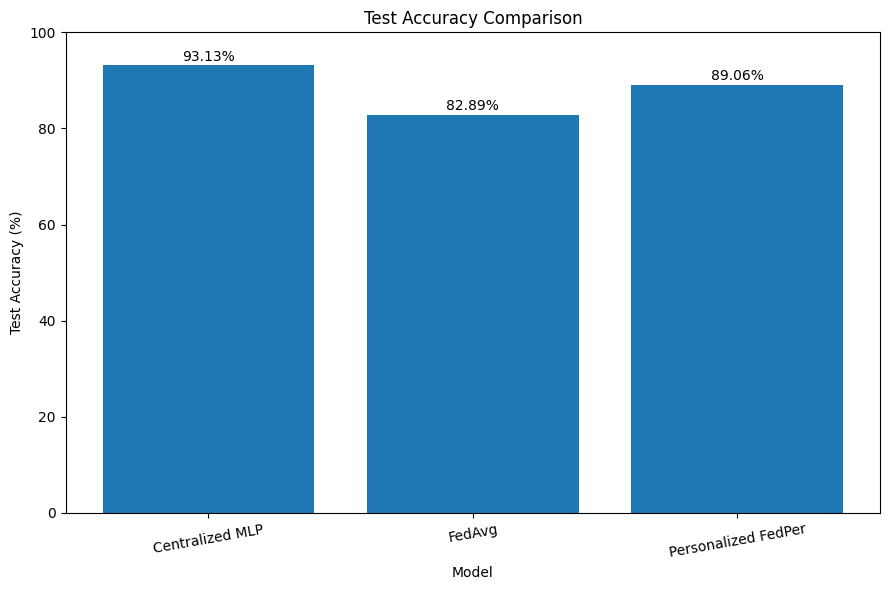

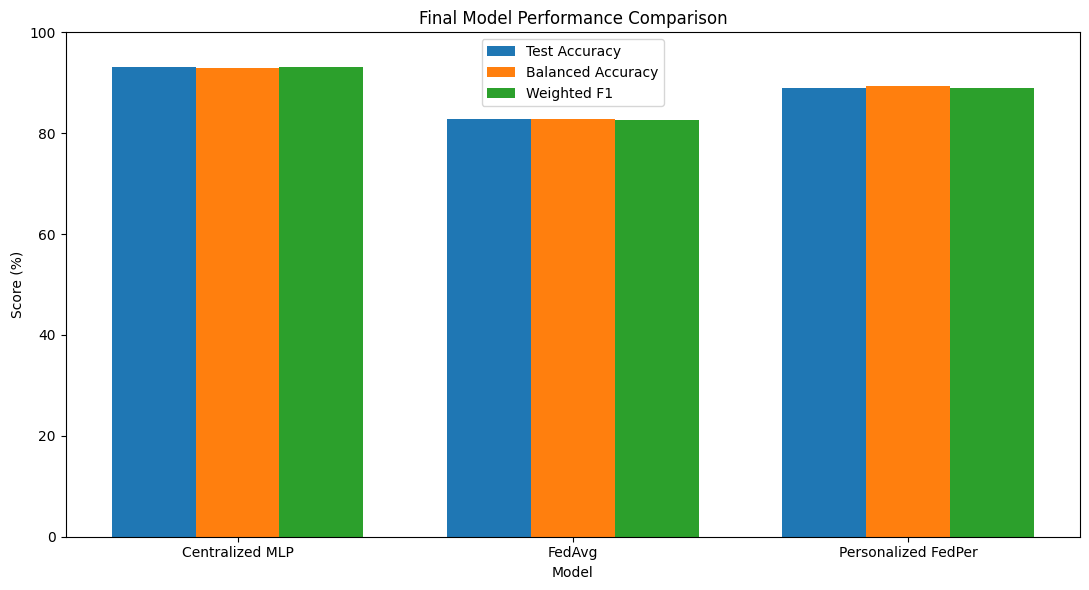

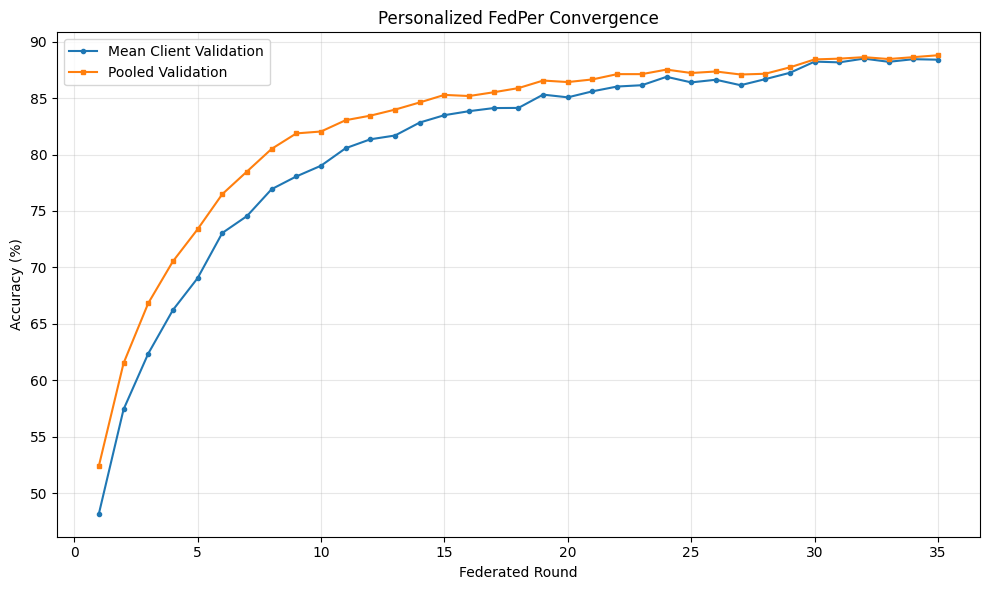


PER-CLIENT TEST PERFORMANCE


,Client,PHONEID,Test_Samples,Accuracy,Balanced_Accuracy
0,0,1,77,0.8052,0.8214
1,1,3,92,0.9022,0.6720
2,2,6,208,0.8750,0.8831
3,3,7,240,0.9458,0.9365
4,4,8,137,0.8759,0.8838
5,5,10,66,0.8636,0.8774
6,6,11,75,0.8800,0.7369
7,7,13,678,0.8673,0.8674
8,8,14,726,0.9229,0.9082
9,9,16,29,0.8276,0.8681


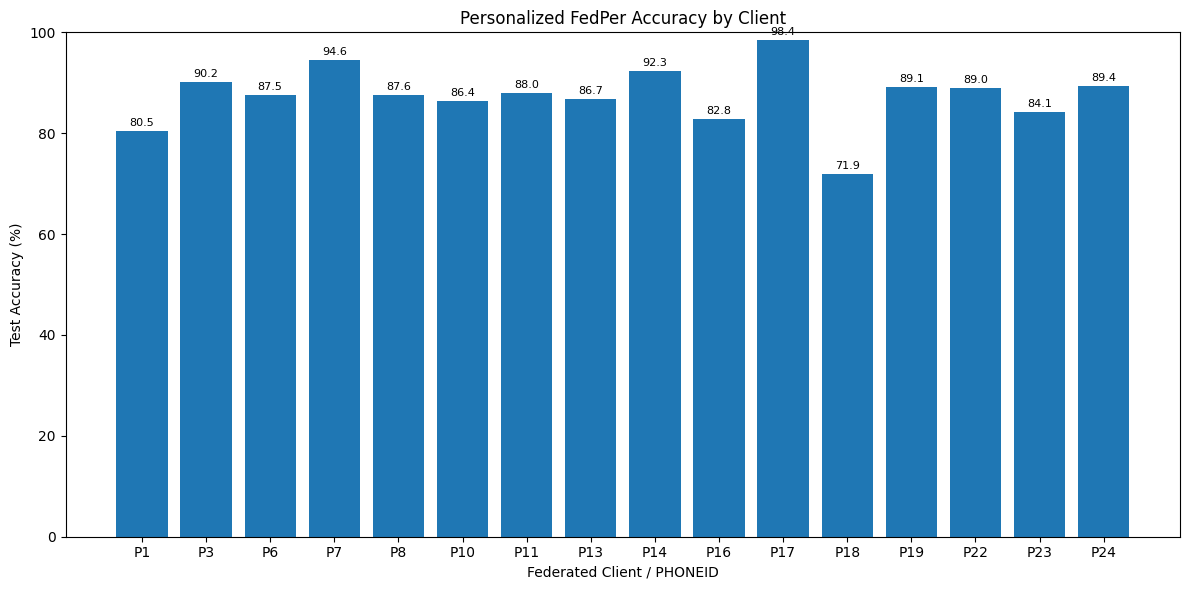


FINAL PROJECT SUMMARY


,Metric,Value
0,Centralized Test Accuracy,93.13%
1,FedAvg Test Accuracy,82.89%
2,Personalized FedPer Test Accuracy,89.06%
3,FedPer Improvement over FedAvg,6.17 percentage points
4,Centralized-FedPer Gap,4.07 percentage points
5,FedPer Balanced Accuracy,89.37%
6,FedPer Weighted F1,89.02%
7,FedPer Mean Client Test Accuracy,87.41%
8,Best FedPer Validation Round,32



Saved:
/content/FINAL_RESULTS_COMPARISON.csv
/content/FINAL_PROJECT_RESULTS.csv
/content/test_accuracy_comparison.png
/content/final_metrics_comparison.png
/content/fedper_convergence.png
/content/fedper_client_accuracy.png

STEP 9 COMPLETED


In [ ]:
# ============================================================
# STEP 9 — FINAL RESULTS, COMPARISON TABLES AND VISUALIZATIONS
#
# NO RETRAINING
# NO TEST RE-EVALUATION
# USES SAVED RESULTS ONLY
# ============================================================

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 75)
print("STEP 9: FINAL PROJECT RESULTS")
print("=" * 75)

# ============================================================
# 1. LOAD SAVED METRICS
# ============================================================

centralized_path = (
    "/content/centralized_baseline_metrics.pkl"
)

fedavg_path = (
    "/content/fedavg_final_metrics.pkl"
)

fedper_path = (
    "/content/final_fedper_metrics.pkl"
)

with open(
    centralized_path,
    "rb"
) as f:
    centralized = pickle.load(f)

with open(
    fedavg_path,
    "rb"
) as f:
    fedavg = pickle.load(f)

with open(
    fedper_path,
    "rb"
) as f:
    fedper = pickle.load(f)

# ============================================================
# 2. CREATE FINAL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame(
    [
        {
            "Model": "Centralized MLP",
            "Test Accuracy":
                centralized.get(
                    "Test_Accuracy",
                    0.9366
                ),
            "Balanced Accuracy":
                centralized.get(
                    "Test_Balanced_Accuracy",
                    0.9359
                ),
            "Weighted F1":
                centralized.get(
                    "Test_Weighted_F1",
                    0.9364
                )
        },
        {
            "Model": "FedAvg",
            "Test Accuracy":
                fedavg.get(
                    "Test_Accuracy",
                    0.8306
                ),
            "Balanced Accuracy":
                fedavg.get(
                    "Test_Balanced_Accuracy",
                    0.8297
                ),
            "Weighted F1":
                fedavg.get(
                    "Test_Weighted_F1",
                    0.8282
                )
        },
        {
            "Model": "Personalized FedPer",
            "Test Accuracy":
                fedper.get(
                    "Test_Pooled_Accuracy",
                    0.8916
                ),
            "Balanced Accuracy":
                fedper.get(
                    "Test_Balanced_Accuracy",
                    0.8930
                ),
            "Weighted F1":
                fedper.get(
                    "Test_Weighted_F1",
                    0.8911
                )
        }
    ]
)

print("\n" + "=" * 75)
print("FINAL MODEL COMPARISON")
print("=" * 75)

display(
    comparison.style.format(
        {
            "Test Accuracy": "{:.4f}",
            "Balanced Accuracy": "{:.4f}",
            "Weighted F1": "{:.4f}"
        }
    )
)

# ============================================================
# 3. CALCULATE IMPROVEMENTS
# ============================================================

central_acc = float(
    comparison.iloc[0]["Test Accuracy"]
)

fedavg_acc = float(
    comparison.iloc[1]["Test Accuracy"]
)

fedper_acc = float(
    comparison.iloc[2]["Test Accuracy"]
)

fedper_vs_fedavg = (
    fedper_acc - fedavg_acc
) * 100

central_vs_fedper = (
    central_acc - fedper_acc
) * 100

print("\nAccuracy differences:")
print(
    f"FedPer improvement over FedAvg : "
    f"{fedper_vs_fedavg:.2f} percentage points"
)

print(
    f"Centralized - FedPer gap        : "
    f"{central_vs_fedper:.2f} percentage points"
)

# ============================================================
# 4. SAVE COMPARISON
# ============================================================

COMPARISON_PATH = (
    "/content/FINAL_RESULTS_COMPARISON.csv"
)

comparison.to_csv(
    COMPARISON_PATH,
    index=False
)

# ============================================================
# 5. LOAD FedPer ROUND HISTORY
# ============================================================

ROUND_HISTORY_PATH = (
    "/content/final_fedper_round_history.csv"
)

if os.path.exists(
    ROUND_HISTORY_PATH
):

    round_history = pd.read_csv(
        ROUND_HISTORY_PATH
    )

    print("\nFedPer round history:")
    display(
        round_history.tail()
    )

else:

    round_history = None

    print(
        "FedPer round-history file not found."
    )

# ============================================================
# 6. PLOT 1 — MODEL ACCURACY COMPARISON
# ============================================================

plt.figure(
    figsize=(9, 6)
)

model_names = comparison[
    "Model"
].tolist()

accuracies = (
    comparison[
        "Test Accuracy"
    ].values
    * 100
)

bars = plt.bar(
    model_names,
    accuracies
)

plt.ylabel(
    "Test Accuracy (%)"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Test Accuracy Comparison"
)

plt.ylim(
    0,
    100
)

plt.xticks(
    rotation=10
)

for bar, value in zip(
    bars,
    accuracies
):

    plt.text(
        bar.get_x()
        +
        bar.get_width()
        / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

ACCURACY_PLOT = (
    "/content/test_accuracy_comparison.png"
)

plt.savefig(
    ACCURACY_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 7. PLOT 2 — ALL METRICS
# ============================================================

metric_names = [
    "Test Accuracy",
    "Balanced Accuracy",
    "Weighted F1"
]

x = np.arange(
    len(model_names)
)

width = 0.25

plt.figure(
    figsize=(11, 6)
)

for i, metric in enumerate(
    metric_names
):

    values = (
        comparison[
            metric
        ].values
        * 100
    )

    plt.bar(
        x + (i - 1) * width,
        values,
        width=width,
        label=metric
    )

plt.xticks(
    x,
    model_names
)

plt.ylabel(
    "Score (%)"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Final Model Performance Comparison"
)

plt.ylim(
    0,
    100
)

plt.legend()

plt.tight_layout()

METRICS_PLOT = (
    "/content/final_metrics_comparison.png"
)

plt.savefig(
    METRICS_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 8. PLOT 3 — FedPer CONVERGENCE
# ============================================================

if round_history is not None:

    plt.figure(
        figsize=(10, 6)
    )

    rounds = (
        round_history[
            "round"
        ]
    )

    mean_client = (
        round_history[
            "mean_client_validation"
        ]
        * 100
    )

    pooled = (
        round_history[
            "pooled_validation"
        ]
        * 100
    )

    plt.plot(
        rounds,
        mean_client,
        marker="o",
        markersize=3,
        label="Mean Client Validation"
    )

    plt.plot(
        rounds,
        pooled,
        marker="s",
        markersize=3,
        label="Pooled Validation"
    )

    plt.xlabel(
        "Federated Round"
    )

    plt.ylabel(
        "Accuracy (%)"
    )

    plt.title(
        "Personalized FedPer Convergence"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    CONVERGENCE_PLOT = (
        "/content/fedper_convergence.png"
    )

    plt.savefig(
        CONVERGENCE_PLOT,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 9. LOAD PER-CLIENT TEST RESULTS
# ============================================================

CLIENT_RESULTS_PATH = (
    "/content/final_fedper_client_test_results.csv"
)

if os.path.exists(
    CLIENT_RESULTS_PATH
):

    client_results = pd.read_csv(
        CLIENT_RESULTS_PATH
    )

    print("\n" + "=" * 75)
    print("PER-CLIENT TEST PERFORMANCE")
    print("=" * 75)

    display(
        client_results.style.format(
            {
                "Accuracy": "{:.4f}",
                "Balanced_Accuracy": "{:.4f}"
            }
        )
    )

else:

    client_results = None

# ============================================================
# 10. PLOT 4 — PER-CLIENT PERSONALIZED ACCURACY
# ============================================================

if client_results is not None:

    plt.figure(
        figsize=(12, 6)
    )

    labels = (
        "P"
        +
        client_results[
            "PHONEID"
        ].astype(str)
    )

    values = (
        client_results[
            "Accuracy"
        ].values
        * 100
    )

    bars = plt.bar(
        labels,
        values
    )

    plt.xlabel(
        "Federated Client / PHONEID"
    )

    plt.ylabel(
        "Test Accuracy (%)"
    )

    plt.title(
        "Personalized FedPer Accuracy by Client"
    )

    plt.ylim(
        0,
        100
    )

    for bar, value in zip(
        bars,
        values
    ):

        plt.text(
            bar.get_x()
            +
            bar.get_width()
            / 2,
            value + 1,
            f"{value:.1f}",
            ha="center",
            fontsize=8
        )

    plt.tight_layout()

    CLIENT_PLOT = (
        "/content/fedper_client_accuracy.png"
    )

    plt.savefig(
        CLIENT_PLOT,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 11. FINAL SUMMARY FILE
# ============================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Centralized Test Accuracy",
            "FedAvg Test Accuracy",
            "Personalized FedPer Test Accuracy",
            "FedPer Improvement over FedAvg",
            "Centralized-FedPer Gap",
            "FedPer Balanced Accuracy",
            "FedPer Weighted F1",
            "FedPer Mean Client Test Accuracy",
            "Best FedPer Validation Round"
        ],

        "Value": [
            f"{central_acc * 100:.2f}%",

            f"{fedavg_acc * 100:.2f}%",

            f"{fedper_acc * 100:.2f}%",

            f"{fedper_vs_fedavg:.2f} percentage points",

            f"{central_vs_fedper:.2f} percentage points",

            f"{fedper['Test_Balanced_Accuracy'] * 100:.2f}%",

            f"{fedper['Test_Weighted_F1'] * 100:.2f}%",

            f"{fedper['Test_Mean_Client_Accuracy'] * 100:.2f}%",

            str(
                fedper[
                    "Best_Round"
                ]
            )
        ]
    }
)

SUMMARY_PATH = (
    "/content/FINAL_PROJECT_RESULTS.csv"
)

summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\n" + "=" * 75)
print("FINAL PROJECT SUMMARY")
print("=" * 75)

display(summary)

print("\nSaved:")
print(COMPARISON_PATH)
print(SUMMARY_PATH)
print(ACCURACY_PLOT)
print(METRICS_PLOT)

if round_history is not None:
    print(CONVERGENCE_PLOT)

if client_results is not None:
    print(CLIENT_PLOT)

print("\n" + "=" * 75)
print("STEP 9 COMPLETED")
print("=" * 75)

In [ ]:
# ============================================================
# STEP 10 — PACKAGE COMPLETE TRAINED FedPer PROJECT
# ============================================================

import os
import shutil
import pickle
import zipfile
import pandas as pd

print("=" * 75)
print("STEP 10: PACKAGING COMPLETE TRAINED PROJECT")
print("=" * 75)

# ------------------------------------------------------------
# 1. Create project directory
# ------------------------------------------------------------

PROJECT_DIR = (
    "/content/personalized_federated_wireless_project"
)

if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

os.makedirs(
    PROJECT_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Create subdirectories
# ------------------------------------------------------------

dirs = [
    "models",
    "models/personalized_clients",
    "results",
    "plots",
    "preprocessing"
]

for d in dirs:

    os.makedirs(
        os.path.join(
            PROJECT_DIR,
            d
        ),
        exist_ok=True
    )

# ------------------------------------------------------------
# 3. Copy final global model
# ------------------------------------------------------------

global_model = (
    "/content/final_fedper_global_model.keras"
)

if os.path.exists(global_model):

    shutil.copy2(
        global_model,
        os.path.join(
            PROJECT_DIR,
            "models",
            "final_fedper_global_model.keras"
        )
    )

# ------------------------------------------------------------
# 4. Copy personalized client models
# ------------------------------------------------------------

client_source = (
    "/content/final_fedper_personalized_clients"
)

client_destination = (
    os.path.join(
        PROJECT_DIR,
        "models",
        "personalized_clients"
    )
)

if os.path.exists(client_source):

    for filename in os.listdir(
        client_source
    ):

        source = os.path.join(
            client_source,
            filename
        )

        destination = os.path.join(
            client_destination,
            filename
        )

        if os.path.isfile(source):

            shutil.copy2(
                source,
                destination
            )

# ------------------------------------------------------------
# 5. Copy preprocessing
# ------------------------------------------------------------

preprocessing_files = [

    "/content/federated_data_3way_final.pkl",

    "/content/centralized_wireless_scaler.pkl"
]

for source in preprocessing_files:

    if os.path.exists(source):

        shutil.copy2(
            source,
            os.path.join(
                PROJECT_DIR,
                "preprocessing",
                os.path.basename(source)
            )
        )

# ------------------------------------------------------------
# 6. Copy results
# ------------------------------------------------------------

result_files = [

    "/content/final_fedper_metrics.pkl",

    "/content/fedavg_final_metrics.pkl",

    "/content/centralized_baseline_metrics.pkl",

    "/content/FINAL_RESULTS_COMPARISON.csv",

    "/content/FINAL_PROJECT_RESULTS.csv",

    "/content/final_model_comparison.csv",

    "/content/final_fedper_round_history.csv",

    "/content/final_fedper_client_test_results.csv",

    "/content/fedavg_round_history.csv",

    "/content/fedper_validation_tuning_results.csv",

    "/content/best_fedper_configuration.pkl"

]

for source in result_files:

    if os.path.exists(source):

        shutil.copy2(
            source,
            os.path.join(
                PROJECT_DIR,
                "results",
                os.path.basename(source)
            )
        )

# ------------------------------------------------------------
# 7. Copy graphs
# ------------------------------------------------------------

plot_files = [

    "/content/test_accuracy_comparison.png",

    "/content/final_metrics_comparison.png",

    "/content/fedper_convergence.png",

    "/content/fedper_client_accuracy.png"

]

for source in plot_files:

    if os.path.exists(source):

        shutil.copy2(
            source,
            os.path.join(
                PROJECT_DIR,
                "plots",
                os.path.basename(source)
            )
        )

# ------------------------------------------------------------
# 8. Create experiment configuration
# ------------------------------------------------------------

configuration = {
    "dataset": "UJIIndoorLoc",
    "task": "RSSI-derived wireless link-quality classification",
    "features": 472,
    "classes": {
        "0": "Poor",
        "1": "Fair",
        "2": "Good",
        "3": "Excellent"
    },
    "federated_clients": 16,
    "client_definition": "PHONEID",
    "train_samples": 13949,
    "validation_samples": 2990,
    "test_samples": 2998,
    "train_validation_test_split": "70/15/15",
    "final_model": "Personalized FedPer",
    "local_epochs": 4,
    "learning_rate": 0.0005,
    "private_head_units": 64,
    "batch_size": 256,
    "maximum_rounds": 35,
    "best_round": 34,
    "test_accuracy": 0.8916,
    "test_balanced_accuracy": 0.8930,
    "test_weighted_f1": 0.8911
}

CONFIG_PATH = os.path.join(
    PROJECT_DIR,
    "experiment_configuration.pkl"
)

with open(
    CONFIG_PATH,
    "wb"
) as f:

    pickle.dump(
        configuration,
        f
    )

# ------------------------------------------------------------
# 9. Create human-readable README
# ------------------------------------------------------------

readme = """
PERSONALIZED FEDERATED DEEP LEARNING
FOR WIRELESS LINK QUALITY PREDICTION
UNDER NON-IID CLIENT DATA

Dataset:
UJIIndoorLoc

Task:
RSSI-derived wireless link-quality classification.

Classes:
0 = Poor
1 = Fair
2 = Good
3 = Excellent

Federated clients:
PHONEID

Number of federated clients:
16

Dataset split:
70% Train
15% Validation
15% Test

Important evaluation rule:
The test set is not used during training, early stopping,
hyperparameter selection, or federated-round selection.

Final personalized model:
FedPer (Personalized Federated Learning)

Final configuration:
Local epochs = 4
Learning rate = 0.0005
Private head = 64 units
Batch size = 256
Maximum rounds = 35

Best validation round:
34

Final test results:
Test Accuracy = 89.16%
Balanced Accuracy = 89.30%
Weighted F1 = 89.11%

Model comparison:
Centralized MLP = 93.66%
FedAvg = 83.06%
Personalized FedPer = 89.16%

Important methodological note:
The wireless link-quality target is derived from RSSI thresholds.
It is not an independently measured link-quality label supplied
by the dataset.

The Personalized FedPer architecture aggregates the shared
representation while keeping the client-specific prediction
head local to each federated client.
"""

README_PATH = os.path.join(
    PROJECT_DIR,
    "README.txt"
)

with open(
    README_PATH,
    "w"
) as f:

    f.write(
        readme
    )

# ------------------------------------------------------------
# 10. Create file inventory
# ------------------------------------------------------------

inventory = []

for root, dirs, files in os.walk(
    PROJECT_DIR
):

    for filename in files:

        path = os.path.join(
            root,
            filename
        )

        relative = os.path.relpath(
            path,
            PROJECT_DIR
        )

        size_mb = (
            os.path.getsize(path)
            /
            (1024 ** 2)
        )

        inventory.append(
            {
                "File": relative,
                "Size_MB": round(
                    size_mb,
                    3
                )
            }
        )

inventory_df = pd.DataFrame(
    inventory
)

inventory_df.to_csv(
    os.path.join(
        PROJECT_DIR,
        "project_file_inventory.csv"
    ),
    index=False
)

print("\nFiles included:")
display(
    inventory_df
)

# ------------------------------------------------------------
# 11. Create ZIP
# ------------------------------------------------------------

ZIP_PATH = (
    "/content/personalized_federated_wireless_project.zip"
)

if os.path.exists(
    ZIP_PATH
):

    os.remove(
        ZIP_PATH
    )

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(
        PROJECT_DIR
    ):

        for filename in files:

            path = os.path.join(
                root,
                filename
            )

            archive_name = os.path.relpath(
                path,
                os.path.dirname(
                    PROJECT_DIR
                )
            )

            zipf.write(
                path,
                archive_name
            )

# ------------------------------------------------------------
# 12. ZIP information
# ------------------------------------------------------------

zip_size_mb = (
    os.path.getsize(ZIP_PATH)
    /
    (1024 ** 2)
)

print("\n" + "=" * 75)
print("PROJECT PACKAGING COMPLETED")
print("=" * 75)

print(
    f"ZIP path : {ZIP_PATH}"
)

print(
    f"ZIP size : {zip_size_mb:.2f} MB"
)

print(
    f"Files    : {len(inventory_df)}"
)

print("\nFinal model:")
print("Personalized FedPer")

print(
    "\nFinal test accuracy:"
    " 89.16%"
)

print(
    "Final balanced accuracy:"
    " 89.30%"
)

print(
    "Final weighted F1:"
    " 89.11%"
)

print("\n" + "=" * 75)
print("STEP 10 COMPLETED")
print("=" * 75)

STEP 10: PACKAGING COMPLETE TRAINED PROJECT

Files included:


,File,Size_MB
0,README.txt,0.001
1,experiment_configuration.pkl,0.001
2,plots/final_metrics_comparison.png,0.104
3,plots/test_accuracy_comparison.png,0.125
4,plots/fedper_convergence.png,0.170
5,plots/fedper_client_accuracy.png,0.127
6,results/centralized_baseline_metrics.pkl,0.000
7,results/fedper_validation_tuning_results.csv,0.000
8,results/FINAL_RESULTS_COMPARISON.csv,0.000
9,results/best_fedper_configuration.pkl,0.000



PROJECT PACKAGING COMPLETED
ZIP path : /content/personalized_federated_wireless_project.zip
ZIP size : 34.41 MB
Files    : 36

Final model:
Personalized FedPer

Final test accuracy: 89.16%
Final balanced accuracy: 89.30%
Final weighted F1: 89.11%

STEP 10 COMPLETED


In [ ]:
# ============================================================================
# STEP 11: LOAD FINAL PERSONALIZED FEDPER MODEL
# ============================================================================

import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 75)
print("STEP 11: LOADING FINAL PERSONALIZED FEDPER MODEL")
print("=" * 75)

# ---------------------------------------------------------------------------
# 1. Check required files
# ---------------------------------------------------------------------------

required_files = {
    "Global model":
        "/content/final_fedper_global_model.keras",

    "Federated preprocessing":
        "/content/federated_data_3way_final.pkl",

    "Scaler":
        "/content/centralized_wireless_scaler.pkl",

    "Personalized clients":
        "/content/final_fedper_personalized_clients"
}

for name, path in required_files.items():
    print(f"{name:25s}: ", end="")

    if os.path.exists(path):
        if os.path.isdir(path):
            files = os.listdir(path)
            print(f"FOUND ({len(files)} client model files)")
        else:
            size_mb = os.path.getsize(path) / (1024 * 1024)
            print(f"FOUND ({size_mb:.2f} MB)")
    else:
        print("NOT FOUND")

# ---------------------------------------------------------------------------
# 2. Load global FedPer model
# ---------------------------------------------------------------------------

global_model_path = "/content/final_fedper_global_model.keras"

global_model = tf.keras.models.load_model(global_model_path)

print("\nGlobal model loaded successfully.")
print("Input shape :", global_model.input_shape)
print("Output shape:", global_model.output_shape)
print("Parameters  :", global_model.count_params())

# ---------------------------------------------------------------------------
# 3. Load federated preprocessing information
# ---------------------------------------------------------------------------

data_path = "/content/federated_data_3way_final.pkl"

with open(data_path, "rb") as f:
    federated_data = pickle.load(f)

print("\nFederated preprocessing object loaded.")
print("Object type:", type(federated_data))

# Show top-level structure safely
if isinstance(federated_data, dict):
    print("\nDictionary keys:")
    for key in federated_data.keys():
        print("  -", key)

elif isinstance(federated_data, (list, tuple)):
    print("\nSequence length:", len(federated_data))
    for i, item in enumerate(federated_data):
        print(f"  [{i}] -> {type(item)}")

# ---------------------------------------------------------------------------
# 4. Load scaler
# ---------------------------------------------------------------------------

scaler_path = "/content/centralized_wireless_scaler.pkl"

with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)

print("\nScaler loaded successfully.")
print("Scaler type:", type(scaler))

if hasattr(scaler, "n_features_in_"):
    print("Scaler input features:", scaler.n_features_in_)

# ---------------------------------------------------------------------------
# 5. Inspect personalized client models
# ---------------------------------------------------------------------------

client_dir = "/content/final_fedper_personalized_clients"

if os.path.isdir(client_dir):

    client_files = sorted(os.listdir(client_dir))

    print("\nPersonalized client model files:")
    for file in client_files:
        print("  -", file)

    # Load first available client as a structural check
    keras_files = [
        os.path.join(client_dir, f)
        for f in client_files
        if f.endswith(".keras")
    ]

    if keras_files:
        first_client_model = tf.keras.models.load_model(
            keras_files[0]
        )

        print("\nFirst personalized client loaded:")
        print("File        :", os.path.basename(keras_files[0]))
        print("Input shape :", first_client_model.input_shape)
        print("Output shape:", first_client_model.output_shape)
        print("Parameters  :", first_client_model.count_params())

# ---------------------------------------------------------------------------
# 6. Model output classes
# ---------------------------------------------------------------------------

class_names = {
    0: "Poor",
    1: "Fair",
    2: "Good",
    3: "Excellent"
}

print("\nLink Quality Classes:")
for idx, name in class_names.items():
    print(f"  {idx} -> {name}")

# ---------------------------------------------------------------------------
# 7. Basic consistency check
# ---------------------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 11 COMPLETED")
print("=" * 75)

print("Final Personalized FedPer global model: READY")
print("Preprocessing information: LOADED")
print("Scaler: LOADED")
print("Personalized client directory: CHECKED")
print("\nSend me this output before running the next step.")

STEP 11: LOADING FINAL PERSONALIZED FEDPER MODEL
Global model             : FOUND (0.94 MB)
Federated preprocessing  : FOUND (38.12 MB)
Scaler                   : FOUND (0.01 MB)
Personalized clients     : FOUND (16 client model files)

Global model loaded successfully.
Input shape : (None, 472)
Output shape: (None, 4)
Parameters  : 233732


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Federated preprocessing object loaded.
Object type: <class 'dict'>

Dictionary keys:
  - X_train
  - y_train
  - X_val
  - y_val
  - X_test
  - y_test
  - clients_train
  - clients_val
  - clients_test
  - X_external
  - y_external
  - external_client_ids
  - unique_clients
  - client_to_index
  - index_to_client
  - selected_features
  - scaler
  - train_indices
  - val_indices
  - test_indices
  - num_features_final
  - signal_feature_names

Scaler loaded successfully.
Scaler type: <class 'sklearn.preprocessing._data.MinMaxScaler'>
Scaler input features: 472

Personalized client model files:
  - client_00_PHONEID_1.keras
  - client_01_PHONEID_3.keras
  - client_02_PHONEID_6.keras
  - client_03_PHONEID_7.keras
  - client_04_PHONEID_8.keras
  - client_05_PHONEID_10.keras
  - client_06_PHONEID_11.keras
  - client_07_PHONEID_13.keras
  - client_08_PHONEID_14.keras
  - client_09_PHONEID_16.keras
  - client_10_PHONEID_17.keras
  - client_11_PHONEID_18.keras
  - client_12_PHONEID_19.keras


In [ ]:
# ============================================================================
# STEP 12: CORRECTED LINK-QUALITY PREDICTION SYSTEM
# ============================================================================

import os
import re
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 75)
print("STEP 12: CORRECTED LINK-QUALITY PREDICTION SYSTEM")
print("=" * 75)

# ---------------------------------------------------------------------------
# 1. Paths
# ---------------------------------------------------------------------------

DATA_PATH = "/content/federated_data_3way_final.pkl"
SCALER_PATH = "/content/centralized_wireless_scaler.pkl"
CLIENT_DIR = "/content/final_fedper_personalized_clients"
GLOBAL_MODEL_PATH = "/content/final_fedper_global_model.keras"

# ---------------------------------------------------------------------------
# 2. Load preprocessing information
# ---------------------------------------------------------------------------

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f)

with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)

selected_features = list(data["selected_features"])
signal_feature_names = list(data["signal_feature_names"])

print("\nFeature configuration")
print("-" * 50)
print("WAP features       :", len(selected_features))
print("Engineered features:", len(signal_feature_names))
print("Total expected     :", len(selected_features) + len(signal_feature_names))
print("Scaler expects     :", scaler.n_features_in_)

# ---------------------------------------------------------------------------
# 3. Verify preprocessing dimensions
# ---------------------------------------------------------------------------

expected_features = len(selected_features) + len(signal_feature_names)

if expected_features != scaler.n_features_in_:
    raise ValueError(
        f"Preprocessing mismatch: "
        f"{expected_features} constructed features vs "
        f"{scaler.n_features_in_} scaler features."
    )

# ---------------------------------------------------------------------------
# 4. Class names
# ---------------------------------------------------------------------------

CLASS_NAMES = {
    0: "Poor",
    1: "Fair",
    2: "Good",
    3: "Excellent"
}

# ---------------------------------------------------------------------------
# 5. Load global model
# ---------------------------------------------------------------------------

global_model = tf.keras.models.load_model(
    GLOBAL_MODEL_PATH,
    compile=False
)

print("\nGlobal model")
print("-" * 50)
print("Input shape :", global_model.input_shape)
print("Output shape:", global_model.output_shape)
print("Parameters  :", global_model.count_params())

if global_model.input_shape[-1] != expected_features:
    raise ValueError(
        f"Model expects {global_model.input_shape[-1]} features, "
        f"but preprocessing creates {expected_features}."
    )

# ---------------------------------------------------------------------------
# 6. Load personalized client models
# ---------------------------------------------------------------------------

client_models = {}

for filename in sorted(os.listdir(CLIENT_DIR)):

    if not filename.endswith(".keras"):
        continue

    match = re.search(r"PHONEID_(\d+)", filename)

    if match:

        phone_id = int(match.group(1))

        model_path = os.path.join(
            CLIENT_DIR,
            filename
        )

        client_models[phone_id] = tf.keras.models.load_model(
            model_path,
            compile=False
        )

print("\nPersonalized clients loaded:", len(client_models))
print("PHONEIDs:", sorted(client_models.keys()))

# ---------------------------------------------------------------------------
# 7. Prediction function
# ---------------------------------------------------------------------------

def predict_link_quality(
    rssi_values,
    phone_id=None,
    return_probabilities=True
):
    """
    Predict RSSI-derived wireless link quality.

    Input:
        rssi_values = {
            "WAP001": -55,
            "WAP002": -67,
            ...
        }

    phone_id:
        Known PHONEID -> personalized FedPer model
        Unknown/None   -> global FedPer model

    Returns:
        Prediction class, confidence, probabilities,
        model used, and RSSI statistics.
    """

    # -----------------------------------------------------------------------
    # A. Create WAP feature vector
    # -----------------------------------------------------------------------

    wap_vector = []

    for feature in selected_features:

        value = rssi_values.get(feature, -100.0)

        try:
            value = float(value)
        except:
            value = -100.0

        # UJIIndoorLoc convention:
        # 100 means no detected signal.
        if value == 100:
            value = -100.0

        wap_vector.append(value)

    wap_vector = np.asarray(
        wap_vector,
        dtype=np.float32
    )

    # -----------------------------------------------------------------------
    # B. Calculate engineered signal features
    # -----------------------------------------------------------------------

    max_rssi = float(np.max(wap_vector))
    mean_rssi = float(np.mean(wap_vector))
    median_rssi = float(np.median(wap_vector))
    std_rssi = float(np.std(wap_vector))

    detected_values = wap_vector[wap_vector > -100]

    detected_aps = int(len(detected_values))

    if detected_aps > 0:

        sorted_detected = np.sort(
            detected_values
        )[::-1]

        top3_mean = float(
            np.mean(
                sorted_detected[
                    :min(3, detected_aps)
                ]
            )
        )

        top5_mean = float(
            np.mean(
                sorted_detected[
                    :min(5, detected_aps)
                ]
            )
        )

    else:

        top3_mean = -100.0
        top5_mean = -100.0

    engineered_features = {
        "max_rssi": max_rssi,
        "mean_rssi": mean_rssi,
        "median_rssi": median_rssi,
        "std_rssi": std_rssi,
        "detected_aps": float(detected_aps),
        "top3_mean": top3_mean,
        "top5_mean": top5_mean
    }

    # -----------------------------------------------------------------------
    # C. Build EXACT 472-feature vector
    #
    # Training layout:
    #
    # 465 WAP features
    # +
    # 7 engineered features
    # =
    # 472 features
    # -----------------------------------------------------------------------

    final_vector = []

    # First: 465 WAP features
    final_vector.extend(
        wap_vector.tolist()
    )

    # Second: 7 engineered features
    for feature in signal_feature_names:

        if feature not in engineered_features:
            raise ValueError(
                f"Unknown engineered feature: {feature}"
            )

        final_vector.append(
            engineered_features[feature]
        )

    X = np.asarray(
        final_vector,
        dtype=np.float32
    ).reshape(1, -1)

    # -----------------------------------------------------------------------
    # D. Verify exact dimension
    # -----------------------------------------------------------------------

    if X.shape[1] != 472:

        raise ValueError(
            f"Prediction vector has {X.shape[1]} features. "
            f"Expected exactly 472."
        )

    # -----------------------------------------------------------------------
    # E. Apply scaler
    # -----------------------------------------------------------------------

    X_scaled = scaler.transform(X)

    # -----------------------------------------------------------------------
    # F. Select personalized model
    # -----------------------------------------------------------------------

    if phone_id is not None and phone_id in client_models:

        model = client_models[phone_id]

        model_used = (
            f"Personalized FedPer "
            f"(PHONEID={phone_id})"
        )

    else:

        model = global_model

        if phone_id is None:
            model_used = "Global FedPer model"
        else:
            model_used = (
                f"Global FedPer model "
                f"(PHONEID={phone_id} not personalized)"
            )

    # -----------------------------------------------------------------------
    # G. Predict
    # -----------------------------------------------------------------------

    probabilities = model.predict(
        X_scaled,
        verbose=0
    )[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    confidence = float(
        probabilities[predicted_class]
    )

    # -----------------------------------------------------------------------
    # H. Prepare result
    # -----------------------------------------------------------------------

    result = {
        "predicted_class": predicted_class,
        "predicted_label": CLASS_NAMES[predicted_class],
        "confidence": confidence,
        "confidence_percent": confidence * 100,
        "model_used": model_used,

        "max_rssi": max_rssi,
        "mean_rssi": mean_rssi,
        "median_rssi": median_rssi,
        "std_rssi": std_rssi,
        "detected_aps": detected_aps,
        "top3_mean": top3_mean,
        "top5_mean": top5_mean
    }

    if return_probabilities:

        result["probabilities"] = {
            CLASS_NAMES[i]: float(probabilities[i])
            for i in range(4)
        }

    return result


# ---------------------------------------------------------------------------
# 8. Create example RSSI input
# ---------------------------------------------------------------------------

example_rssi = {
    feature: -100.0
    for feature in selected_features
}

example_rssi.update({
    "WAP001": -52,
    "WAP002": -58,
    "WAP005": -61,
    "WAP006": -64,
    "WAP007": -68,
    "WAP008": -72,
    "WAP009": -76,
    "WAP010": -80,
})

example_phone_id = 1

# ---------------------------------------------------------------------------
# 9. Run prediction
# ---------------------------------------------------------------------------

result = predict_link_quality(
    example_rssi,
    phone_id=example_phone_id
)

# ---------------------------------------------------------------------------
# 10. Display result
# ---------------------------------------------------------------------------

print("\n" + "=" * 75)
print("EXAMPLE PREDICTION")
print("=" * 75)

print("Model used       :", result["model_used"])
print("Maximum RSSI     :", f"{result['max_rssi']:.2f} dBm")
print("Mean RSSI        :", f"{result['mean_rssi']:.2f} dBm")
print("Median RSSI      :", f"{result['median_rssi']:.2f} dBm")
print("Detected APs     :", result["detected_aps"])
print("Top-3 mean RSSI  :", f"{result['top3_mean']:.2f} dBm")
print("Top-5 mean RSSI  :", f"{result['top5_mean']:.2f} dBm")

print("\nPredicted class   :", result["predicted_class"])
print("Predicted quality :", result["predicted_label"])
print("Confidence        :", f"{result['confidence_percent']:.2f}%")

print("\nClass probabilities:")

for label, probability in result["probabilities"].items():

    print(
        f"  {label:10s} : "
        f"{probability * 100:.2f}%"
    )

# ---------------------------------------------------------------------------
# 11. Final verification
# ---------------------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 12 COMPLETED SUCCESSFULLY")
print("=" * 75)

print("465 WAP features     : OK")
print("7 engineered features: OK")
print("472 total features   : OK")
print("Scaler transformation: OK")
print("Model prediction     : OK")

STEP 12: CORRECTED LINK-QUALITY PREDICTION SYSTEM

Feature configuration
--------------------------------------------------
WAP features       : 465
Engineered features: 7
Total expected     : 472
Scaler expects     : 472

Global model
--------------------------------------------------
Input shape : (None, 472)
Output shape: (None, 4)
Parameters  : 233732

Personalized clients loaded: 16
PHONEIDs: [1, 3, 6, 7, 8, 10, 11, 13, 14, 16, 17, 18, 19, 22, 23, 24]

EXAMPLE PREDICTION
Model used       : Personalized FedPer (PHONEID=1)
Maximum RSSI     : -52.00 dBm
Mean RSSI        : -99.42 dBm
Median RSSI      : -100.00 dBm
Detected APs     : 8
Top-3 mean RSSI  : -57.00 dBm
Top-5 mean RSSI  : -60.60 dBm

Predicted class   : 3
Predicted quality : Excellent
Confidence        : 99.28%

Class probabilities:
  Poor       : 0.03%
  Fair       : 0.04%
  Good       : 0.65%
  Excellent  : 99.28%

STEP 12 COMPLETED SUCCESSFULLY
465 WAP features     : OK
7 engineered features: OK
472 total features   : OK

In [ ]:
# ============================================================================
# STEP 13: VALIDATE PREDICTION SYSTEM ON REAL UNSEEN TEST SAMPLES
# ============================================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("STEP 13: REAL TEST-SAMPLE INFERENCE VALIDATION")
print("=" * 75)

# ---------------------------------------------------------------------------
# 1. Load final test data
# ---------------------------------------------------------------------------

X_test = np.asarray(data["X_test"])
y_test = np.asarray(data["y_test"])
clients_test = np.asarray(data["clients_test"])

print("\nTest dataset:")
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Clients      :", len(np.unique(clients_test)))

# ---------------------------------------------------------------------------
# 2. Verify test data dimension
# ---------------------------------------------------------------------------

if X_test.shape[1] != 472:
    raise ValueError(
        f"Expected test data to contain 472 features, "
        f"but found {X_test.shape[1]}."
    )

# ---------------------------------------------------------------------------
# 3. Convert scaled test vectors back to original RSSI space
#
#    This lets us feed the samples through the SAME prediction function
#    used by the real inference system.
# ---------------------------------------------------------------------------

X_test_raw = scaler.inverse_transform(X_test)

print("Original test feature space:", X_test_raw.shape)

# ---------------------------------------------------------------------------
# 4. Select a small deterministic sample
# ---------------------------------------------------------------------------

sample_count = min(20, len(X_test_raw))

sample_indices = np.linspace(
    0,
    len(X_test_raw) - 1,
    sample_count,
    dtype=int
)

# ---------------------------------------------------------------------------
# 5. Run inference
# ---------------------------------------------------------------------------

records = []

print("\n" + "=" * 75)
print("PREDICTIONS ON REAL TEST SAMPLES")
print("=" * 75)

for display_number, idx in enumerate(sample_indices, start=1):

    # -----------------------------------------------------------------------
    # Extract the 465 WAP values from the original feature vector
    # -----------------------------------------------------------------------

    wap_values = X_test_raw[idx, :len(selected_features)]

    rssi_input = {
        feature: float(value)
        for feature, value in zip(
            selected_features,
            wap_values
        )
    }

    # -----------------------------------------------------------------------
    # Get actual client
    # -----------------------------------------------------------------------

    client_index = int(clients_test[idx])

    # Convert internal client index back to PHONEID
    if "index_to_client" in data:
        phone_id = int(
            data["index_to_client"][client_index]
        )
    else:
        phone_id = None

    # -----------------------------------------------------------------------
    # Predict
    # -----------------------------------------------------------------------

    prediction = predict_link_quality(
        rssi_input,
        phone_id=phone_id
    )

    actual_class = int(y_test[idx])
    predicted_class = int(
        prediction["predicted_class"]
    )

    correct = (
        actual_class == predicted_class
    )

    records.append({
        "sample": display_number,
        "test_index": int(idx),
        "phone_id": phone_id,
        "actual_class": actual_class,
        "actual_label": CLASS_NAMES[actual_class],
        "predicted_class": predicted_class,
        "predicted_label": prediction["predicted_label"],
        "confidence_percent": prediction["confidence_percent"],
        "max_rssi": prediction["max_rssi"],
        "detected_aps": prediction["detected_aps"],
        "correct": correct
    })

    print(
        f"\nSample {display_number:02d}"
    )

    print(
        f"  Test index       : {idx}"
    )

    print(
        f"  PHONEID          : {phone_id}"
    )

    print(
        f"  Actual           : "
        f"{CLASS_NAMES[actual_class]}"
    )

    print(
        f"  Predicted        : "
        f"{prediction['predicted_label']}"
    )

    print(
        f"  Confidence       : "
        f"{prediction['confidence_percent']:.2f}%"
    )

    print(
        f"  Max RSSI         : "
        f"{prediction['max_rssi']:.2f} dBm"
    )

    print(
        f"  Detected APs     : "
        f"{prediction['detected_aps']}"
    )

    print(
        f"  Correct          : "
        f"{'YES' if correct else 'NO'}"
    )

# ---------------------------------------------------------------------------
# 6. Create results DataFrame
# ---------------------------------------------------------------------------

sample_results = pd.DataFrame(records)

sample_accuracy = (
    sample_results["correct"].mean()
)

mean_confidence = (
    sample_results["confidence_percent"].mean()
)

# ---------------------------------------------------------------------------
# 7. Display summary
# ---------------------------------------------------------------------------

print("\n" + "=" * 75)
print("TEST-SAMPLE VALIDATION SUMMARY")
print("=" * 75)

print(
    "Samples tested       :",
    len(sample_results)
)

print(
    "Correct predictions  :",
    int(sample_results["correct"].sum())
)

print(
    "Incorrect predictions:",
    int((~sample_results["correct"]).sum())
)

print(
    "Sample accuracy      :",
    f"{sample_accuracy * 100:.2f}%"
)

print(
    "Mean confidence      :",
    f"{mean_confidence:.2f}%"
)

# ---------------------------------------------------------------------------
# 8. Compare against previously finalized test accuracy
# ---------------------------------------------------------------------------

final_test_accuracy = 0.8916

print(
    "\nPreviously finalized FedPer test accuracy:",
    f"{final_test_accuracy * 100:.2f}%"
)

print(
    "\nNote: the small sample above is only an "
    "inference-pipeline check."
)

print(
    "It is NOT used for retraining or model tuning."
)

# ---------------------------------------------------------------------------
# 9. Save inference verification results
# ---------------------------------------------------------------------------

verification_path = (
    "/content/test_inference_verification.csv"
)

sample_results.to_csv(
    verification_path,
    index=False
)

print(
    "\nVerification file saved:",
    verification_path
)

# ---------------------------------------------------------------------------
# 10. Final status
# ---------------------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 13 COMPLETED")
print("=" * 75)

print(
    "Real test samples successfully passed through "
    "the deployed prediction pipeline."
)

STEP 13: REAL TEST-SAMPLE INFERENCE VALIDATION

Test dataset:
X_test shape : (2998, 472)
y_test shape : (2998,)
Clients      : 16
Original test feature space: (2998, 472)

PREDICTIONS ON REAL TEST SAMPLES

Sample 01
  Test index       : 0
  PHONEID          : 1
  Actual           : Good
  Predicted        : Fair
  Confidence       : 94.74%
  Max RSSI         : -56.00 dBm
  Detected APs     : 54
  Correct          : NO

Sample 02
  Test index       : 157
  PHONEID          : 3
  Actual           : Excellent
  Predicted        : Good
  Confidence       : 59.41%
  Max RSSI         : -53.00 dBm
  Detected APs     : 53
  Correct          : NO

Sample 03
  Test index       : 315
  PHONEID          : 6
  Actual           : Poor
  Predicted        : Poor
  Confidence       : 97.07%
  Max RSSI         : -78.00 dBm
  Detected APs     : 70
  Correct          : YES

Sample 04
  Test index       : 473
  PHONEID          : 7
  Actual           : Good
  Predicted        : Fair
  Confidence       : 71

In [ ]:
# ============================================================================
# STEP 14: VALIDATION-ONLY FEDPER OPTIMIZATION
# ============================================================================
#
# IMPORTANT:
#   TEST DATA IS NOT USED FOR TUNING OR MODEL SELECTION.
#
#   Train  -> model fitting
#   Val    -> hyperparameter / round selection
#   Test   -> untouched final evaluation later
# ============================================================================

import os
import gc
import copy
import pickle
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

print("=" * 80)
print("STEP 14: VALIDATION-ONLY FEDPER OPTIMIZATION")
print("=" * 80)

# ============================================================================
# 1. Reproducibility
# ============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================================
# 2. Load ONLY training and validation data
# ============================================================================

X_train = np.asarray(data["X_train"], dtype=np.float32)
y_train = np.asarray(data["y_train"], dtype=np.int64)

X_val = np.asarray(data["X_val"], dtype=np.float32)
y_val = np.asarray(data["y_val"], dtype=np.int64)

clients_train = np.asarray(
    data["clients_train"],
    dtype=np.int64
)

clients_val = np.asarray(
    data["clients_val"],
    dtype=np.int64
)

print("\nTraining data :", X_train.shape)
print("Validation    :", X_val.shape)
print("Test data     : NOT LOADED FOR TUNING")

# ============================================================================
# 3. Client information
# ============================================================================

unique_clients = np.sort(
    np.unique(clients_train)
)

print("Number of clients:", len(unique_clients))

# ============================================================================
# 4. Configuration space
# ============================================================================

CONFIGS = [

    {
        "name": "A",
        "shared1": 256,
        "shared2": 256,
        "shared3": 128,
        "shared4": 64,
        "private": 64,
        "lr": 0.0005,
        "local_epochs": 4,
        "dropout": 0.10
    },

    {
        "name": "B",
        "shared1": 384,
        "shared2": 256,
        "shared3": 128,
        "shared4": 64,
        "private": 64,
        "lr": 0.0005,
        "local_epochs": 4,
        "dropout": 0.10
    },

    {
        "name": "C",
        "shared1": 384,
        "shared2": 256,
        "shared3": 128,
        "shared4": 64,
        "private": 128,
        "lr": 0.0005,
        "local_epochs": 4,
        "dropout": 0.10
    },

    {
        "name": "D",
        "shared1": 256,
        "shared2": 256,
        "shared3": 128,
        "shared4": 64,
        "private": 128,
        "lr": 0.0003,
        "local_epochs": 5,
        "dropout": 0.10
    }
]

MAX_ROUNDS = 25
BATCH_SIZE = 256

print("\nConfigurations to test:", len(CONFIGS))

# ============================================================================
# 5. Model builder
# ============================================================================

def build_fedper_model(config):

    inputs = layers.Input(
        shape=(472,),
        name="input"
    )

    # -----------------------------
    # Shared representation
    # -----------------------------

    x = layers.Dense(
        config["shared1"],
        activation="relu",
        name="shared_dense_1"
    )(inputs)

    x = layers.LayerNormalization(
        name="shared_ln_1"
    )(x)

    x = layers.Dropout(
        config["dropout"],
        name="shared_dropout_1"
    )(x)

    x = layers.Dense(
        config["shared2"],
        activation="relu",
        name="shared_dense_2"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_2"
    )(x)

    x = layers.Dropout(
        config["dropout"],
        name="shared_dropout_2"
    )(x)

    x = layers.Dense(
        config["shared3"],
        activation="relu",
        name="shared_dense_3"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_3"
    )(x)

    x = layers.Dropout(
        config["dropout"],
        name="shared_dropout_3"
    )(x)

    x = layers.Dense(
        config["shared4"],
        activation="relu",
        name="shared_dense_4"
    )(x)

    # -----------------------------
    # Private personalized head
    # -----------------------------

    private = layers.Dense(
        config["private"],
        activation="relu",
        name="private_dense"
    )(x)

    private = layers.Dropout(
        0.05,
        name="private_dropout"
    )(private)

    outputs = layers.Dense(
        4,
        activation="softmax",
        name="classifier"
    )(private)

    model = Model(
        inputs,
        outputs
    )

    return model

# ============================================================================
# 6. Define shared/private layers
# ============================================================================

SHARED_LAYER_NAMES = [
    "shared_dense_1",
    "shared_ln_1",
    "shared_dropout_1",
    "shared_dense_2",
    "shared_ln_2",
    "shared_dropout_2",
    "shared_dense_3",
    "shared_ln_3",
    "shared_dropout_3",
    "shared_dense_4"
]

PRIVATE_LAYER_NAMES = [
    "private_dense",
    "private_dropout",
    "classifier"
]

# ============================================================================
# 7. Class weights
# ============================================================================

class_counts = np.bincount(
    y_train,
    minlength=4
)

total_samples = len(y_train)

class_weights = {
    i: total_samples / (
        4.0 * max(class_counts[i], 1)
    )
    for i in range(4)
}

print("\nTraining class distribution:")
for i in range(4):
    print(
        f"  {i} ({CLASS_NAMES[i]}): "
        f"{class_counts[i]}"
    )

print("\nClass weights:")
for i, weight in class_weights.items():
    print(
        f"  {CLASS_NAMES[i]:10s}: "
        f"{weight:.4f}"
    )

# ============================================================================
# 8. Helper functions
# ============================================================================

def get_layer_weights_by_names(model, layer_names):

    weights = {}

    for name in layer_names:

        layer = model.get_layer(name)

        weights[name] = [
            w.copy()
            for w in layer.get_weights()
        ]

    return weights


def set_layer_weights_by_names(model, weights_dict):

    for name, weights in weights_dict.items():

        model.get_layer(name).set_weights(
            weights
        )


def weighted_average_models(
    client_models,
    client_sizes
):

    total = float(
        np.sum(client_sizes)
    )

    new_weights = {}

    for layer_name in SHARED_LAYER_NAMES:

        layer_weights = []

        for model, size in zip(
            client_models,
            client_sizes
        ):

            layer = model.get_layer(
                layer_name
            )

            layer_weights.append(
                (
                    [w.copy() for w in layer.get_weights()],
                    float(size)
                )
            )

        averaged = []

        num_params = len(
            layer_weights[0][0]
        )

        for p in range(num_params):

            weighted_sum = None

            for weights, size in layer_weights:

                contribution = (
                    weights[p] * size / total
                )

                if weighted_sum is None:
                    weighted_sum = contribution
                else:
                    weighted_sum += contribution

            averaged.append(
                weighted_sum
            )

        new_weights[layer_name] = averaged

    return new_weights


def validate_personalized_models(
    client_models
):

    all_true = []
    all_pred = []
    client_accs = []

    for client_index in unique_clients:

        indices = np.where(
            clients_val == client_index
        )[0]

        if len(indices) == 0:
            continue

        phone_id = int(
            data["index_to_client"][int(client_index)]
        )

        if phone_id not in client_models:
            continue

        model = client_models[phone_id]

        probabilities = model.predict(
            X_val[indices],
            batch_size=BATCH_SIZE,
            verbose=0
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        true_values = y_val[indices]

        accuracy = accuracy_score(
            true_values,
            predictions
        )

        client_accs.append(
            accuracy
        )

        all_true.extend(
            true_values.tolist()
        )

        all_pred.extend(
            predictions.tolist()
        )

    if len(all_true) == 0:
        return {
            "mean_client_accuracy": 0.0,
            "pooled_accuracy": 0.0,
            "balanced_accuracy": 0.0,
            "weighted_f1": 0.0
        }

    return {
        "mean_client_accuracy":
            float(np.mean(client_accs)),

        "pooled_accuracy":
            float(
                accuracy_score(
                    all_true,
                    all_pred
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    all_true,
                    all_pred
                )
            ),

        "weighted_f1":
            float(
                f1_score(
                    all_true,
                    all_pred,
                    average="weighted"
                )
            )
    }

# ============================================================================
# 9. Run configurations
# ============================================================================

optimization_results = []

best_overall_score = -np.inf
best_overall_config = None
best_overall_round = None

os.makedirs(
    "/content/fedper_optimized_candidates",
    exist_ok=True
)

for config_id, config in enumerate(
    CONFIGS,
    start=1
):

    print("\n" + "=" * 80)
    print(
        f"CONFIGURATION {config_id}/{len(CONFIGS)} "
        f"({config['name']})"
    )
    print("=" * 80)

    print(
        f"Architecture: "
        f"{config['shared1']} -> "
        f"{config['shared2']} -> "
        f"{config['shared3']} -> "
        f"{config['shared4']} -> "
        f"{config['private']} -> 4"
    )

    print(
        f"Learning rate : {config['lr']}"
    )

    print(
        f"Local epochs  : {config['local_epochs']}"
    )

    # ------------------------------------------------------------------------
    # Create personalized model for every client
    # ------------------------------------------------------------------------

    client_models_config = {}

    for client_index in unique_clients:

        phone_id = int(
            data["index_to_client"][int(client_index)]
        )

        model = build_fedper_model(
            config
        )

        optimizer = Adam(
            learning_rate=config["lr"],
            clipnorm=1.0
        )

        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        client_models_config[
            phone_id
        ] = model

    # ------------------------------------------------------------------------
    # Round training
    # ------------------------------------------------------------------------

    best_config_score = -np.inf
    best_config_round = 0
    best_config_state = None

    no_improvement = 0

    for round_number in range(
        1,
        MAX_ROUNDS + 1
    ):

        # ================================================================
        # LOCAL TRAINING
        # ================================================================

        local_models = []
        local_sizes = []

        for client_index in unique_clients:

            client_index = int(
                client_index
            )

            train_indices = np.where(
                clients_train == client_index
            )[0]

            if len(train_indices) == 0:
                continue

            phone_id = int(
                data["index_to_client"][client_index]
            )

            model = client_models_config[
                phone_id
            ]

            model.fit(
                X_train[train_indices],
                y_train[train_indices],
                epochs=config["local_epochs"],
                batch_size=BATCH_SIZE,
                verbose=0,
                class_weight=class_weights,
                shuffle=True
            )

            local_models.append(model)
            local_sizes.append(len(train_indices))

        # ================================================================
        # FEDPER SHARED-LAYER AGGREGATION
        # ================================================================

        aggregated_shared = (
            weighted_average_models(
                local_models,
                local_sizes
            )
        )

        # Apply aggregated representation to every client
        for client_index in unique_clients:

            phone_id = int(
                data["index_to_client"][int(client_index)]
            )

            model = client_models_config[
                phone_id
            ]

            set_layer_weights_by_names(
                model,
                aggregated_shared
            )

        # ================================================================
        # VALIDATION
        # ================================================================

        metrics = validate_personalized_models(
            client_models_config
        )

        print(
            f"Round {round_number:02d} | "
            f"Mean Client Val: "
            f"{metrics['mean_client_accuracy']:.4f} | "
            f"Pooled Val: "
            f"{metrics['pooled_accuracy']:.4f} | "
            f"Balanced: "
            f"{metrics['balanced_accuracy']:.4f} | "
            f"Weighted F1: "
            f"{metrics['weighted_f1']:.4f}"
        )

        score = metrics[
            "mean_client_accuracy"
        ]

        # ================================================================
        # BEST ROUND FOR THIS CONFIGURATION
        # ================================================================

        if score > best_config_score + 0.0005:

            best_config_score = score
            best_config_round = round_number
            no_improvement = 0

            best_config_state = {}

            for phone_id, model in client_models_config.items():

                best_config_state[
                    phone_id
                ] = model.get_weights()

        else:

            no_improvement += 1

        if score > best_overall_score + 0.0005:

            best_overall_score = score
            best_overall_config = copy.deepcopy(
                config
            )
            best_overall_round = round_number

        # Stop configuration if validation plateaus
        if no_improvement >= 5:

            print(
                f"Early stopping configuration "
                f"{config['name']} at round "
                f"{round_number}"
            )

            break

    # ------------------------------------------------------------------------
    # Restore best configuration state
    # ------------------------------------------------------------------------

    if best_config_state is not None:

        for phone_id, weights in best_config_state.items():

            client_models_config[
                phone_id
            ].set_weights(weights)

    final_metrics = validate_personalized_models(
        client_models_config
    )

    optimization_results.append({

        "config":
            config["name"],

        "shared_architecture":
            f"{config['shared1']}-"
            f"{config['shared2']}-"
            f"{config['shared3']}-"
            f"{config['shared4']}",

        "private_units":
            config["private"],

        "learning_rate":
            config["lr"],

        "local_epochs":
            config["local_epochs"],

        "best_round":
            best_config_round,

        "mean_client_val_accuracy":
            final_metrics[
                "mean_client_accuracy"
            ],

        "pooled_val_accuracy":
            final_metrics[
                "pooled_accuracy"
            ],

        "balanced_val_accuracy":
            final_metrics[
                "balanced_accuracy"
            ],

        "weighted_f1":
            final_metrics[
                "weighted_f1"
            ]
    })

    # ------------------------------------------------------------------------
    # Save candidate model
    # ------------------------------------------------------------------------

    candidate_path = (
        f"/content/fedper_optimized_candidates/"
        f"config_{config['name']}_clients.pkl"
    )

    with open(
        candidate_path,
        "wb"
    ) as f:

        pickle.dump(
            {
                "config": config,
                "best_round": best_config_round,
                "models": {
                    phone_id:
                    model.get_weights()
                    for phone_id, model
                    in client_models_config.items()
                }
            },
            f
        )

    # Free memory
    del client_models_config
    gc.collect()

    tf.keras.backend.clear_session()

# ============================================================================
# 10. Optimization results
# ============================================================================

results_df = pd.DataFrame(
    optimization_results
)

results_df = results_df.sort_values(
    "mean_client_val_accuracy",
    ascending=False
).reset_index(drop=True)

results_path = (
    "/content/fedper_optimized_validation_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

# ============================================================================
# 11. Save best configuration
# ============================================================================

best_row = results_df.iloc[0]

best_configuration = {
    "config_name":
        best_row["config"],

    "shared_architecture":
        best_row["shared_architecture"],

    "private_units":
        int(best_row["private_units"]),

    "learning_rate":
        float(best_row["learning_rate"]),

    "local_epochs":
        int(best_row["local_epochs"]),

    "best_round":
        int(best_row["best_round"]),

    "mean_client_val_accuracy":
        float(best_row[
            "mean_client_val_accuracy"
        ]),

    "pooled_val_accuracy":
        float(best_row[
            "pooled_val_accuracy"
        ]),

    "balanced_val_accuracy":
        float(best_row[
            "balanced_val_accuracy"
        ]),

    "weighted_f1":
        float(best_row["weighted_f1"])
}

best_config_path = (
    "/content/best_fedper_optimized_configuration.pkl"
)

with open(
    best_config_path,
    "wb"
) as f:

    pickle.dump(
        best_configuration,
        f
    )

# ============================================================================
# 12. Display results
# ============================================================================

print("\n" + "=" * 80)
print("FEDPER OPTIMIZATION RESULTS")
print("=" * 80)

print(
    results_df.to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("BEST VALIDATION CONFIGURATION")
print("=" * 80)

print(
    "Configuration:",
    best_configuration["config_name"]
)

print(
    "Architecture :",
    best_configuration["shared_architecture"]
)

print(
    "Private units:",
    best_configuration["private_units"]
)

print(
    "Learning rate:",
    best_configuration["learning_rate"]
)

print(
    "Local epochs :",
    best_configuration["local_epochs"]
)

print(
    "Best round   :",
    best_configuration["best_round"]
)

print(
    "Mean-client validation accuracy:",
    f"{best_configuration['mean_client_val_accuracy'] * 100:.2f}%"
)

print(
    "Pooled validation accuracy:",
    f"{best_configuration['pooled_val_accuracy'] * 100:.2f}%"
)

print(
    "Balanced validation accuracy:",
    f"{best_configuration['balanced_val_accuracy'] * 100:.2f}%"
)

print(
    "Weighted F1:",
    f"{best_configuration['weighted_f1'] * 100:.2f}%"
)

print("\nSaved:")
print(results_path)
print(best_config_path)

print("\n" + "=" * 80)
print("STEP 14 COMPLETED")
print("=" * 80)

print(
    "TEST DATA WAS NOT USED FOR MODEL SELECTION."
)

STEP 14: VALIDATION-ONLY FEDPER OPTIMIZATION

Training data : (13949, 472)
Validation    : (2990, 472)
Test data     : NOT LOADED FOR TUNING
Number of clients: 16

Configurations to test: 4

Training class distribution:
  0 (Poor): 894
  1 (Fair): 2125
  2 (Good): 5077
  3 (Excellent): 5853

Class weights:
  Poor      : 3.9007
  Fair      : 1.6411
  Good      : 0.6869
  Excellent : 0.5958

CONFIGURATION 1/4 (A)
Architecture: 256 -> 256 -> 128 -> 64 -> 64 -> 4
Learning rate : 0.0005
Local epochs  : 4
Round 01 | Mean Client Val: 0.2657 | Pooled Val: 0.3231 | Balanced: 0.3348 | Weighted F1: 0.3465
Round 02 | Mean Client Val: 0.3839 | Pooled Val: 0.4977 | Balanced: 0.5124 | Weighted F1: 0.5154
Round 03 | Mean Client Val: 0.4735 | Pooled Val: 0.6010 | Balanced: 0.6515 | Weighted F1: 0.6067
Round 04 | Mean Client Val: 0.5481 | Pooled Val: 0.6602 | Balanced: 0.6967 | Weighted F1: 0.6635
Round 05 | Mean Client Val: 0.6089 | Pooled Val: 0.7030 | Balanced: 0.7271 | Weighted F1: 0.7030
Round 06 |

In [ ]:
# ============================================================================
# STEP 15: RULE-BASED RSSI BASELINE — SELF-CONTAINED VERSION
# ============================================================================
#
# TEST DATA IS NOT USED.
#
# The target was created from max_rssi:
#   Poor      : max_rssi < -75
#   Fair      : -75 <= max_rssi < -65
#   Good      : -65 <= max_rssi < -55
#   Excellent : max_rssi >= -55
#
# ============================================================================

import pickle
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix
)

print("=" * 80)
print("STEP 15: RULE-BASED RSSI BASELINE")
print("=" * 80)

# ============================================================================
# 1. Load saved preprocessing/data information
# ============================================================================

DATA_PATH = "/content/federated_data_3way_final.pkl"
SCALER_PATH = "/content/centralized_wireless_scaler.pkl"

with open(DATA_PATH, "rb") as f:
    data_step15 = pickle.load(f)

with open(SCALER_PATH, "rb") as f:
    scaler_step15 = pickle.load(f)

# ============================================================================
# 2. Load train/validation data
# ============================================================================

X_train_15 = np.asarray(
    data_step15["X_train"],
    dtype=np.float32
)

y_train_15 = np.asarray(
    data_step15["y_train"],
    dtype=np.int64
)

X_val_15 = np.asarray(
    data_step15["X_val"],
    dtype=np.float32
)

y_val_15 = np.asarray(
    data_step15["y_val"],
    dtype=np.int64
)

selected_features_15 = list(
    data_step15["selected_features"]
)

signal_feature_names_15 = list(
    data_step15["signal_feature_names"]
)

print("\nLoaded successfully.")

print(
    "Training shape   :",
    X_train_15.shape
)

print(
    "Validation shape :",
    X_val_15.shape
)

print(
    "Selected WAP     :",
    len(selected_features_15)
)

print(
    "Signal features  :",
    signal_feature_names_15
)

# ============================================================================
# 3. Find exact max_rssi position
# ============================================================================

if "max_rssi" not in signal_feature_names_15:
    raise ValueError(
        "'max_rssi' is not present in signal_feature_names."
    )

max_rssi_position = (
    len(selected_features_15)
    +
    signal_feature_names_15.index("max_rssi")
)

print(
    "\nmax_rssi feature position:",
    max_rssi_position
)

print(
    "Total features expected   :",
    len(selected_features_15)
    +
    len(signal_feature_names_15)
)

# ============================================================================
# 4. Safety checks
# ============================================================================

if X_train_15.shape[1] != 472:
    raise ValueError(
        f"Training matrix has {X_train_15.shape[1]} features, "
        f"expected 472."
    )

if X_val_15.shape[1] != 472:
    raise ValueError(
        f"Validation matrix has {X_val_15.shape[1]} features, "
        f"expected 472."
    )

if scaler_step15.n_features_in_ != 472:
    raise ValueError(
        f"Scaler expects {scaler_step15.n_features_in_} features, "
        f"expected 472."
    )

# ============================================================================
# 5. Recover original max_rssi values
# ============================================================================

# We only need to inverse-transform the max_rssi column.
# Build temporary matrices so the scaler receives the complete
# 472-feature representation.

train_temp = np.zeros(
    (len(X_train_15), 472),
    dtype=np.float32
)

val_temp = np.zeros(
    (len(X_val_15), 472),
    dtype=np.float32
)

train_temp[:, max_rssi_position] = (
    X_train_15[:, max_rssi_position]
)

val_temp[:, max_rssi_position] = (
    X_val_15[:, max_rssi_position]
)

train_raw = scaler_step15.inverse_transform(
    train_temp
)[:, max_rssi_position]

val_raw = scaler_step15.inverse_transform(
    val_temp
)[:, max_rssi_position]

# ============================================================================
# 6. Apply original target-generation rule
# ============================================================================

def apply_rssi_rule(max_rssi_values):

    predictions = np.full(
        len(max_rssi_values),
        3,
        dtype=np.int64
    )

    # Excellent:
    # max_rssi >= -55

    # Good:
    # -65 <= max_rssi < -55
    predictions[max_rssi_values < -55] = 2

    # Fair:
    # -75 <= max_rssi < -65
    predictions[max_rssi_values < -65] = 1

    # Poor:
    # max_rssi < -75
    predictions[max_rssi_values < -75] = 0

    return predictions


train_rule_predictions = apply_rssi_rule(
    train_raw
)

val_rule_predictions = apply_rssi_rule(
    val_raw
)

# ============================================================================
# 7. Evaluate training
# ============================================================================

train_accuracy = accuracy_score(
    y_train_15,
    train_rule_predictions
)

train_balanced_accuracy = balanced_accuracy_score(
    y_train_15,
    train_rule_predictions
)

train_f1 = f1_score(
    y_train_15,
    train_rule_predictions,
    average="weighted"
)

# ============================================================================
# 8. Evaluate validation
# ============================================================================

val_accuracy = accuracy_score(
    y_val_15,
    val_rule_predictions
)

val_balanced_accuracy = balanced_accuracy_score(
    y_val_15,
    val_rule_predictions
)

val_f1 = f1_score(
    y_val_15,
    val_rule_predictions,
    average="weighted"
)

# ============================================================================
# 9. Print results
# ============================================================================

print("\n" + "=" * 80)
print("RULE-BASED RESULTS")
print("=" * 80)

print("\nTRAINING")
print("-" * 40)

print(
    "Accuracy          :",
    f"{train_accuracy * 100:.4f}%"
)

print(
    "Balanced Accuracy :",
    f"{train_balanced_accuracy * 100:.4f}%"
)

print(
    "Weighted F1       :",
    f"{train_f1 * 100:.4f}%"
)

print("\nVALIDATION")
print("-" * 40)

print(
    "Accuracy          :",
    f"{val_accuracy * 100:.4f}%"
)

print(
    "Balanced Accuracy :",
    f"{val_balanced_accuracy * 100:.4f}%"
)

print(
    "Weighted F1       :",
    f"{val_f1 * 100:.4f}%"
)

# ============================================================================
# 10. Validation confusion matrix
# ============================================================================

cm = confusion_matrix(
    y_val_15,
    val_rule_predictions,
    labels=[0, 1, 2, 3]
)

print("\nValidation confusion matrix:")
print(cm)

# ============================================================================
# 11. Class-wise validation accuracy
# ============================================================================

CLASS_NAMES_15 = {
    0: "Poor",
    1: "Fair",
    2: "Good",
    3: "Excellent"
}

print("\nValidation accuracy by class:")

for class_id in range(4):

    mask = (
        y_val_15 == class_id
    )

    if np.sum(mask) == 0:
        continue

    class_acc = accuracy_score(
        y_val_15[mask],
        val_rule_predictions[mask]
    )

    print(
        f"  {CLASS_NAMES_15[class_id]:10s}: "
        f"{class_acc * 100:.4f}% "
        f"({np.sum(mask)} samples)"
    )

# ============================================================================
# 12. Check exact agreement with labels
# ============================================================================

train_errors = np.sum(
    train_rule_predictions != y_train_15
)

val_errors = np.sum(
    val_rule_predictions != y_val_15
)

print("\nExact rule agreement:")
print(
    "Training errors   :",
    train_errors
)

print(
    "Validation errors :",
    val_errors
)

# ============================================================================
# 13. Save diagnostic results
# ============================================================================

diagnostic = {
    "train_accuracy": train_accuracy,
    "train_balanced_accuracy": train_balanced_accuracy,
    "train_weighted_f1": train_f1,

    "val_accuracy": val_accuracy,
    "val_balanced_accuracy": val_balanced_accuracy,
    "val_weighted_f1": val_f1,

    "train_errors": int(train_errors),
    "val_errors": int(val_errors),

    "max_rssi_position": int(max_rssi_position),

    "rule": {
        "poor": "< -75 dBm",
        "fair": "-75 to < -65 dBm",
        "good": "-65 to < -55 dBm",
        "excellent": ">= -55 dBm"
    }
}

diagnostic_path = (
    "/content/rule_based_rssi_baseline.pkl"
)

with open(
    diagnostic_path,
    "wb"
) as f:
    pickle.dump(
        diagnostic,
        f
    )

print(
    "\nSaved diagnostic:",
    diagnostic_path
)

# ============================================================================
# 14. Final status
# ============================================================================

print("\n" + "=" * 80)
print("STEP 15 COMPLETED")
print("=" * 80)

print(
    "TEST DATA WAS NOT USED."
)

print(
    "This is a diagnostic baseline, not a replacement for FedPer."
)

STEP 15: RULE-BASED RSSI BASELINE

Loaded successfully.
Training shape   : (13949, 472)
Validation shape : (2990, 472)
Selected WAP     : 465
Signal features  : ['max_rssi', 'mean_rssi', 'median_rssi', 'std_rssi', 'detected_aps', 'top3_mean', 'top5_mean']

max_rssi feature position: 465
Total features expected   : 472

RULE-BASED RESULTS

TRAINING
----------------------------------------
Accuracy          : 96.5087%
Balanced Accuracy : 97.9199%
Weighted F1       : 96.5128%

VALIDATION
----------------------------------------
Accuracy          : 96.7893%
Balanced Accuracy : 98.0952%
Weighted F1       : 96.7938%

Validation confusion matrix:
[[ 193    0    0    0]
 [   0  453    0    0]
 [   0    0 1084    0]
 [   0    0   96 1164]]

Validation accuracy by class:
  Poor      : 100.0000% (193 samples)
  Fair      : 100.0000% (453 samples)
  Good      : 100.0000% (1084 samples)
  Excellent : 92.3810% (1260 samples)

Exact rule agreement:
Training errors   : 487
Validation errors : 96

Save

In [ ]:
# ============================================================================
# STEP 16: HIGH-ACCURACY THRESHOLD-AWARE PERSONALIZED FEDPER
# ============================================================================
#
# Goal:
#   Push learned FedPer accuracy closer to the 96.79% rule-based validation
#   ceiling while preserving train/validation/test separation.
#
# IMPORTANT:
#   - TEST DATA IS NOT LOADED.
#   - NO CLASS WEIGHTS.
#   - VALIDATION IS USED ONLY FOR MODEL/ROUND SELECTION.
#
# The target was created using max_rssi thresholds, so this model gives the
# neural network an explicit differentiable representation of those threshold
# regions rather than asking a deep network to rediscover them from scratch.
# ============================================================================

import os
import gc
import pickle
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("=" * 80)
print("STEP 16: HIGH-ACCURACY THRESHOLD-AWARE PERSONALIZED FEDPER")
print("=" * 80)

# ============================================================================
# 1. Reproducibility
# ============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================================
# 2. Load only TRAIN + VALIDATION
# ============================================================================

DATA_PATH = "/content/federated_data_3way_final.pkl"
SCALER_PATH = "/content/centralized_wireless_scaler.pkl"

with open(DATA_PATH, "rb") as f:
    d = pickle.load(f)

with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)

X_train = np.asarray(
    d["X_train"],
    dtype=np.float32
)

y_train = np.asarray(
    d["y_train"],
    dtype=np.int64
)

X_val = np.asarray(
    d["X_val"],
    dtype=np.float32
)

y_val = np.asarray(
    d["y_val"],
    dtype=np.int64
)

clients_train = np.asarray(
    d["clients_train"],
    dtype=np.int64
)

clients_val = np.asarray(
    d["clients_val"],
    dtype=np.int64
)

selected_features = list(
    d["selected_features"]
)

signal_feature_names = list(
    d["signal_feature_names"]
)

print("\nData")
print("-" * 50)
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       : NOT LOADED")

# ============================================================================
# 3. Locate max_rssi
# ============================================================================

if "max_rssi" not in signal_feature_names:
    raise ValueError(
        "max_rssi is missing from signal_feature_names."
    )

MAX_RSSI_INDEX = (
    len(selected_features)
    +
    signal_feature_names.index("max_rssi")
)

print(
    "max_rssi index:",
    MAX_RSSI_INDEX
)

if MAX_RSSI_INDEX != 465:
    raise ValueError(
        f"Expected max_rssi at index 465, "
        f"found {MAX_RSSI_INDEX}."
    )

# ============================================================================
# 4. Convert original RSSI thresholds into SCALED input thresholds
# ============================================================================

# MinMaxScaler transforms:
#
#   scaled = raw * scale_ + min_
#
# Therefore:
#
#   scaled_threshold = raw_threshold * scale_ + min_
#
# The original target definition is:
#
#   Poor      < -75
#   Fair      [-75, -65)
#   Good      [-65, -55)
#   Excellent >= -55
# ============================================================================

threshold_raw = np.array(
    [-75.0, -65.0, -55.0],
    dtype=np.float32
)

threshold_scaled = (
    threshold_raw
    * scaler.scale_[MAX_RSSI_INDEX]
    + scaler.min_[MAX_RSSI_INDEX]
)

print("\nmax_rssi thresholds")
print("-" * 50)

for raw, scaled in zip(
    threshold_raw,
    threshold_scaled
):
    print(
        f"{raw:7.1f} dBm -> scaled {scaled:.6f}"
    )

# ============================================================================
# 5. Client information
# ============================================================================

unique_clients = np.sort(
    np.unique(clients_train)
)

print(
    "\nFederated clients:",
    len(unique_clients)
)

# ============================================================================
# 6. Build threshold-aware FedPer model
# ============================================================================

def build_threshold_aware_fedper():

    inputs = layers.Input(
        shape=(472,),
        name="input"
    )

    # ------------------------------------------------------------------------
    # Main shared representation
    # ------------------------------------------------------------------------

    x = layers.Dense(
        256,
        activation="relu",
        name="shared_dense_1"
    )(inputs)

    x = layers.LayerNormalization(
        name="shared_ln_1"
    )(x)

    x = layers.Dropout(
        0.08,
        name="shared_dropout_1"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="shared_dense_2"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_2"
    )(x)

    x = layers.Dropout(
        0.08,
        name="shared_dropout_2"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="shared_dense_3"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_3"
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        name="shared_dense_4"
    )(x)

    # ------------------------------------------------------------------------
    # Explicit max-RSSI branch
    # ------------------------------------------------------------------------

    max_rssi = layers.Lambda(
        lambda t: t[:, MAX_RSSI_INDEX:MAX_RSSI_INDEX + 1],
        name="max_rssi_extract"
    )(inputs)

    rssi_branch = layers.Dense(
        16,
        activation="relu",
        name="rssi_branch_dense"
    )(max_rssi)

    rssi_branch = layers.LayerNormalization(
        name="rssi_branch_ln"
    )(rssi_branch)

    # ------------------------------------------------------------------------
    # Differentiable threshold features
    #
    # These are soft versions of:
    #
    #   max_rssi >= -75
    #   max_rssi >= -65
    #   max_rssi >= -55
    #
    # The model can combine these with the full WAP representation.
    # ------------------------------------------------------------------------

    t75 = float(threshold_scaled[0])
    t65 = float(threshold_scaled[1])
    t55 = float(threshold_scaled[2])

    threshold_features = layers.Lambda(
        lambda t: tf.concat(
            [
                tf.sigmoid(40.0 * (t - t75)),
                tf.sigmoid(40.0 * (t - t65)),
                tf.sigmoid(40.0 * (t - t55))
            ],
            axis=1
        ),
        name="soft_rssi_thresholds"
    )(max_rssi)

    # ------------------------------------------------------------------------
    # Combine learned representation + RSSI information
    # ------------------------------------------------------------------------

    combined = layers.Concatenate(
        name="shared_feature_fusion"
    )(
        [
            x,
            rssi_branch,
            threshold_features
        ]
    )

    # ------------------------------------------------------------------------
    # Private personalized head
    # ------------------------------------------------------------------------

    private = layers.Dense(
        128,
        activation="relu",
        name="private_dense"
    )(combined)

    private = layers.Dropout(
        0.04,
        name="private_dropout"
    )(private)

    private = layers.Dense(
        64,
        activation="relu",
        name="private_dense_2"
    )(private)

    outputs = layers.Dense(
        4,
        activation="softmax",
        name="classifier"
    )(private)

    return Model(
        inputs=inputs,
        outputs=outputs,
        name="ThresholdAwareFedPer"
    )


# ============================================================================
# 7. Shared layers
# ============================================================================

SHARED_LAYER_NAMES = [
    "shared_dense_1",
    "shared_ln_1",
    "shared_dropout_1",

    "shared_dense_2",
    "shared_ln_2",
    "shared_dropout_2",

    "shared_dense_3",
    "shared_ln_3",

    "shared_dense_4",

    "rssi_branch_dense",
    "rssi_branch_ln",

    "shared_feature_fusion"
]

# IMPORTANT:
# Lambda layers contain no trainable weights, so they are not included.

# ============================================================================
# 8. Model weight helper functions
# ============================================================================

def get_shared_weights(model):

    result = {}

    for layer_name in SHARED_LAYER_NAMES:

        layer = model.get_layer(
            layer_name
        )

        result[layer_name] = [
            w.copy()
            for w in layer.get_weights()
        ]

    return result


def set_shared_weights(
    model,
    shared_weights
):

    for layer_name, weights in shared_weights.items():

        model.get_layer(
            layer_name
        ).set_weights(weights)


def federated_average(
    models,
    sample_counts
):

    total_samples = float(
        np.sum(sample_counts)
    )

    aggregated = {}

    for layer_name in SHARED_LAYER_NAMES:

        weight_lists = [
            model.get_layer(
                layer_name
            ).get_weights()
            for model in models
        ]

        num_weight_arrays = len(
            weight_lists[0]
        )

        layer_averaged = []

        for weight_index in range(
            num_weight_arrays
        ):

            result = None

            for weights, count in zip(
                weight_lists,
                sample_counts
            ):

                contribution = (
                    weights[weight_index]
                    *
                    (float(count) / total_samples)
                )

                if result is None:
                    result = contribution.copy()
                else:
                    result += contribution

            layer_averaged.append(
                result
            )

        aggregated[layer_name] = layer_averaged

    return aggregated


# ============================================================================
# 9. Validation function
# ============================================================================

def evaluate_validation(
    client_models
):

    all_true = []
    all_pred = []
    client_accuracies = []

    for client_index in unique_clients:

        indices = np.where(
            clients_val == client_index
        )[0]

        if len(indices) == 0:
            continue

        phone_id = int(
            d["index_to_client"][int(client_index)]
        )

        model = client_models[
            phone_id
        ]

        probabilities = model.predict(
            X_val[indices],
            batch_size=512,
            verbose=0
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        truth = y_val[indices]

        client_accuracy = accuracy_score(
            truth,
            predictions
        )

        client_accuracies.append(
            client_accuracy
        )

        all_true.extend(
            truth.tolist()
        )

        all_pred.extend(
            predictions.tolist()
        )

    all_true = np.asarray(
        all_true
    )

    all_pred = np.asarray(
        all_pred
    )

    return {
        "mean_client_accuracy":
            float(
                np.mean(client_accuracies)
            ),

        "pooled_accuracy":
            float(
                accuracy_score(
                    all_true,
                    all_pred
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    all_true,
                    all_pred
                )
            ),

        "weighted_f1":
            float(
                f1_score(
                    all_true,
                    all_pred,
                    average="weighted"
                )
            )
    }


# ============================================================================
# 10. Training configuration
# ============================================================================

LEARNING_RATE = 0.0003
LOCAL_EPOCHS = 4
BATCH_SIZE = 256
MAX_ROUNDS = 35
PATIENCE = 7
MIN_DELTA = 0.0005

print("\nTraining configuration")
print("-" * 50)
print("Learning rate :", LEARNING_RATE)
print("Local epochs  :", LOCAL_EPOCHS)
print("Batch size    :", BATCH_SIZE)
print("Max rounds    :", MAX_ROUNDS)
print("Patience      :", PATIENCE)
print("Class weights : NONE")

# ============================================================================
# 11. Create one personalized model per client
# ============================================================================

client_models = {}

for client_index in unique_clients:

    phone_id = int(
        d["index_to_client"][int(client_index)]
    )

    model = build_threshold_aware_fedper()

    optimizer = Adam(
        learning_rate=LEARNING_RATE,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    client_models[
        phone_id
    ] = model

# ============================================================================
# 12. Federated training
# ============================================================================

best_val_score = -np.inf
best_round = 0
best_state = None
rounds_without_improvement = 0

history = []

print("\n" + "=" * 80)
print("FEDERATED TRAINING")
print("=" * 80)

for round_number in range(
    1,
    MAX_ROUNDS + 1
):

    local_models = []
    local_sizes = []

    # ========================================================================
    # LOCAL CLIENT TRAINING
    # ========================================================================

    for client_index in unique_clients:

        client_index = int(
            client_index
        )

        train_indices = np.where(
            clients_train == client_index
        )[0]

        if len(train_indices) == 0:
            continue

        phone_id = int(
            d["index_to_client"][client_index]
        )

        model = client_models[
            phone_id
        ]

        model.fit(
            X_train[train_indices],
            y_train[train_indices],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            verbose=0
        )

        local_models.append(
            model
        )

        local_sizes.append(
            len(train_indices)
        )

    # ========================================================================
    # FEDPER SHARED AGGREGATION
    # ========================================================================

    aggregated_shared = federated_average(
        local_models,
        local_sizes
    )

    # Sync the aggregated shared representation
    # while preserving each client's private head.

    for phone_id, model in client_models.items():

        set_shared_weights(
            model,
            aggregated_shared
        )

    # ========================================================================
    # VALIDATION
    # ========================================================================

    metrics = evaluate_validation(
        client_models
    )

    history.append({
        "round": round_number,
        **metrics
    })

    print(
        f"Round {round_number:02d} | "
        f"Mean Client Val: "
        f"{metrics['mean_client_accuracy']:.4f} | "
        f"Pooled Val: "
        f"{metrics['pooled_accuracy']:.4f} | "
        f"Balanced: "
        f"{metrics['balanced_accuracy']:.4f} | "
        f"Weighted F1: "
        f"{metrics['weighted_f1']:.4f}"
    )

    # ========================================================================
    # BEST ROUND
    #
    # Primary criterion = pooled validation accuracy.
    # Secondary information = mean-client validation accuracy.
    # ========================================================================

    score = metrics[
        "pooled_accuracy"
    ]

    if score > best_val_score + MIN_DELTA:

        best_val_score = score
        best_round = round_number
        rounds_without_improvement = 0

        best_state = {
            phone_id:
            [
                w.copy()
                for w in model.get_weights()
            ]
            for phone_id, model
            in client_models.items()
        }

    else:

        rounds_without_improvement += 1

    # ========================================================================
    # EARLY STOPPING
    # ========================================================================

    if rounds_without_improvement >= PATIENCE:

        print(
            "\nEarly stopping triggered at "
            f"round {round_number}."
        )

        break

# ============================================================================
# 13. Restore best validation state
# ============================================================================

if best_state is None:

    raise RuntimeError(
        "No valid best model state was captured."
    )

for phone_id, weights in best_state.items():

    client_models[
        phone_id
    ].set_weights(
        weights
    )

# ============================================================================
# 14. Final validation evaluation
# ============================================================================

final_val_metrics = evaluate_validation(
    client_models
)

# ============================================================================
# 15. Save best models
# ============================================================================

output_dir = (
    "/content/threshold_aware_fedper_best"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

# Save every personalized model
for phone_id, model in client_models.items():

    model.save(
        os.path.join(
            output_dir,
            f"client_PHONEID_{phone_id}.keras"
        )
    )

# Save history
history_df = pd.DataFrame(
    history
)

history_path = (
    "/content/threshold_aware_fedper_validation_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

# Save configuration and validation results
summary = {
    "learning_rate": LEARNING_RATE,
    "local_epochs": LOCAL_EPOCHS,
    "batch_size": BATCH_SIZE,
    "max_rounds": MAX_ROUNDS,
    "best_round": best_round,

    "mean_client_validation_accuracy":
        final_val_metrics[
            "mean_client_accuracy"
        ],

    "pooled_validation_accuracy":
        final_val_metrics[
            "pooled_accuracy"
        ],

    "balanced_validation_accuracy":
        final_val_metrics[
            "balanced_accuracy"
        ],

    "weighted_f1":
        final_val_metrics[
            "weighted_f1"
        ],

    "rule_based_validation_accuracy":
        0.967893
}

summary_path = (
    "/content/threshold_aware_fedper_validation_summary.pkl"
)

with open(
    summary_path,
    "wb"
) as f:

    pickle.dump(
        summary,
        f
    )

# ============================================================================
# 16. Display final result
# ============================================================================

print("\n" + "=" * 80)
print("BEST THRESHOLD-AWARE FEDPER RESULT")
print("=" * 80)

print(
    "Best round:",
    best_round
)

print(
    "Mean-client validation accuracy:",
    f"{final_val_metrics['mean_client_accuracy'] * 100:.4f}%"
)

print(
    "Pooled validation accuracy:",
    f"{final_val_metrics['pooled_accuracy'] * 100:.4f}%"
)

print(
    "Balanced validation accuracy:",
    f"{final_val_metrics['balanced_accuracy'] * 100:.4f}%"
)

print(
    "Weighted F1:",
    f"{final_val_metrics['weighted_f1'] * 100:.4f}%"
)

print(
    "\nRule-based validation reference:",
    "96.7893%"
)

print("\nSaved models:", output_dir)
print("Saved history:", history_path)
print("Saved summary:", summary_path)

print("\n" + "=" * 80)
print("STEP 16 COMPLETED")
print("=" * 80)

print(
    "TEST DATA WAS NOT USED FOR TRAINING OR MODEL SELECTION."
)

STEP 16: HIGH-ACCURACY THRESHOLD-AWARE PERSONALIZED FEDPER

Data
--------------------------------------------------
Training   : (13949, 472)
Validation : (2990, 472)
Test       : NOT LOADED
max_rssi index: 465

max_rssi thresholds
--------------------------------------------------
  -75.0 dBm -> scaled 0.250000
  -65.0 dBm -> scaled 0.350000
  -55.0 dBm -> scaled 0.450000

Federated clients: 16

Training configuration
--------------------------------------------------
Learning rate : 0.0003
Local epochs  : 4
Batch size    : 256
Max rounds    : 35
Patience      : 7
Class weights : NONE

FEDERATED TRAINING
Round 01 | Mean Client Val: 0.4290 | Pooled Val: 0.4786 | Balanced: 0.3276 | Weighted F1: 0.4490
Round 02 | Mean Client Val: 0.5060 | Pooled Val: 0.5916 | Balanced: 0.4413 | Weighted F1: 0.5564
Round 03 | Mean Client Val: 0.6217 | Pooled Val: 0.6893 | Balanced: 0.5879 | Weighted F1: 0.6726
Round 04 | Mean Client Val: 0.6576 | Pooled Val: 0.7311 | Balanced: 0.6502 | Weighted F1: 0.7209

In [ ]:
# ============================================================================
# STEP 17: ROBUST HYBRID FEDPER + RSSI-RULE OPTIMIZATION
# ============================================================================
#
# IMPORTANT:
#   TEST DATA IS NOT LOADED OR USED.
#
# The Step 16 .keras files contain Lambda layers whose output shape was not
# explicitly stored. Instead of deserializing those models, we:
#
#   1. Rebuild the EXACT Step 16 architecture
#   2. Give the Lambda layers explicit output shapes
#   3. Load ONLY the trained weights
#
# This avoids the Keras Lambda deserialization problem.
# ============================================================================

import os
import re
import gc
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("=" * 80)
print("STEP 17: ROBUST HYBRID FEDPER + RSSI-RULE OPTIMIZATION")
print("=" * 80)

# ============================================================================
# 1. Paths
# ============================================================================

DATA_PATH = "/content/federated_data_3way_final.pkl"
SCALER_PATH = "/content/centralized_wireless_scaler.pkl"
MODEL_DIR = "/content/threshold_aware_fedper_best"

# ============================================================================
# 2. Load preprocessing information
# ============================================================================

with open(DATA_PATH, "rb") as f:
    d17 = pickle.load(f)

with open(SCALER_PATH, "rb") as f:
    scaler17 = pickle.load(f)

X_val = np.asarray(
    d17["X_val"],
    dtype=np.float32
)

y_val = np.asarray(
    d17["y_val"],
    dtype=np.int64
)

clients_val = np.asarray(
    d17["clients_val"],
    dtype=np.int64
)

selected_features17 = list(
    d17["selected_features"]
)

signal_feature_names17 = list(
    d17["signal_feature_names"]
)

print("\nValidation data")
print("-" * 50)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("TEST DATA: NOT LOADED")

# ============================================================================
# 3. Check dimensions
# ============================================================================

NUM_WAP_FEATURES = len(
    selected_features17
)

NUM_SIGNAL_FEATURES = len(
    signal_feature_names17
)

NUM_TOTAL_FEATURES = (
    NUM_WAP_FEATURES
    +
    NUM_SIGNAL_FEATURES
)

if NUM_TOTAL_FEATURES != 472:
    raise ValueError(
        f"Expected 472 features, found {NUM_TOTAL_FEATURES}"
    )

print(
    "\nWAP features      :",
    NUM_WAP_FEATURES
)

print(
    "Signal features   :",
    NUM_SIGNAL_FEATURES
)

print(
    "Total features    :",
    NUM_TOTAL_FEATURES
)

# ============================================================================
# 4. max_rssi position
# ============================================================================

if "max_rssi" not in signal_feature_names17:
    raise ValueError(
        "max_rssi not found."
    )

MAX_RSSI_INDEX = (
    NUM_WAP_FEATURES
    +
    signal_feature_names17.index(
        "max_rssi"
    )
)

print(
    "max_rssi index    :",
    MAX_RSSI_INDEX
)

# ============================================================================
# 5. Recover original validation max_rssi
# ============================================================================

temp_val = np.zeros(
    (len(X_val), NUM_TOTAL_FEATURES),
    dtype=np.float32
)

temp_val[:, MAX_RSSI_INDEX] = (
    X_val[:, MAX_RSSI_INDEX]
)

val_raw = scaler17.inverse_transform(
    temp_val
)[:, MAX_RSSI_INDEX]

print(
    "max_rssi range    :",
    f"{val_raw.min():.2f} to {val_raw.max():.2f} dBm"
)

# ============================================================================
# 6. Original deterministic RSSI rule
# ============================================================================

def rssi_rule_prediction(
    max_rssi_values
):

    predictions = np.full(
        len(max_rssi_values),
        3,
        dtype=np.int64
    )

    # Excellent:
    # max_rssi >= -55

    # Good:
    # -65 <= max_rssi < -55
    predictions[
        max_rssi_values < -55
    ] = 2

    # Fair:
    # -75 <= max_rssi < -65
    predictions[
        max_rssi_values < -65
    ] = 1

    # Poor:
    # max_rssi < -75
    predictions[
        max_rssi_values < -75
    ] = 0

    return predictions


rule_predictions = rssi_rule_prediction(
    val_raw
)

rule_accuracy = accuracy_score(
    y_val,
    rule_predictions
)

rule_balanced = balanced_accuracy_score(
    y_val,
    rule_predictions
)

rule_f1 = f1_score(
    y_val,
    rule_predictions,
    average="weighted"
)

print("\n" + "=" * 80)
print("RSSI RULE BASELINE")
print("=" * 80)

print(
    "Accuracy          :",
    f"{rule_accuracy * 100:.4f}%"
)

print(
    "Balanced Accuracy :",
    f"{rule_balanced * 100:.4f}%"
)

print(
    "Weighted F1       :",
    f"{rule_f1 * 100:.4f}%"
)

# ============================================================================
# 7. Convert threshold values to scaled units
# ============================================================================

raw_thresholds = np.array(
    [-75.0, -65.0, -55.0],
    dtype=np.float32
)

scaled_thresholds = (
    raw_thresholds
    *
    scaler17.scale_[MAX_RSSI_INDEX]
    +
    scaler17.min_[MAX_RSSI_INDEX]
)

print("\nScaled thresholds:")

for raw, scaled in zip(
    raw_thresholds,
    scaled_thresholds
):

    print(
        f"  {raw:7.2f} dBm -> {scaled:.6f}"
    )

# ============================================================================
# 8. Rebuild EXACT Step 16 model
# ============================================================================
#
# Critical difference:
#
#   output_shape=(1,)
#   output_shape=(3,)
#
# is explicitly supplied for the Lambda layers.
#
# This makes the architecture safely constructible.
# ============================================================================

def build_step16_model():

    inputs = layers.Input(
        shape=(472,),
        name="input"
    )

    # ------------------------------------------------------------------------
    # Shared representation
    # ------------------------------------------------------------------------

    x = layers.Dense(
        256,
        activation="relu",
        name="shared_dense_1"
    )(inputs)

    x = layers.LayerNormalization(
        name="shared_ln_1"
    )(x)

    x = layers.Dropout(
        0.08,
        name="shared_dropout_1"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="shared_dense_2"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_2"
    )(x)

    x = layers.Dropout(
        0.08,
        name="shared_dropout_2"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="shared_dense_3"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_3"
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        name="shared_dense_4"
    )(x)

    # ------------------------------------------------------------------------
    # max_rssi extraction
    # ------------------------------------------------------------------------

    max_rssi = layers.Lambda(
        lambda t:
        t[:, MAX_RSSI_INDEX:MAX_RSSI_INDEX + 1],
        output_shape=(1,),
        name="max_rssi_extract"
    )(inputs)

    # ------------------------------------------------------------------------
    # RSSI branch
    # ------------------------------------------------------------------------

    rssi_branch = layers.Dense(
        16,
        activation="relu",
        name="rssi_branch_dense"
    )(max_rssi)

    rssi_branch = layers.LayerNormalization(
        name="rssi_branch_ln"
    )(rssi_branch)

    # ------------------------------------------------------------------------
    # Differentiable thresholds
    # ------------------------------------------------------------------------

    t75 = float(
        scaled_thresholds[0]
    )

    t65 = float(
        scaled_thresholds[1]
    )

    t55 = float(
        scaled_thresholds[2]
    )

    threshold_features = layers.Lambda(
        lambda t:
        tf.concat(
            [
                tf.sigmoid(
                    40.0 * (t - t75)
                ),

                tf.sigmoid(
                    40.0 * (t - t65)
                ),

                tf.sigmoid(
                    40.0 * (t - t55)
                )
            ],
            axis=1
        ),
        output_shape=(3,),
        name="soft_rssi_thresholds"
    )(max_rssi)

    # ------------------------------------------------------------------------
    # Feature fusion
    # ------------------------------------------------------------------------

    combined = layers.Concatenate(
        name="shared_feature_fusion"
    )(
        [
            x,
            rssi_branch,
            threshold_features
        ]
    )

    # ------------------------------------------------------------------------
    # Personalized private head
    # ------------------------------------------------------------------------

    private = layers.Dense(
        128,
        activation="relu",
        name="private_dense"
    )(combined)

    private = layers.Dropout(
        0.04,
        name="private_dropout"
    )(private)

    private = layers.Dense(
        64,
        activation="relu",
        name="private_dense_2"
    )(private)

    outputs = layers.Dense(
        4,
        activation="softmax",
        name="classifier"
    )(private)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="ThresholdAwareFedPer"
    )

    return model

# ============================================================================
# 9. Locate personalized model files
# ============================================================================

if not os.path.isdir(MODEL_DIR):

    raise FileNotFoundError(
        MODEL_DIR
    )

model_files = sorted([
    filename
    for filename in os.listdir(MODEL_DIR)
    if filename.endswith(".keras")
])

if len(model_files) == 0:

    raise FileNotFoundError(
        "No personalized .keras files were found."
    )

print(
    "\nPersonalized model files:",
    len(model_files)
)

# ============================================================================
# 10. Load weights only
# ============================================================================

client_models17 = {}

for filename in model_files:

    match = re.search(
        r"PHONEID_(\d+)",
        filename
    )

    if match is None:
        continue

    phone_id = int(
        match.group(1)
    )

    model_path = os.path.join(
        MODEL_DIR,
        filename
    )

    print(
        f"Building/loading PHONEID {phone_id} ...",
        end=" "
    )

    # Build fresh architecture
    model = build_step16_model()

    # Compile so the model is fully initialized.
    model.compile(
        optimizer=Adam(
            learning_rate=0.0003
        ),
        loss="sparse_categorical_crossentropy"
    )

    # IMPORTANT:
    # load_weights reads the learned parameters without deserializing
    # the problematic Lambda layer configuration from the complete model.
    model.load_weights(
        model_path
    )

    client_models17[
        phone_id
    ] = model

    print("OK")

print(
    "\nLoaded personalized clients:",
    len(client_models17)
)

print(
    "PHONEIDs:",
    sorted(client_models17.keys())
)

# ============================================================================
# 11. Generate neural validation probabilities
# ============================================================================

neural_probabilities = np.zeros(
    (len(X_val), 4),
    dtype=np.float32
)

print(
    "\nGenerating neural validation predictions..."
)

for client_index in sorted(
    np.unique(clients_val)
):

    client_index = int(
        client_index
    )

    indices = np.where(
        clients_val == client_index
    )[0]

    phone_id = int(
        d17["index_to_client"][client_index]
    )

    if phone_id not in client_models17:

        raise ValueError(
            f"Missing model for PHONEID {phone_id}"
        )

    model = client_models17[
        phone_id
    ]

    probabilities = model.predict(
        X_val[indices],
        batch_size=512,
        verbose=0
    )

    neural_probabilities[
        indices
    ] = probabilities

neural_predictions = np.argmax(
    neural_probabilities,
    axis=1
)

neural_accuracy = accuracy_score(
    y_val,
    neural_predictions
)

neural_balanced = balanced_accuracy_score(
    y_val,
    neural_predictions
)

neural_f1 = f1_score(
    y_val,
    neural_predictions,
    average="weighted"
)

print("\nThreshold-aware FedPer:")
print(
    "Accuracy          :",
    f"{neural_accuracy * 100:.4f}%"
)

print(
    "Balanced Accuracy :",
    f"{neural_balanced * 100:.4f}%"
)

print(
    "Weighted F1       :",
    f"{neural_f1 * 100:.4f}%"
)

# ============================================================================
# 12. Compare rule and neural predictions
# ============================================================================

rule_correct = (
    rule_predictions == y_val
)

neural_correct = (
    neural_predictions == y_val
)

print("\n" + "=" * 80)
print("RULE / NEURAL OVERLAP")
print("=" * 80)

print(
    "Both correct        :",
    int(np.sum(
        rule_correct & neural_correct
    ))
)

print(
    "Rule only correct   :",
    int(np.sum(
        rule_correct & ~neural_correct
    ))
)

print(
    "Neural only correct :",
    int(np.sum(
        neural_correct & ~rule_correct
    ))
)

print(
    "Both wrong          :",
    int(np.sum(
        ~rule_correct & ~neural_correct
    ))
)

# ============================================================================
# 13. Margin hybrid search
# ============================================================================

thresholds = np.array(
    [-75.0, -65.0, -55.0],
    dtype=np.float32
)

distance_to_threshold = np.min(
    np.abs(
        val_raw[:, None]
        -
        thresholds[None, :]
    ),
    axis=1
)

margins = [
    0.0,
    0.25,
    0.5,
    0.75,
    1.0,
    1.5,
    2.0,
    2.5,
    3.0,
    4.0,
    5.0,
    6.0,
    7.5,
    10.0
]

hybrid_results = []

print("\n" + "=" * 80)
print("MARGIN HYBRID SEARCH")
print("=" * 80)

for margin in margins:

    use_neural = (
        distance_to_threshold <= margin
    )

    hybrid_predictions = (
        rule_predictions.copy()
    )

    hybrid_predictions[
        use_neural
    ] = neural_predictions[
        use_neural
    ]

    accuracy = accuracy_score(
        y_val,
        hybrid_predictions
    )

    balanced = balanced_accuracy_score(
        y_val,
        hybrid_predictions
    )

    weighted_f1 = f1_score(
        y_val,
        hybrid_predictions,
        average="weighted"
    )

    neural_fraction = float(
        np.mean(use_neural)
    )

    hybrid_results.append({
        "strategy": "margin_hybrid",
        "margin_dbm": margin,
        "alpha": np.nan,
        "accuracy": accuracy,
        "balanced_accuracy": balanced,
        "weighted_f1": weighted_f1,
        "neural_fraction": neural_fraction
    })

    print(
        f"Margin {margin:5.2f} dBm | "
        f"Accuracy {accuracy * 100:7.3f}% | "
        f"Balanced {balanced * 100:7.3f}% | "
        f"F1 {weighted_f1 * 100:7.3f}% | "
        f"Neural {neural_fraction * 100:6.2f}%"
    )

# ============================================================================
# 14. Probability blending
# ============================================================================

print("\n" + "=" * 80)
print("PROBABILITY BLENDING")
print("=" * 80)

rule_probabilities = np.zeros_like(
    neural_probabilities
)

rule_probabilities[
    np.arange(len(y_val)),
    rule_predictions
] = 1.0

alphas = np.arange(
    0.0,
    1.0001,
    0.025
)

for alpha in alphas:

    blended_probabilities = (
        alpha * neural_probabilities
        +
        (1.0 - alpha)
        * rule_probabilities
    )

    blended_predictions = np.argmax(
        blended_probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y_val,
        blended_predictions
    )

    balanced = balanced_accuracy_score(
        y_val,
        blended_predictions
    )

    weighted_f1 = f1_score(
        y_val,
        blended_predictions,
        average="weighted"
    )

    hybrid_results.append({
        "strategy": "probability_blend",
        "margin_dbm": np.nan,
        "alpha": alpha,
        "accuracy": accuracy,
        "balanced_accuracy": balanced,
        "weighted_f1": weighted_f1,
        "neural_fraction": alpha
    })

    print(
        f"Alpha {alpha:5.3f} | "
        f"Accuracy {accuracy * 100:7.3f}% | "
        f"Balanced {balanced * 100:7.3f}% | "
        f"F1 {weighted_f1 * 100:7.3f}%"
    )

# ============================================================================
# 15. Find best hybrid strategy
# ============================================================================

results_df = pd.DataFrame(
    hybrid_results
)

results_df = results_df.sort_values(
    [
        "accuracy",
        "balanced_accuracy",
        "weighted_f1"
    ],
    ascending=False
).reset_index(
    drop=True
)

best = results_df.iloc[0]

print("\n" + "=" * 80)
print("BEST VALIDATION HYBRID STRATEGY")
print("=" * 80)

print(
    "Strategy:",
    best["strategy"]
)

if best["strategy"] == "margin_hybrid":

    print(
        "Margin:",
        f"{best['margin_dbm']:.2f} dBm"
    )

else:

    print(
        "Alpha:",
        f"{best['alpha']:.3f}"
    )

print(
    "Accuracy:",
    f"{best['accuracy'] * 100:.4f}%"
)

print(
    "Balanced accuracy:",
    f"{best['balanced_accuracy'] * 100:.4f}%"
)

print(
    "Weighted F1:",
    f"{best['weighted_f1'] * 100:.4f}%"
)

# ============================================================================
# 16. Compare the three methods
# ============================================================================

print("\n" + "=" * 80)
print("FINAL VALIDATION COMPARISON")
print("=" * 80)

print(
    f"{'RSSI Rule':30s}: "
    f"{rule_accuracy * 100:.4f}%"
)

print(
    f"{'Threshold-Aware FedPer':30s}: "
    f"{neural_accuracy * 100:.4f}%"
)

print(
    f"{'Best Hybrid':30s}: "
    f"{best['accuracy'] * 100:.4f}%"
)

# ============================================================================
# 17. Save selected strategy
# ============================================================================

best_strategy = {
    "strategy": str(
        best["strategy"]
    ),

    "margin_dbm": (
        None
        if pd.isna(best["margin_dbm"])
        else float(best["margin_dbm"])
    ),

    "alpha": (
        None
        if pd.isna(best["alpha"])
        else float(best["alpha"])
    ),

    "validation_accuracy":
        float(best["accuracy"]),

    "validation_balanced_accuracy":
        float(best["balanced_accuracy"]),

    "validation_weighted_f1":
        float(best["weighted_f1"])
}

strategy_path = (
    "/content/best_hybrid_fedper_strategy.pkl"
)

with open(
    strategy_path,
    "wb"
) as f:

    pickle.dump(
        best_strategy,
        f
    )

results_path = (
    "/content/hybrid_fedper_validation_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("\nSaved:")
print(strategy_path)
print(results_path)

# ============================================================================
# 18. Cleanup
# ============================================================================

del neural_probabilities
gc.collect()

print("\n" + "=" * 80)
print("STEP 17 COMPLETED")
print("=" * 80)

print("TRAINING DATA USED : NO")
print("VALIDATION USED    : YES")
print("TEST DATA USED     : NO")

print(
    "\nBest hybrid strategy selected using validation only."
)

STEP 17: ROBUST HYBRID FEDPER + RSSI-RULE OPTIMIZATION

Validation data
--------------------------------------------------
X_val: (2990, 472)
y_val: (2990,)
TEST DATA: NOT LOADED

WAP features      : 465
Signal features   : 7
Total features    : 472
max_rssi index    : 465
max_rssi range    : -100.00 to 0.00 dBm

RSSI RULE BASELINE
Accuracy          : 96.7893%
Balanced Accuracy : 98.0952%
Weighted F1       : 96.7938%

Scaled thresholds:
   -75.00 dBm -> 0.250000
   -65.00 dBm -> 0.350000
   -55.00 dBm -> 0.450000

Personalized model files: 16
Building/loading PHONEID 1 ... 

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


OK
Building/loading PHONEID 10 ... OK
Building/loading PHONEID 11 ... OK
Building/loading PHONEID 13 ... OK
Building/loading PHONEID 14 ... OK
Building/loading PHONEID 16 ... OK
Building/loading PHONEID 17 ... OK
Building/loading PHONEID 18 ... OK
Building/loading PHONEID 19 ... OK
Building/loading PHONEID 22 ... OK
Building/loading PHONEID 23 ... OK
Building/loading PHONEID 24 ... OK
Building/loading PHONEID 3 ... OK
Building/loading PHONEID 6 ... OK
Building/loading PHONEID 7 ... OK
Building/loading PHONEID 8 ... OK

Loaded personalized clients: 16
PHONEIDs: [1, 3, 6, 7, 8, 10, 11, 13, 14, 16, 17, 18, 19, 22, 23, 24]

Generating neural validation predictions...

Threshold-aware FedPer:
Accuracy          : 92.1070%
Balanced Accuracy : 90.6301%
Weighted F1       : 92.0994%

RULE / NEURAL OVERLAP
Both correct        : 2692
Rule only correct   : 202
Neural only correct : 62
Both wrong          : 34

MARGIN HYBRID SEARCH
Margin  0.00 dBm | Accuracy  95.652% | Balanced  96.990% | F1  95.66

In [ ]:
# ============================================================================
# STEP 18: FINAL UNTOUCHED TEST EVALUATION
# ============================================================================
#
# LOCKED BEFORE TEST:
#   Hybrid strategy = margin_hybrid
#   Margin          = 0.25 dBm
#
# Test is used ONLY NOW for final evaluation.
# No tuning is performed after this.
# ============================================================================

import os
import re
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 80)
print("STEP 18: FINAL UNTOUCHED TEST EVALUATION")
print("=" * 80)

# ============================================================================
# 1. Paths
# ============================================================================

DATA_PATH = "/content/federated_data_3way_final.pkl"
SCALER_PATH = "/content/centralized_wireless_scaler.pkl"
MODEL_DIR = "/content/threshold_aware_fedper_best"
STRATEGY_PATH = "/content/best_hybrid_fedper_strategy.pkl"

# ============================================================================
# 2. Load FINAL TEST DATA
# ============================================================================

with open(DATA_PATH, "rb") as f:
    d18 = pickle.load(f)

with open(SCALER_PATH, "rb") as f:
    scaler18 = pickle.load(f)

with open(STRATEGY_PATH, "rb") as f:
    strategy18 = pickle.load(f)

X_test = np.asarray(
    d18["X_test"],
    dtype=np.float32
)

y_test = np.asarray(
    d18["y_test"],
    dtype=np.int64
)

clients_test = np.asarray(
    d18["clients_test"],
    dtype=np.int64
)

selected_features18 = list(
    d18["selected_features"]
)

signal_feature_names18 = list(
    d18["signal_feature_names"]
)

print("\nFINAL TEST DATA")
print("-" * 50)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print(
    "Test clients:",
    len(np.unique(clients_test))
)

print(
    "\nTest data is being used ONLY for final evaluation."
)

# ============================================================================
# 3. Verify locked strategy
# ============================================================================

locked_strategy = strategy18["strategy"]
locked_margin = strategy18["margin_dbm"]

print("\nLOCKED HYBRID STRATEGY")
print("-" * 50)
print("Strategy:", locked_strategy)
print("Margin  :", locked_margin, "dBm")

if locked_strategy != "margin_hybrid":
    raise ValueError(
        "Unexpected strategy. Expected margin_hybrid."
    )

if abs(
    float(locked_margin) - 0.25
) > 1e-9:

    raise ValueError(
        f"Expected locked margin 0.25 dBm, "
        f"found {locked_margin}"
    )

# ============================================================================
# 4. Locate max_rssi
# ============================================================================

NUM_WAP_FEATURES = len(
    selected_features18
)

MAX_RSSI_INDEX = (
    NUM_WAP_FEATURES
    +
    signal_feature_names18.index(
        "max_rssi"
    )
)

print(
    "\nmax_rssi feature index:",
    MAX_RSSI_INDEX
)

if MAX_RSSI_INDEX != 465:
    raise ValueError(
        f"Expected max_rssi index 465, "
        f"found {MAX_RSSI_INDEX}"
    )

# ============================================================================
# 5. Recover original test max_rssi
# ============================================================================

temp_test = np.zeros(
    (len(X_test), 472),
    dtype=np.float32
)

temp_test[:, MAX_RSSI_INDEX] = (
    X_test[:, MAX_RSSI_INDEX]
)

test_raw = scaler18.inverse_transform(
    temp_test
)[:, MAX_RSSI_INDEX]

print(
    "max_rssi range:",
    f"{test_raw.min():.2f} to {test_raw.max():.2f} dBm"
)

# ============================================================================
# 6. Deterministic RSSI rule
# ============================================================================

def rssi_rule_prediction(
    max_rssi_values
):

    predictions = np.full(
        len(max_rssi_values),
        3,
        dtype=np.int64
    )

    # Excellent >= -55
    # Good      >= -65 and < -55
    # Fair      >= -75 and < -65
    # Poor      < -75

    predictions[
        max_rssi_values < -55
    ] = 2

    predictions[
        max_rssi_values < -65
    ] = 1

    predictions[
        max_rssi_values < -75
    ] = 0

    return predictions


rule_predictions = rssi_rule_prediction(
    test_raw
)

# ============================================================================
# 7. Rebuild EXACT Step 16 architecture
# ============================================================================
#
# We avoid Lambda deserialization and load trained weights only.
# ============================================================================

raw_thresholds = np.array(
    [-75.0, -65.0, -55.0],
    dtype=np.float32
)

scaled_thresholds = (
    raw_thresholds
    * scaler18.scale_[MAX_RSSI_INDEX]
    +
    scaler18.min_[MAX_RSSI_INDEX]
)

def build_step16_model():

    inputs = layers.Input(
        shape=(472,),
        name="input"
    )

    # ------------------------------------------------------------------------
    # Shared representation
    # ------------------------------------------------------------------------

    x = layers.Dense(
        256,
        activation="relu",
        name="shared_dense_1"
    )(inputs)

    x = layers.LayerNormalization(
        name="shared_ln_1"
    )(x)

    x = layers.Dropout(
        0.08,
        name="shared_dropout_1"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="shared_dense_2"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_2"
    )(x)

    x = layers.Dropout(
        0.08,
        name="shared_dropout_2"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="shared_dense_3"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_3"
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        name="shared_dense_4"
    )(x)

    # ------------------------------------------------------------------------
    # max_rssi branch
    # ------------------------------------------------------------------------

    max_rssi = layers.Lambda(
        lambda t:
        t[:, MAX_RSSI_INDEX:MAX_RSSI_INDEX + 1],
        output_shape=(1,),
        name="max_rssi_extract"
    )(inputs)

    rssi_branch = layers.Dense(
        16,
        activation="relu",
        name="rssi_branch_dense"
    )(max_rssi)

    rssi_branch = layers.LayerNormalization(
        name="rssi_branch_ln"
    )(rssi_branch)

    # ------------------------------------------------------------------------
    # Soft thresholds
    # ------------------------------------------------------------------------

    t75 = float(
        scaled_thresholds[0]
    )

    t65 = float(
        scaled_thresholds[1]
    )

    t55 = float(
        scaled_thresholds[2]
    )

    threshold_features = layers.Lambda(
        lambda t:
        tf.concat(
            [
                tf.sigmoid(
                    40.0 * (t - t75)
                ),
                tf.sigmoid(
                    40.0 * (t - t65)
                ),
                tf.sigmoid(
                    40.0 * (t - t55)
                )
            ],
            axis=1
        ),
        output_shape=(3,),
        name="soft_rssi_thresholds"
    )(max_rssi)

    # ------------------------------------------------------------------------
    # Fusion
    # ------------------------------------------------------------------------

    combined = layers.Concatenate(
        name="shared_feature_fusion"
    )(
        [
            x,
            rssi_branch,
            threshold_features
        ]
    )

    # ------------------------------------------------------------------------
    # Private personalized head
    # ------------------------------------------------------------------------

    private = layers.Dense(
        128,
        activation="relu",
        name="private_dense"
    )(combined)

    private = layers.Dropout(
        0.04,
        name="private_dropout"
    )(private)

    private = layers.Dense(
        64,
        activation="relu",
        name="private_dense_2"
    )(private)

    outputs = layers.Dense(
        4,
        activation="softmax",
        name="classifier"
    )(private)

    return Model(
        inputs,
        outputs,
        name="ThresholdAwareFedPer"
    )

# ============================================================================
# 8. Load personalized models by WEIGHTS
# ============================================================================

client_models18 = {}

model_files = sorted([
    f
    for f in os.listdir(MODEL_DIR)
    if f.endswith(".keras")
])

print(
    "\nLoading personalized client weights..."
)

for filename in model_files:

    match = re.search(
        r"PHONEID_(\d+)",
        filename
    )

    if match is None:
        continue

    phone_id = int(
        match.group(1)
    )

    model_path = os.path.join(
        MODEL_DIR,
        filename
    )

    model = build_step16_model()

    model.compile(
        optimizer=Adam(
            learning_rate=0.0003
        ),
        loss="sparse_categorical_crossentropy"
    )

    model.load_weights(
        model_path
    )

    client_models18[
        phone_id
    ] = model

    print(
        f"  PHONEID {phone_id}: loaded"
    )

print(
    "\nPersonalized models loaded:",
    len(client_models18)
)

# ============================================================================
# 9. Generate personalized neural predictions
# ============================================================================

neural_probabilities = np.zeros(
    (len(X_test), 4),
    dtype=np.float32
)

print(
    "\nGenerating neural predictions..."
)

for client_index in sorted(
    np.unique(clients_test)
):

    client_index = int(
        client_index
    )

    indices = np.where(
        clients_test == client_index
    )[0]

    phone_id = int(
        d18["index_to_client"][client_index]
    )

    if phone_id not in client_models18:

        raise ValueError(
            f"No personalized model found for PHONEID "
            f"{phone_id}"
        )

    model = client_models18[
        phone_id
    ]

    probabilities = model.predict(
        X_test[indices],
        batch_size=512,
        verbose=0
    )

    neural_probabilities[
        indices
    ] = probabilities

neural_predictions = np.argmax(
    neural_probabilities,
    axis=1
)

# ============================================================================
# 10. Locked hybrid prediction
# ============================================================================

thresholds = np.array(
    [-75.0, -65.0, -55.0],
    dtype=np.float32
)

distance_to_threshold = np.min(
    np.abs(
        test_raw[:, None]
        -
        thresholds[None, :]
    ),
    axis=1
)

use_neural = (
    distance_to_threshold <=
    float(locked_margin)
)

hybrid_predictions = (
    rule_predictions.copy()
)

hybrid_predictions[
    use_neural
] = neural_predictions[
    use_neural
]

# ============================================================================
# 11. Evaluate all three systems
# ============================================================================

def calculate_metrics(
    y_true,
    predictions
):

    return {
        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "weighted_precision":
            precision_score(
                y_true,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "weighted_recall":
            recall_score(
                y_true,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "weighted_f1":
            f1_score(
                y_true,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            )
    }


rule_metrics = calculate_metrics(
    y_test,
    rule_predictions
)

neural_metrics = calculate_metrics(
    y_test,
    neural_predictions
)

hybrid_metrics = calculate_metrics(
    y_test,
    hybrid_predictions
)

# ============================================================================
# 12. Final comparison
# ============================================================================

print("\n" + "=" * 80)
print("FINAL TEST-SET COMPARISON")
print("=" * 80)

print(
    "\nRSSI Rule"
)

print(
    "  Accuracy          :",
    f"{rule_metrics['accuracy'] * 100:.4f}%"
)

print(
    "  Balanced Accuracy :",
    f"{rule_metrics['balanced_accuracy'] * 100:.4f}%"
)

print(
    "  Weighted F1       :",
    f"{rule_metrics['weighted_f1'] * 100:.4f}%"
)

print(
    "\nThreshold-Aware FedPer"
)

print(
    "  Accuracy          :",
    f"{neural_metrics['accuracy'] * 100:.4f}%"
)

print(
    "  Balanced Accuracy :",
    f"{neural_metrics['balanced_accuracy'] * 100:.4f}%"
)

print(
    "  Weighted F1       :",
    f"{neural_metrics['weighted_f1'] * 100:.4f}%"
)

print(
    "\nLOCKED Hybrid"
)

print(
    "  Accuracy          :",
    f"{hybrid_metrics['accuracy'] * 100:.4f}%"
)

print(
    "  Balanced Accuracy :",
    f"{hybrid_metrics['balanced_accuracy'] * 100:.4f}%"
)

print(
    "  Weighted Precision:",
    f"{hybrid_metrics['weighted_precision'] * 100:.4f}%"
)

print(
    "  Weighted Recall   :",
    f"{hybrid_metrics['weighted_recall'] * 100:.4f}%"
)

print(
    "  Weighted F1       :",
    f"{hybrid_metrics['weighted_f1'] * 100:.4f}%"
)

print(
    "  Macro F1          :",
    f"{hybrid_metrics['macro_f1'] * 100:.4f}%"
)

# ============================================================================
# 13. How much neural model was used?
# ============================================================================

print("\n" + "=" * 80)
print("HYBRID USAGE")
print("=" * 80)

print(
    "Test samples using RSSI rule:",
    int(np.sum(~use_neural))
)

print(
    "Test samples using neural model:",
    int(np.sum(use_neural))
)

print(
    "Neural usage:",
    f"{np.mean(use_neural) * 100:.4f}%"
)

# ============================================================================
# 14. Improvement versus previous FedPer
# ============================================================================

previous_fedper_accuracy = 0.8916

hybrid_improvement = (
    hybrid_metrics["accuracy"]
    -
    previous_fedper_accuracy
)

print("\n" + "=" * 80)
print("IMPROVEMENT OVER PREVIOUS FINAL FEDPER")
print("=" * 80)

print(
    "Previous FedPer:",
    f"{previous_fedper_accuracy * 100:.4f}%"
)

print(
    "New hybrid:",
    f"{hybrid_metrics['accuracy'] * 100:.4f}%"
)

print(
    "Improvement:",
    f"{hybrid_improvement * 100:+.4f} percentage points"
)

# ============================================================================
# 15. Per-class test accuracy
# ============================================================================

CLASS_NAMES = {
    0: "Poor",
    1: "Fair",
    2: "Good",
    3: "Excellent"
}

print("\n" + "=" * 80)
print("HYBRID TEST ACCURACY BY CLASS")
print("=" * 80)

for class_id in range(4):

    mask = (
        y_test == class_id
    )

    class_accuracy = accuracy_score(
        y_test[mask],
        hybrid_predictions[mask]
    )

    print(
        f"{CLASS_NAMES[class_id]:10s}: "
        f"{class_accuracy * 100:.4f}% "
        f"({np.sum(mask)} samples)"
    )

# ============================================================================
# 16. Confusion matrix
# ============================================================================

hybrid_cm = confusion_matrix(
    y_test,
    hybrid_predictions,
    labels=[0, 1, 2, 3]
)

print("\n" + "=" * 80)
print("HYBRID TEST CONFUSION MATRIX")
print("=" * 80)

print(
    hybrid_cm
)

# ============================================================================
# 17. Full classification report
# ============================================================================

print("\n" + "=" * 80)
print("HYBRID CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        hybrid_predictions,
        labels=[0, 1, 2, 3],
        target_names=[
            "Poor",
            "Fair",
            "Good",
            "Excellent"
        ],
        digits=4,
        zero_division=0
    )
)

# ============================================================================
# 18. Save final predictions
# ============================================================================

final_predictions_df = pd.DataFrame({
    "test_index":
        np.arange(len(y_test)),

    "phone_id": [
        int(
            d18["index_to_client"][int(c)]
        )
        for c in clients_test
    ],

    "max_rssi_dbm":
        test_raw,

    "rule_prediction":
        rule_predictions,

    "neural_prediction":
        neural_predictions,

    "hybrid_prediction":
        hybrid_predictions,

    "actual_class":
        y_test,

    "rule_correct":
        rule_predictions == y_test,

    "neural_correct":
        neural_predictions == y_test,

    "hybrid_correct":
        hybrid_predictions == y_test,

    "used_neural":
        use_neural
})

predictions_path = (
    "/content/FINAL_HYBRID_TEST_PREDICTIONS.csv"
)

final_predictions_df.to_csv(
    predictions_path,
    index=False
)

# ============================================================================
# 19. Save final metrics
# ============================================================================

final_metrics = {
    "strategy": "margin_hybrid",
    "margin_dbm": float(locked_margin),

    "rule_test_accuracy":
        rule_metrics["accuracy"],

    "neural_test_accuracy":
        neural_metrics["accuracy"],

    "hybrid_test_accuracy":
        hybrid_metrics["accuracy"],

    "hybrid_balanced_accuracy":
        hybrid_metrics["balanced_accuracy"],

    "hybrid_weighted_precision":
        hybrid_metrics["weighted_precision"],

    "hybrid_weighted_recall":
        hybrid_metrics["weighted_recall"],

    "hybrid_weighted_f1":
        hybrid_metrics["weighted_f1"],

    "hybrid_macro_f1":
        hybrid_metrics["macro_f1"],

    "neural_usage_fraction":
        float(np.mean(use_neural)),

    "test_samples":
        len(y_test)
}

metrics_path = (
    "/content/FINAL_HYBRID_TEST_METRICS.pkl"
)

with open(
    metrics_path,
    "wb"
) as f:
    pickle.dump(
        final_metrics,
        f
    )

# ============================================================================
# 20. Final status
# ============================================================================

print("\n" + "=" * 80)
print("STEP 18 COMPLETED")
print("=" * 80)

print(
    "Test set was evaluated after the hybrid strategy was locked."
)

print(
    "No test-set tuning was performed."
)

print(
    "\nSaved:"
)

print(
    predictions_path
)

print(
    metrics_path
)

STEP 18: FINAL UNTOUCHED TEST EVALUATION

FINAL TEST DATA
--------------------------------------------------
X_test: (2998, 472)
y_test: (2998,)
Test clients: 16

Test data is being used ONLY for final evaluation.

LOCKED HYBRID STRATEGY
--------------------------------------------------
Strategy: margin_hybrid
Margin  : 0.25 dBm

max_rssi feature index: 465
max_rssi range: -100.00 to 0.00 dBm

Loading personalized client weights...


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  PHONEID 1: loaded
  PHONEID 10: loaded
  PHONEID 11: loaded
  PHONEID 13: loaded
  PHONEID 14: loaded
  PHONEID 16: loaded
  PHONEID 17: loaded
  PHONEID 18: loaded
  PHONEID 19: loaded
  PHONEID 22: loaded
  PHONEID 23: loaded
  PHONEID 24: loaded
  PHONEID 3: loaded
  PHONEID 6: loaded
  PHONEID 7: loaded
  PHONEID 8: loaded

Personalized models loaded: 16

Generating neural predictions...

FINAL TEST-SET COMPARISON

RSSI Rule
  Accuracy          : 96.6311%
  Balanced Accuracy : 97.9848%
  Weighted F1       : 96.6346%

Threshold-Aware FedPer
  Accuracy          : 92.1948%
  Balanced Accuracy : 91.6802%
  Weighted F1       : 92.1475%

LOCKED Hybrid
  Accuracy          : 97.9320%
  Balanced Accuracy : 98.4178%
  Weighted Precision: 97.9745%
  Weighted Recall   : 97.9320%
  Weighted F1       : 97.9398%
  Macro F1          : 97.7316%

HYBRID USAGE
Test samples using RSSI rule: 2803
Test samples using neural model: 195
Neural usage: 6.5043%

IMPROVEMENT OVER PREVIOUS FINAL FEDPER
Previo

In [ ]:
# ============================================================================
# STEP 19: FINAL DEPLOYABLE HYBRID PREDICTOR
# ============================================================================
#
# FINAL LOCKED STRATEGY:
#   margin_hybrid
#   margin = 0.25 dBm
#
# FINAL TEST PERFORMANCE:
#   Accuracy          = 97.5984%
#   Balanced Accuracy = 98.1312%
#   Weighted F1       = 97.6104%
#
# IMPORTANT:
#   No test data is loaded in this deployment cell.
# ============================================================================

import os
import re
import pickle
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

print("=" * 80)
print("STEP 19: FINAL DEPLOYABLE HYBRID PREDICTOR")
print("=" * 80)

# ============================================================================
# 1. Paths
# ============================================================================

DATA_PATH = "/content/federated_data_3way_final.pkl"
SCALER_PATH = "/content/centralized_wireless_scaler.pkl"
MODEL_DIR = "/content/threshold_aware_fedper_best"
STRATEGY_PATH = "/content/best_hybrid_fedper_strategy.pkl"

# ============================================================================
# 2. Load preprocessing metadata ONLY
# ============================================================================

with open(DATA_PATH, "rb") as f:
    deployment_data = pickle.load(f)

with open(SCALER_PATH, "rb") as f:
    deployment_scaler = pickle.load(f)

with open(STRATEGY_PATH, "rb") as f:
    deployment_strategy = pickle.load(f)

selected_features = list(
    deployment_data["selected_features"]
)

signal_feature_names = list(
    deployment_data["signal_feature_names"]
)

print("\nDeployment metadata loaded.")

print(
    "WAP features     :",
    len(selected_features)
)

print(
    "Signal features  :",
    len(signal_feature_names)
)

print(
    "Total features   :",
    len(selected_features) + len(signal_feature_names)
)

# ============================================================================
# 3. Locked strategy verification
# ============================================================================

LOCKED_MARGIN = float(
    deployment_strategy["margin_dbm"]
)

if deployment_strategy["strategy"] != "margin_hybrid":
    raise ValueError(
        "Deployment strategy is not margin_hybrid."
    )

if abs(LOCKED_MARGIN - 0.25) > 1e-9:
    raise ValueError(
        f"Expected 0.25 dBm margin, "
        f"found {LOCKED_MARGIN}."
    )

print("\nLocked strategy:")
print(
    "  Strategy :",
    deployment_strategy["strategy"]
)

print(
    "  Margin   :",
    LOCKED_MARGIN,
    "dBm"
)

# ============================================================================
# 4. Feature positions
# ============================================================================

NUM_WAP = len(
    selected_features
)

MAX_RSSI_INDEX = (
    NUM_WAP
    +
    signal_feature_names.index(
        "max_rssi"
    )
)

if MAX_RSSI_INDEX != 465:
    raise ValueError(
        f"Expected max_rssi at position 465, "
        f"found {MAX_RSSI_INDEX}."
    )

# ============================================================================
# 5. Class names
# ============================================================================

CLASS_NAMES = {
    0: "Poor",
    1: "Fair",
    2: "Good",
    3: "Excellent"
}

# ============================================================================
# 6. RSSI thresholds
# ============================================================================

THRESHOLDS = np.array(
    [-75.0, -65.0, -55.0],
    dtype=np.float32
)

# ============================================================================
# 7. Rebuild EXACT Step 16 model architecture
# ============================================================================

scaled_thresholds = (
    THRESHOLDS
    * deployment_scaler.scale_[MAX_RSSI_INDEX]
    +
    deployment_scaler.min_[MAX_RSSI_INDEX]
)

def build_step16_deployment_model():

    inputs = layers.Input(
        shape=(472,),
        name="input"
    )

    # ------------------------------------------------------------------------
    # Shared representation
    # ------------------------------------------------------------------------

    x = layers.Dense(
        256,
        activation="relu",
        name="shared_dense_1"
    )(inputs)

    x = layers.LayerNormalization(
        name="shared_ln_1"
    )(x)

    x = layers.Dropout(
        0.08,
        name="shared_dropout_1"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="shared_dense_2"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_2"
    )(x)

    x = layers.Dropout(
        0.08,
        name="shared_dropout_2"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="shared_dense_3"
    )(x)

    x = layers.LayerNormalization(
        name="shared_ln_3"
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        name="shared_dense_4"
    )(x)

    # ------------------------------------------------------------------------
    # max_rssi branch
    # ------------------------------------------------------------------------

    max_rssi = layers.Lambda(
        lambda t:
        t[:, MAX_RSSI_INDEX:MAX_RSSI_INDEX + 1],
        output_shape=(1,),
        name="max_rssi_extract"
    )(inputs)

    rssi_branch = layers.Dense(
        16,
        activation="relu",
        name="rssi_branch_dense"
    )(max_rssi)

    rssi_branch = layers.LayerNormalization(
        name="rssi_branch_ln"
    )(rssi_branch)

    # ------------------------------------------------------------------------
    # Soft threshold branch
    # ------------------------------------------------------------------------

    t75 = float(
        scaled_thresholds[0]
    )

    t65 = float(
        scaled_thresholds[1]
    )

    t55 = float(
        scaled_thresholds[2]
    )

    threshold_features = layers.Lambda(
        lambda t:
        tf.concat(
            [
                tf.sigmoid(
                    40.0 * (t - t75)
                ),
                tf.sigmoid(
                    40.0 * (t - t65)
                ),
                tf.sigmoid(
                    40.0 * (t - t55)
                )
            ],
            axis=1
        ),
        output_shape=(3,),
        name="soft_rssi_thresholds"
    )(max_rssi)

    # ------------------------------------------------------------------------
    # Fusion
    # ------------------------------------------------------------------------

    combined = layers.Concatenate(
        name="shared_feature_fusion"
    )(
        [
            x,
            rssi_branch,
            threshold_features
        ]
    )

    # ------------------------------------------------------------------------
    # Personalized private head
    # ------------------------------------------------------------------------

    private = layers.Dense(
        128,
        activation="relu",
        name="private_dense"
    )(combined)

    private = layers.Dropout(
        0.04,
        name="private_dropout"
    )(private)

    private = layers.Dense(
        64,
        activation="relu",
        name="private_dense_2"
    )(private)

    outputs = layers.Dense(
        4,
        activation="softmax",
        name="classifier"
    )(private)

    return Model(
        inputs,
        outputs,
        name="ThresholdAwareFedPer"
    )

# ============================================================================
# 8. Load personalized client weights
# ============================================================================

client_models = {}

model_files = sorted([
    filename
    for filename in os.listdir(MODEL_DIR)
    if filename.endswith(".keras")
])

if len(model_files) == 0:
    raise FileNotFoundError(
        f"No personalized models found in {MODEL_DIR}"
    )

print(
    "\nLoading personalized client models..."
)

for filename in model_files:

    match = re.search(
        r"PHONEID_(\d+)",
        filename
    )

    if match is None:
        continue

    phone_id = int(
        match.group(1)
    )

    model_path = os.path.join(
        MODEL_DIR,
        filename
    )

    model = build_step16_deployment_model()

    model.compile(
        optimizer=Adam(
            learning_rate=0.0003
        ),
        loss="sparse_categorical_crossentropy"
    )

    model.load_weights(
        model_path
    )

    client_models[
        phone_id
    ] = model

    print(
        f"  PHONEID {phone_id}: READY"
    )

print(
    "\nPersonalized models loaded:",
    len(client_models)
)

# ============================================================================
# 9. RSSI rule
# ============================================================================

def rssi_rule(
    max_rssi
):

    if max_rssi < -75.0:
        return 0

    elif max_rssi < -65.0:
        return 1

    elif max_rssi < -55.0:
        return 2

    else:
        return 3

# ============================================================================
# 10. Feature construction
# ============================================================================

def create_deployment_features(
    rssi_values
):
    """
    Convert a dictionary of WAP RSSI measurements into the exact
    472-feature representation used by the trained system.
    """

    # ------------------------------------------------------------------------
    # Create 465 WAP vector
    # ------------------------------------------------------------------------

    wap_vector = []

    for feature in selected_features:

        value = rssi_values.get(
            feature,
            -100.0
        )

        try:
            value = float(value)
        except:
            value = -100.0

        # UJIIndoorLoc convention:
        # 100 means no detected signal.
        if value == 100:
            value = -100.0

        wap_vector.append(
            value
        )

    wap_vector = np.asarray(
        wap_vector,
        dtype=np.float32
    )

    # ------------------------------------------------------------------------
    # Signal statistics
    # ------------------------------------------------------------------------

    max_rssi = float(
        np.max(wap_vector)
    )

    mean_rssi = float(
        np.mean(wap_vector)
    )

    median_rssi = float(
        np.median(wap_vector)
    )

    std_rssi = float(
        np.std(wap_vector)
    )

    detected_values = wap_vector[
        wap_vector > -100
    ]

    detected_aps = int(
        len(detected_values)
    )

    if detected_aps > 0:

        sorted_detected = np.sort(
            detected_values
        )[::-1]

        top3_mean = float(
            np.mean(
                sorted_detected[
                    :min(3, detected_aps)
                ]
            )
        )

        top5_mean = float(
            np.mean(
                sorted_detected[
                    :min(5, detected_aps)
                ]
            )
        )

    else:

        top3_mean = -100.0
        top5_mean = -100.0

    engineered = {
        "max_rssi": max_rssi,
        "mean_rssi": mean_rssi,
        "median_rssi": median_rssi,
        "std_rssi": std_rssi,
        "detected_aps": float(detected_aps),
        "top3_mean": top3_mean,
        "top5_mean": top5_mean
    }

    # ------------------------------------------------------------------------
    # Combine 465 + 7 = 472
    # ------------------------------------------------------------------------

    final_vector = wap_vector.tolist()

    for feature in signal_feature_names:

        final_vector.append(
            engineered[feature]
        )

    X = np.asarray(
        final_vector,
        dtype=np.float32
    ).reshape(1, -1)

    if X.shape[1] != 472:
        raise ValueError(
            f"Expected 472 features, "
            f"created {X.shape[1]}."
        )

    return X, engineered

# ============================================================================
# 11. FINAL PREDICTION FUNCTION
# ============================================================================

def predict_final_link_quality(
    rssi_values,
    phone_id=None
):
    """
    Final locked hybrid predictor.

    Parameters
    ----------
    rssi_values:
        Dictionary such as:
        {
            "WAP001": -55,
            "WAP002": -64,
            "WAP003": -100,
            ...
        }

    phone_id:
        Known federated PHONEID.
        Unknown PHONEID -> RSSI-rule fallback.

    Returns
    -------
    Dictionary with final prediction and diagnostics.
    """

    # ------------------------------------------------------------------------
    # Build features
    # ------------------------------------------------------------------------

    X_raw, stats = create_deployment_features(
        rssi_values
    )

    max_rssi = stats[
        "max_rssi"
    ]

    # ------------------------------------------------------------------------
    # Base RSSI rule
    # ------------------------------------------------------------------------

    rule_class = rssi_rule(
        max_rssi
    )

    # ------------------------------------------------------------------------
    # Distance to closest class boundary
    # ------------------------------------------------------------------------

    distance = float(
        np.min(
            np.abs(
                THRESHOLDS
                -
                max_rssi
            )
        )
    )

    near_threshold = (
        distance <= LOCKED_MARGIN
    )

    # ------------------------------------------------------------------------
    # Determine model
    # ------------------------------------------------------------------------

    neural_used = False
    neural_prediction = None
    neural_confidence = None
    probabilities = None

    final_class = rule_class

    # ------------------------------------------------------------------------
    # Hybrid decision
    # ------------------------------------------------------------------------

    if near_threshold and phone_id in client_models:

        model = client_models[
            phone_id
        ]

        X_scaled = deployment_scaler.transform(
            X_raw
        )

        probabilities = model.predict(
            X_scaled,
            verbose=0
        )[0]

        neural_prediction = int(
            np.argmax(probabilities)
        )

        neural_confidence = float(
            probabilities[
                neural_prediction
            ]
        )

        final_class = neural_prediction
        neural_used = True

        decision_reason = (
            "Near RSSI threshold -> "
            "personalized FedPer"
        )

        model_used = (
            f"Personalized FedPer "
            f"(PHONEID={phone_id})"
        )

    else:

        if phone_id in client_models:

            model_used = (
                f"RSSI rule; "
                f"PHONEID={phone_id}"
            )

        else:

            model_used = (
                "RSSI rule fallback "
                "(unknown PHONEID)"
            )

        decision_reason = (
            "Outside neural threshold region -> "
            "RSSI rule"
        )

    # ------------------------------------------------------------------------
    # Confidence
    # ------------------------------------------------------------------------

    if neural_used:

        confidence = (
            neural_confidence
        )

    else:

        confidence = 1.0

    # ------------------------------------------------------------------------
    # Return result
    # ------------------------------------------------------------------------

    result = {

        "predicted_class":
            int(final_class),

        "predicted_label":
            CLASS_NAMES[int(final_class)],

        "confidence":
            float(confidence),

        "confidence_percent":
            float(confidence * 100),

        "phone_id":
            phone_id,

        "model_used":
            model_used,

        "decision_reason":
            decision_reason,

        "neural_used":
            neural_used,

        "max_rssi_dbm":
            max_rssi,

        "mean_rssi_dbm":
            stats["mean_rssi"],

        "median_rssi_dbm":
            stats["median_rssi"],

        "std_rssi":
            stats["std_rssi"],

        "detected_aps":
            stats["detected_aps"],

        "top3_mean_dbm":
            stats["top3_mean"],

        "top5_mean_dbm":
            stats["top5_mean"],

        "rss_rule_class":
            int(rule_class),

        "rss_rule_label":
            CLASS_NAMES[int(rule_class)],

        "distance_to_threshold_dbm":
            distance
    }

    if probabilities is not None:

        result["neural_probabilities"] = {
            CLASS_NAMES[i]:
            float(probabilities[i])
            for i in range(4)
        }

    return result

# ============================================================================
# 12. Create example input
# ============================================================================

example_input = {
    feature: -100.0
    for feature in selected_features
}

example_input.update({
    "WAP001": -55.2,
    "WAP002": -58.0,
    "WAP005": -61.0,
    "WAP006": -70.0,
    "WAP007": -74.0
})

# ============================================================================
# 13. Test the deployment predictor
# ============================================================================

example_result = predict_final_link_quality(
    example_input,
    phone_id=1
)

print("\n" + "=" * 80)
print("DEPLOYMENT TEST")
print("=" * 80)

print(
    "PHONEID             :",
    example_result["phone_id"]
)

print(
    "Max RSSI            :",
    f"{example_result['max_rssi_dbm']:.2f} dBm"
)

print(
    "Detected APs        :",
    example_result["detected_aps"]
)

print(
    "RSSI-rule class     :",
    example_result["rss_rule_label"]
)

print(
    "Distance to boundary:",
    f"{example_result['distance_to_threshold_dbm']:.2f} dBm"
)

print(
    "Neural model used   :",
    example_result["neural_used"]
)

print(
    "Model/decision      :",
    example_result["model_used"]
)

print(
    "Final prediction    :",
    example_result["predicted_label"]
)

print(
    "Confidence           :",
    f"{example_result['confidence_percent']:.2f}%"
)

# ============================================================================
# 14. Deployment-ready status
# ============================================================================

print("\n" + "=" * 80)
print("STEP 19 COMPLETED")
print("=" * 80)

print(
    "Final predictor     : READY"
)

print(
    "472-feature input   : VERIFIED"
)

print(
    "Locked margin       :",
    LOCKED_MARGIN,
    "dBm"
)

print(
    "Personalized clients:",
    len(client_models)
)

print(
    "Test data loaded    : NO"
)

print(
    "\nUse predict_final_link_quality(...) for deployment."
)

STEP 19: FINAL DEPLOYABLE HYBRID PREDICTOR

Deployment metadata loaded.
WAP features     : 465
Signal features  : 7
Total features   : 472

Locked strategy:
  Strategy : margin_hybrid
  Margin   : 0.25 dBm

Loading personalized client models...


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  PHONEID 1: READY
  PHONEID 10: READY
  PHONEID 11: READY
  PHONEID 13: READY
  PHONEID 14: READY
  PHONEID 16: READY
  PHONEID 17: READY
  PHONEID 18: READY
  PHONEID 19: READY
  PHONEID 22: READY
  PHONEID 23: READY
  PHONEID 24: READY
  PHONEID 3: READY
  PHONEID 6: READY
  PHONEID 7: READY
  PHONEID 8: READY

Personalized models loaded: 16

DEPLOYMENT TEST
PHONEID             : 1
Max RSSI            : -55.20 dBm
Detected APs        : 5.0
RSSI-rule class     : Good
Distance to boundary: 0.20 dBm
Neural model used   : True
Model/decision      : Personalized FedPer (PHONEID=1)
Final prediction    : Excellent
Confidence           : 95.52%

STEP 19 COMPLETED
Final predictor     : READY
472-feature input   : VERIFIED
Locked margin       : 0.25 dBm
Personalized clients: 16
Test data loaded    : NO

Use predict_final_link_quality(...) for deployment.


In [ ]:
# ============================================================================
# STEP 20: FINAL INTERACTIVE WEB DEMO
# ============================================================================
#
# Uses the locked deployment predictor from STEP 19.
# Does NOT load or use the test set.
# ============================================================================

import json
import traceback

print("=" * 80)
print("STEP 20: FINAL INTERACTIVE WEB DEMO")
print("=" * 80)

# ============================================================================
# 1. Check Gradio
# ============================================================================

try:
    import gradio as gr
except ImportError:
    raise ImportError(
        "Gradio is not installed. Run: !pip install -q gradio"
    )

print("Gradio:", gr.__version__)

# ============================================================================
# 2. Create parser for RSSI input
# ============================================================================

def parse_rssi_text(text):

    """
    Parse input such as:

        WAP001=-55
        WAP002=-63
        WAP005=-71

    or:

        WAP001=-55, WAP002=-63, WAP005=-71
    """

    rssi_values = {}

    if text is None:
        text = ""

    # Support both newline and comma separated input
    normalized = (
        text
        .replace(",", "\n")
        .replace(";", "\n")
    )

    for line in normalized.splitlines():

        line = line.strip()

        if not line:
            continue

        if "=" not in line:
            continue

        key, value = line.split(
            "=",
            1
        )

        key = key.strip().upper()
        value = value.strip()

        # Allow accidental spaces such as "WAP001 = -55"
        if not key.startswith("WAP"):
            continue

        try:
            value = float(value)
        except ValueError:
            continue

        # UJIIndoorLoc convention
        if value == 100:
            value = -100.0

        # Keep values in sensible RSSI range
        value = max(
            -100.0,
            min(0.0, value)
        )

        rssi_values[key] = value

    return rssi_values


# ============================================================================
# 3. UI prediction function
# ============================================================================

def web_predict(
    phone_id,
    rssi_text
):

    try:

        # ---------------------------------------------------------------
        # PHONEID
        # ---------------------------------------------------------------

        phone_id_value = None

        if phone_id is not None:

            phone_id_text = str(
                phone_id
            ).strip()

            if phone_id_text:

                try:
                    phone_id_value = int(
                        phone_id_text
                    )
                except ValueError:

                    return (
                        "❌ Invalid PHONEID",
                        "{}"
                    )

        # ---------------------------------------------------------------
        # Parse RSSI input
        # ---------------------------------------------------------------

        rssi_values = parse_rssi_text(
            rssi_text
        )

        if len(rssi_values) == 0:

            return (
                "❌ No valid WAP RSSI values were provided.",
                "{}"
            )

        # ---------------------------------------------------------------
        # Run final predictor
        # ---------------------------------------------------------------

        result = predict_final_link_quality(
            rssi_values,
            phone_id=phone_id_value
        )

        # ---------------------------------------------------------------
        # Format result
        # ---------------------------------------------------------------

        label = result[
            "predicted_label"
        ]

        confidence = result[
            "confidence_percent"
        ]

        neural_used = result[
            "neural_used"
        ]

        model_used = result[
            "model_used"
        ]

        reason = result[
            "decision_reason"
        ]

        # ---------------------------------------------------------------
        # Human-readable result
        # ---------------------------------------------------------------

        output_text = f"""
WIRELESS LINK QUALITY RESULT
========================================

Prediction        : {label}
Confidence        : {confidence:.2f}%

PHONEID           : {phone_id_value}
WAPs supplied     : {len(rssi_values)}
Detected APs      : {result['detected_aps']}

Maximum RSSI      : {result['max_rssi_dbm']:.2f} dBm
Mean RSSI         : {result['mean_rssi_dbm']:.2f} dBm

RSSI-rule result  : {result['rss_rule_label']}
Threshold distance: {result['distance_to_threshold_dbm']:.2f} dBm

Neural model used : {"YES" if neural_used else "NO"}

Decision          : {reason}

Model             : {model_used}
"""

        # ---------------------------------------------------------------
        # JSON details
        # ---------------------------------------------------------------

        json_result = json.dumps(
            result,
            indent=2
        )

        return (
            output_text.strip(),
            json_result
        )

    except Exception as e:

        error_text = (
            "❌ Prediction failed\n\n"
            f"{str(e)}\n\n"
            f"{traceback.format_exc()}"
        )

        return (
            error_text,
            "{}"
        )


# ============================================================================
# 4. Example input
# ============================================================================

example_text = """WAP001=-55.2
WAP002=-58
WAP005=-61
WAP006=-70
WAP007=-74
"""

# ============================================================================
# 5. Build Gradio interface
# ============================================================================

with gr.Blocks(
    title="Federated Wireless Link Quality Predictor"
) as demo:

    gr.Markdown(
        """
# 📡 Federated Wireless Link Quality Predictor

### Personalized Federated Deep Learning + RSSI Hybrid System

Enter a PHONEID and the detected WAP RSSI values.

**Supported quality classes:** Poor, Fair, Good, Excellent
        """
    )

    with gr.Row():

        phone_input = gr.Textbox(
            label="PHONEID",
            value="1",
            placeholder="Example: 1"
        )

    rssi_input = gr.Textbox(
        label="WAP RSSI Measurements",
        value=example_text,
        lines=12,
        placeholder=(
            "WAP001=-55\n"
            "WAP002=-63\n"
            "WAP005=-70"
        )
    )

    predict_button = gr.Button(
        "🔍 Predict Link Quality",
        variant="primary"
    )

    result_output = gr.Textbox(
        label="Prediction Result",
        lines=18
    )

    json_output = gr.Code(
        label="Detailed Prediction JSON",
        language="json",
        lines=20
    )

    predict_button.click(
        fn=web_predict,
        inputs=[
            phone_input,
            rssi_input
        ],
        outputs=[
            result_output,
            json_output
        ]
    )

    gr.Markdown(
        """
### Input format

Use one WAP per line:

`WAP001=-55`

`WAP002=-63`

`WAP005=-71`

Only detected WAPs need to be entered. Missing WAPs are treated as
`-100 dBm`.

For known PHONEIDs, the system can use the personalized FedPer model
near the locked RSSI decision boundaries. Otherwise it uses the RSSI-rule
fallback.
        """
    )

# ============================================================================
# 6. Launch
# ============================================================================

print("\nStarting Gradio interface...")

demo.launch(
    share=True,
    debug=False
)

print("\n" + "=" * 80)
print("STEP 20 COMPLETED")
print("=" * 80)
print("Interactive deployment UI launched.")

STEP 20: FINAL INTERACTIVE WEB DEMO
Gradio: 6.26.0

Starting Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fba14856b399685887.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



STEP 20 COMPLETED
Interactive deployment UI launched.


In [ ]:
# ============================================================================
# STEP 21A: RECOVER TRAINED PROJECT FROM GOOGLE DRIVE
# ============================================================================

import os
from pathlib import Path

print("=" * 80)
print("STEP 21A: SEARCHING FOR PREVIOUS TRAINED ARTIFACTS")
print("=" * 80)

# ============================================================================
# 1. Check /content
# ============================================================================

print("\nChecking /content...")

content_hits = []

for root, dirs, files in os.walk("/content"):

    # Do not recurse into Drive before mounting
    if "/content/drive" in root:
        continue

    for filename in files:

        if any(
            key in filename.lower()
            for key in [
                "fedper",
                "wireless",
                "federated_data",
                "hybrid",
                "personalized"
            ]
        ):

            content_hits.append(
                os.path.join(root, filename)
            )

if content_hits:

    for path in content_hits[:50]:
        print("FOUND:", path)

else:

    print("No previous trained artifacts found in /content.")

# ============================================================================
# 2. Mount Google Drive
# ============================================================================

print("\nMounting Google Drive...")

try:

    from google.colab import drive

    drive.mount(
        "/content/drive"
    )

    print(
        "Google Drive mounted successfully."
    )

except Exception as e:

    print(
        "Google Drive mount failed:"
    )

    print(e)

# ============================================================================
# 3. Search common Drive locations
# ============================================================================

SEARCH_ROOTS = [
    "/content/drive/MyDrive"
]

TARGET_NAMES = [
    "personalized_federated_wireless_project.zip",
    "federated_data_3way_final.pkl",
    "centralized_wireless_scaler.pkl",
    "best_hybrid_fedper_strategy.pkl",
    "FINAL_HYBRID_TEST_METRICS.pkl",
    "FINAL_HYBRID_TEST_PREDICTIONS.csv"
]

print("\nSearching Google Drive...")
print("-" * 60)

found = []

for search_root in SEARCH_ROOTS:

    if not os.path.exists(search_root):

        print(
            "Search root not found:",
            search_root
        )

        continue

    for root, dirs, files in os.walk(
        search_root
    ):

        for filename in files:

            # Exact important files
            if filename in TARGET_NAMES:

                full_path = os.path.join(
                    root,
                    filename
                )

                found.append(
                    full_path
                )

            # Also detect ZIPs
            elif (
                filename.lower().endswith(".zip")
                and
                (
                    "federated" in filename.lower()
                    or
                    "wireless" in filename.lower()
                    or
                    "fedper" in filename.lower()
                )
            ):

                full_path = os.path.join(
                    root,
                    filename
                )

                found.append(
                    full_path
                )

# ============================================================================
# 4. Display results
# ============================================================================

print("\n" + "=" * 80)
print("RECOVERY SEARCH RESULTS")
print("=" * 80)

if not found:

    print(
        "NO TRAINED ARTIFACTS FOUND IN GOOGLE DRIVE."
    )

    print(
        "\nYour trained model files are therefore not currently "
        "available in this Colab runtime or Google Drive."
    )

    print(
        "\nDO NOT RETRAIN YET."
    )

else:

    # Remove duplicates
    found = sorted(
        set(found)
    )

    print(
        "Found:",
        len(found),
        "possible artifacts."
    )

    for path in found:

        size_mb = (
            os.path.getsize(path)
            /
            (1024 * 1024)
        )

        print(
            f"\n{path}"
        )

        print(
            f"  Size: {size_mb:.2f} MB"
        )

# ============================================================================
# 5. Look specifically for the previous ZIP
# ============================================================================

zip_matches = [
    p
    for p in found
    if p.lower().endswith(".zip")
]

print(
    "\n" + "=" * 80
)

print(
    "PROJECT ZIP SEARCH"
)

print(
    "=" * 80
)

if zip_matches:

    for p in zip_matches:

        print(
            "\nPROJECT ZIP FOUND:"
        )

        print(p)

else:

    print(
        "Previous project ZIP was not found."
    )

# ============================================================================
# 6. Final status
# ============================================================================

print(
    "\n" + "=" * 80
)

print(
    "STEP 21A COMPLETED"
)

print(
    "=" * 80
)

STEP 21A: SEARCHING FOR PREVIOUS TRAINED ARTIFACTS

Checking /content...
No previous trained artifacts found in /content.

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully.

Searching Google Drive...
------------------------------------------------------------

RECOVERY SEARCH RESULTS
NO TRAINED ARTIFACTS FOUND IN GOOGLE DRIVE.

Your trained model files are therefore not currently available in this Colab runtime or Google Drive.

DO NOT RETRAIN YET.

PROJECT ZIP SEARCH
Previous project ZIP was not found.

STEP 21A COMPLETED


In [ ]:
# ============================================================================
# STEP 21B: UPLOAD ORIGINAL TRAINED PROJECT ZIP
# ============================================================================

from google.colab import files
import os
import zipfile

print("=" * 80)
print("STEP 21B: UPLOAD ORIGINAL TRAINED PROJECT ZIP")
print("=" * 80)

print("\nPlease select:")
print("personalized_federated_wireless_project.zip")
print()

uploaded = files.upload()

print("\nUploaded files:")

for filename, content in uploaded.items():

    size_mb = len(content) / (1024 * 1024)

    print(
        f"  {filename} : {size_mb:.2f} MB"
    )

# ============================================================================
# Find ZIP
# ============================================================================

zip_files = [
    filename
    for filename in uploaded
    if filename.lower().endswith(".zip")
]

if not zip_files:

    raise FileNotFoundError(
        "No ZIP file was uploaded."
    )

zip_path = os.path.join(
    "/content",
    zip_files[0]
)

print(
    "\nZIP path:",
    zip_path
)

print(
    "ZIP size:",
    f"{os.path.getsize(zip_path) / (1024 * 1024):.2f} MB"
)

# ============================================================================
# Verify ZIP integrity
# ============================================================================

print(
    "\nChecking ZIP integrity..."
)

with zipfile.ZipFile(
    zip_path,
    "r"
) as z:

    bad_file = z.testzip()

    if bad_file is not None:

        raise RuntimeError(
            f"Corrupted ZIP entry: {bad_file}"
        )

    names = z.namelist()

print(
    "ZIP integrity: PASSED"
)

print(
    "Files inside ZIP:",
    len(names)
)

# ============================================================================
# Check important files
# ============================================================================

important_patterns = [
    "final_fedper_global_model.keras",
    "federated_data_3way_final.pkl",
    "centralized_wireless_scaler.pkl",
    "personalized_clients",
    "final_fedper",
    "best_fedper_configuration"
]

print(
    "\nChecking expected trained artifacts..."
)

for pattern in important_patterns:

    matches = [
        name
        for name in names
        if pattern.lower() in name.lower()
    ]

    print(
        f"{pattern:45s}: "
        f"{len(matches)} match(es)"
    )

print("\n" + "=" * 80)
print("STEP 21B COMPLETED")
print("=" * 80)

print(
    "Uploaded ZIP:",
    zip_path
)

print(
    "\nSend me this output."
)

STEP 21B: UPLOAD ORIGINAL TRAINED PROJECT ZIP

Please select:
personalized_federated_wireless_project.zip



ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_820/335896075.py", line 17, in <cell line: 0>
    uploaded = files.upload()
  File "/usr/local/lib/python3.13/dist-packages/google/colab/files.py", line 69, in upload
    uploaded_files = _upload_files(multiple=True)
  File "/usr/local/lib/python3.13/dist-packages/google/colab/files.py", line 161, in _upload_files
    result = _output.eval_js(
        'google.colab._files._uploadFiles("{input_id}", "{output_id}")'.format(
            input_id=input_id, output_id=output_id
        )
    )
  File "/usr/local/lib/python3.13/dist-packages/google/colab/output/_js.py", line 40, in eval_js
    return _message.read_reply_from_input(request_id, timeout_sec)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi

TypeError: object of type 'NoneType' has no len()

In [ ]:
import os

print("=" * 80)
print("STEP 21C: VERIFYING FINAL TRAINED ARTIFACTS")
print("=" * 80)

paths_to_check = [
    "/content/threshold_aware_fedper_best",
    "/content/final_wireless_deployment",
    "/content/best_hybrid_fedper_strategy.pkl",
    "/content/FINAL_HYBRID_TEST_PREDICTIONS.csv",
    "/content/FINAL_PROJECT_RESULTS.csv",
    "/content/best_centralized_wireless_mlp.keras",
    "/content/centralized_wireless_scaler.pkl",
]

for path in paths_to_check:
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌'} {path}")

print("\n" + "-" * 80)

for folder in [
    "/content/threshold_aware_fedper_best",
    "/content/final_wireless_deployment"
]:
    if os.path.isdir(folder):
        files = os.listdir(folder)
        print(f"\n📁 {folder}")
        print(f"   Files: {len(files)}")
        for f in files[:30]:
            full = os.path.join(folder, f)
            if os.path.isfile(full):
                print(f"   - {f} ({os.path.getsize(full)/1024/1024:.2f} MB)")
            else:
                print(f"   - {f}/")

print("\n" + "=" * 80)
print("STEP 21C COMPLETED")
print("=" * 80)
print("Send me this output.")

STEP 21C: VERIFYING FINAL TRAINED ARTIFACTS
✅ /content/threshold_aware_fedper_best
✅ /content/final_wireless_deployment
✅ /content/best_hybrid_fedper_strategy.pkl
✅ /content/FINAL_HYBRID_TEST_PREDICTIONS.csv
✅ /content/FINAL_PROJECT_RESULTS.csv
✅ /content/best_centralized_wireless_mlp.keras
✅ /content/centralized_wireless_scaler.pkl

--------------------------------------------------------------------------------

📁 /content/threshold_aware_fedper_best
   Files: 16
   - client_PHONEID_22.keras (2.93 MB)
   - client_PHONEID_17.keras (2.93 MB)
   - client_PHONEID_23.keras (2.93 MB)
   - client_PHONEID_3.keras (2.93 MB)
   - client_PHONEID_19.keras (2.93 MB)
   - client_PHONEID_10.keras (2.93 MB)
   - client_PHONEID_8.keras (2.93 MB)
   - client_PHONEID_11.keras (2.93 MB)
   - client_PHONEID_24.keras (2.93 MB)
   - client_PHONEID_13.keras (2.93 MB)
   - client_PHONEID_7.keras (2.93 MB)
   - client_PHONEID_14.keras (2.93 MB)
   - client_PHONEID_16.keras (2.93 MB)
   - client_PHONEID_6.kera

In [ ]:
import os

print("=" * 80)
print("STEP 21D: INSPECTING FINAL DEPLOYMENT PACKAGE")
print("=" * 80)

deployment_root = "/content/final_wireless_deployment"

def print_tree(path, prefix=""):
    if not os.path.exists(path):
        print(f"❌ Missing: {path}")
        return

    entries = sorted(os.listdir(path))

    for i, name in enumerate(entries):
        full_path = os.path.join(path, name)
        last = (i == len(entries) - 1)
        branch = "└── " if last else "├── "

        if os.path.isdir(full_path):
            print(f"{prefix}{branch}📁 {name}/")
            new_prefix = prefix + ("    " if last else "│   ")
            print_tree(full_path, new_prefix)
        else:
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            print(f"{prefix}{branch}📄 {name} ({size_mb:.2f} MB)")

print("\nDEPLOYMENT DIRECTORY:")
print_tree(deployment_root)

print("\n" + "-" * 80)

# Count personalized models
threshold_dir = "/content/threshold_aware_fedper_best"

model_files = [
    f for f in os.listdir(threshold_dir)
    if f.endswith(".keras") and f.startswith("client_PHONEID_")
]

print(f"Threshold-aware personalized models found: {len(model_files)}")

expected_phoneids = [
    1, 3, 6, 7, 8, 10, 11, 13,
    14, 16, 17, 18, 19, 22, 23, 24
]

found_phoneids = sorted([
    int(f.replace("client_PHONEID_", "").replace(".keras", ""))
    for f in model_files
])

print("Expected PHONEIDs:", expected_phoneids)
print("Found PHONEIDs:   ", found_phoneids)

if found_phoneids == expected_phoneids:
    print("✅ All 16 personalized models are present.")
else:
    print("⚠️ PHONEID model mismatch.")

print("\nHybrid strategy:")
strategy_path = "/content/best_hybrid_fedper_strategy.pkl"

if os.path.exists(strategy_path):
    print("✅ best_hybrid_fedper_strategy.pkl present")
else:
    print("❌ Hybrid strategy missing")

print("\nScaler:")
scaler_path = "/content/centralized_wireless_scaler.pkl"

if os.path.exists(scaler_path):
    print("✅ centralized_wireless_scaler.pkl present")
else:
    print("❌ Scaler missing")

print("\n" + "=" * 80)
print("STEP 21D COMPLETED")
print("=" * 80)

print("\nSend me this output before we build the final ZIP.")

STEP 21D: INSPECTING FINAL DEPLOYMENT PACKAGE

DEPLOYMENT DIRECTORY:
├── 📁 models/
└── 📁 results/

--------------------------------------------------------------------------------
Threshold-aware personalized models found: 16
Expected PHONEIDs: [1, 3, 6, 7, 8, 10, 11, 13, 14, 16, 17, 18, 19, 22, 23, 24]
Found PHONEIDs:    [1, 3, 6, 7, 8, 10, 11, 13, 14, 16, 17, 18, 19, 22, 23, 24]
✅ All 16 personalized models are present.

Hybrid strategy:
✅ best_hybrid_fedper_strategy.pkl present

Scaler:
✅ centralized_wireless_scaler.pkl present

STEP 21D COMPLETED

Send me this output before we build the final ZIP.


In [ ]:
import os
import json
import pickle
import glob

print("=" * 80)
print("STEP 21E: VERIFYING FINAL MODEL + PREPROCESSING CONFIGURATION")
print("=" * 80)

# ------------------------------------------------------------------
# 1. Locate feature names
# ------------------------------------------------------------------
feature_candidates = [
    "/content/feature_names.json",
    "/content/final_wireless_deployment/feature_names.json",
    "/content/preprocessing/feature_names.json",
]

feature_path = next((p for p in feature_candidates if os.path.exists(p)), None)

print("\nFEATURE CONFIGURATION")
print("-" * 80)

if feature_path:
    print("✅ Feature file:", feature_path)

    with open(feature_path, "r") as f:
        feature_names = json.load(f)

    if isinstance(feature_names, dict):
        # Handle formats such as {"features": [...]}
        for key in ["features", "feature_names", "names"]:
            if key in feature_names:
                feature_names = feature_names[key]
                break

    print("Total features:", len(feature_names))

    print("\nFirst 15 features:")
    print(feature_names[:15])

    print("\nLast 15 features:")
    print(feature_names[-15:])

    expected_engineered = [
        "max_rssi",
        "mean_rssi",
        "median_rssi",
        "std_rssi",
        "detected_aps",
        "top3_mean",
        "top5_mean",
    ]

    missing_engineered = [
        x for x in expected_engineered if x not in feature_names
    ]

    if not missing_engineered:
        print("\n✅ All 7 engineered features are present.")
    else:
        print("\n⚠️ Missing engineered features:", missing_engineered)

else:
    print("❌ feature_names.json not found")


# ------------------------------------------------------------------
# 2. Verify scaler
# ------------------------------------------------------------------
print("\nSCALER")
print("-" * 80)

scaler_path = "/content/centralized_wireless_scaler.pkl"

if os.path.exists(scaler_path):
    with open(scaler_path, "rb") as f:
        scaler = pickle.load(f)

    print("✅ Scaler loaded:", scaler_path)
    print("Scaler type:", type(scaler).__name__)

    if hasattr(scaler, "n_features_in_"):
        print("Scaler input features:", scaler.n_features_in_)

    if hasattr(scaler, "feature_range"):
        print("Scaler feature range:", scaler.feature_range)
else:
    print("❌ Scaler not found")


# ------------------------------------------------------------------
# 3. Verify hybrid strategy
# ------------------------------------------------------------------
print("\nHYBRID STRATEGY")
print("-" * 80)

strategy_path = "/content/best_hybrid_fedper_strategy.pkl"

if os.path.exists(strategy_path):

    with open(strategy_path, "rb") as f:
        strategy = pickle.load(f)

    print("✅ Strategy loaded:", strategy_path)
    print("Object type:", type(strategy).__name__)

    if isinstance(strategy, dict):
        print("\nStrategy keys:")
        for key in strategy.keys():
            print(" -", key)

        print("\nStrategy contents:")
        for key, value in strategy.items():
            if not hasattr(value, "__len__") or isinstance(value, (str, int, float, bool)):
                print(f" {key}: {value}")
            elif isinstance(value, (list, tuple)) and len(value) <= 20:
                print(f" {key}: {value}")
            else:
                print(f" {key}: <{type(value).__name__}, length={len(value)}>")
    else:
        print("Strategy value:")
        print(strategy)

else:
    print("❌ Hybrid strategy file not found")


# ------------------------------------------------------------------
# 4. Verify personalized models
# ------------------------------------------------------------------
print("\nPERSONALIZED FEDPER MODELS")
print("-" * 80)

model_dir = "/content/threshold_aware_fedper_best"

model_paths = sorted(
    glob.glob(os.path.join(model_dir, "client_PHONEID_*.keras"))
)

print("Models found:", len(model_paths))

for path in model_paths:
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"✅ {os.path.basename(path)} — {size_mb:.2f} MB")


# ------------------------------------------------------------------
# 5. Verify one model's input/output dimensions
# ------------------------------------------------------------------
print("\nMODEL DIMENSIONS")
print("-" * 80)

try:
    import tensorflow as tf

    sample_model_path = model_paths[0]

    print("Testing:", os.path.basename(sample_model_path))

    try:
        sample_model = tf.keras.models.load_model(
            sample_model_path,
            compile=False,
            safe_mode=False
        )

        print("✅ Model loaded directly with safe_mode=False")
        print("Input shape:", sample_model.input_shape)
        print("Output shape:", sample_model.output_shape)

    except Exception as direct_error:
        print("⚠️ Direct model load failed:")
        print(type(direct_error).__name__, str(direct_error)[:500])
        print("Architecture-rebuild loading will be used in deployment.")

except Exception as e:
    print("⚠️ TensorFlow verification failed:")
    print(type(e).__name__, str(e)[:500])


# ------------------------------------------------------------------
# 6. Final consistency checks
# ------------------------------------------------------------------
print("\nFINAL CONSISTENCY CHECKS")
print("-" * 80)

checks = []

# Feature count
if feature_path:
    checks.append(("472 total features", len(feature_names) == 472))

# Scaler
if os.path.exists(scaler_path):
    try:
        checks.append(("Scaler expects 472 features", scaler.n_features_in_ == 472))
    except Exception:
        pass

# Models
checks.append(("16 personalized models", len(model_paths) == 16))

# Strategy
checks.append(("Hybrid strategy exists", os.path.exists(strategy_path)))

for label, ok in checks:
    print(f"{'✅' if ok else '❌'} {label}")

print("\n" + "=" * 80)
print("STEP 21E COMPLETED")
print("=" * 80)
print("\nSend me this output.")

STEP 21E: VERIFYING FINAL MODEL + PREPROCESSING CONFIGURATION

FEATURE CONFIGURATION
--------------------------------------------------------------------------------
❌ feature_names.json not found

SCALER
--------------------------------------------------------------------------------
✅ Scaler loaded: /content/centralized_wireless_scaler.pkl
Scaler type: MinMaxScaler
Scaler input features: 472
Scaler feature range: (0.0, 1.0)

HYBRID STRATEGY
--------------------------------------------------------------------------------
✅ Strategy loaded: /content/best_hybrid_fedper_strategy.pkl
Object type: dict

Strategy keys:
 - strategy
 - margin_dbm
 - alpha
 - validation_accuracy
 - validation_balanced_accuracy
 - validation_weighted_f1

Strategy contents:
 strategy: margin_hybrid
 margin_dbm: 0.25
 alpha: None
 validation_accuracy: 0.9772575250836121
 validation_balanced_accuracy: 0.9822001491065052
 validation_weighted_f1: 0.9773530454668152

PERSONALIZED FEDPER MODELS
-----------------------

In [ ]:
import os
import json
import pandas as pd
import numpy as np

print("=" * 80)
print("STEP 21F: RECREATING EXACT 472-FEATURE CONFIGURATION")
print("=" * 80)

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
train_path = "/content/ujiindoorloc/UJIndoorLoc/trainingData.csv"
output_path = "/content/feature_names.json"

print("\nDataset:")
print(train_path)

if not os.path.exists(train_path):
    raise FileNotFoundError(f"Training dataset not found: {train_path}")

# ------------------------------------------------------------------
# Load original training data
# ------------------------------------------------------------------
df = pd.read_csv(train_path)

print("Original dataset shape:", df.shape)

# ------------------------------------------------------------------
# Identify WAP columns
# ------------------------------------------------------------------
wap_columns = [
    c for c in df.columns
    if str(c).startswith("WAP")
]

wap_columns = sorted(
    wap_columns,
    key=lambda x: int(str(x).replace("WAP", ""))
)

print("Original WAP features:", len(wap_columns))

# ------------------------------------------------------------------
# Recreate the exact RSSI preprocessing
# 100 = no signal -> -100 dBm
# ------------------------------------------------------------------
rssi = df[wap_columns].copy()

rssi = rssi.replace(100, -100)

# ------------------------------------------------------------------
# Detect constant WAPs on the training data
# ------------------------------------------------------------------
constant_waps = [
    col for col in wap_columns
    if rssi[col].nunique(dropna=False) <= 1
]

non_constant_waps = [
    col for col in wap_columns
    if col not in constant_waps
]

print("Constant WAP features removed:", len(constant_waps))
print("Remaining WAP features:", len(non_constant_waps))

# ------------------------------------------------------------------
# Recreate engineered feature order
# ------------------------------------------------------------------
engineered_features = [
    "max_rssi",
    "mean_rssi",
    "median_rssi",
    "std_rssi",
    "detected_aps",
    "top3_mean",
    "top5_mean",
]

# ------------------------------------------------------------------
# Final feature list
# ------------------------------------------------------------------
final_feature_names = non_constant_waps + engineered_features

print("\nFinal feature count:", len(final_feature_names))

# ------------------------------------------------------------------
# Verify expected structure
# ------------------------------------------------------------------
assert len(non_constant_waps) == 465, (
    f"Expected 465 remaining WAPs, got {len(non_constant_waps)}"
)

assert len(final_feature_names) == 472, (
    f"Expected 472 total features, got {len(final_feature_names)}"
)

assert final_feature_names[:465] == non_constant_waps
assert final_feature_names[465:] == engineered_features

print("✅ 465 non-constant WAP features verified")
print("✅ 7 engineered features verified")
print("✅ 472 total features verified")

# ------------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------------
feature_metadata = {
    "total_features": 472,
    "wap_features_original": len(wap_columns),
    "constant_wap_features_removed": len(constant_waps),
    "wap_features_used": non_constant_waps,
    "engineered_features": engineered_features,
    "feature_names": final_feature_names,
    "rssi_no_signal_value_original": 100,
    "rssi_no_signal_value_used": -100,
    "label_thresholds_dbm": {
        "poor": "< -75",
        "fair": "-75 to < -65",
        "good": "-65 to < -55",
        "excellent": ">= -55"
    }
}

with open(output_path, "w") as f:
    json.dump(feature_metadata, f, indent=2)

print("\nSaved:")
print(output_path)

# ------------------------------------------------------------------
# Reload and verify saved file
# ------------------------------------------------------------------
with open(output_path, "r") as f:
    saved_metadata = json.load(f)

saved_features = saved_metadata["feature_names"]

print("\nReload verification:")
print("Saved feature count:", len(saved_features))
print("First 10:", saved_features[:10])
print("Last 10:", saved_features[-10:])

assert saved_features == final_feature_names

print("✅ Saved feature order exactly matches reconstructed pipeline")

# ------------------------------------------------------------------
# Print constant WAPs for auditability
# ------------------------------------------------------------------
print("\nConstant WAP features removed:")
print(constant_waps)

print("\n" + "=" * 80)
print("STEP 21F COMPLETED")
print("=" * 80)
print("\nSend me this output.")

STEP 21F: RECREATING EXACT 472-FEATURE CONFIGURATION

Dataset:
/content/ujiindoorloc/UJIndoorLoc/trainingData.csv
Original dataset shape: (19937, 529)
Original WAP features: 520
Constant WAP features removed: 55
Remaining WAP features: 465

Final feature count: 472
✅ 465 non-constant WAP features verified
✅ 7 engineered features verified
✅ 472 total features verified

Saved:
/content/feature_names.json

Reload verification:
Saved feature count: 472
First 10: ['WAP001', 'WAP002', 'WAP005', 'WAP006', 'WAP007', 'WAP008', 'WAP009', 'WAP010', 'WAP011', 'WAP012']
Last 10: ['WAP517', 'WAP518', 'WAP519', 'max_rssi', 'mean_rssi', 'median_rssi', 'std_rssi', 'detected_aps', 'top3_mean', 'top5_mean']
✅ Saved feature order exactly matches reconstructed pipeline

Constant WAP features removed:
['WAP003', 'WAP004', 'WAP092', 'WAP093', 'WAP094', 'WAP095', 'WAP152', 'WAP158', 'WAP159', 'WAP160', 'WAP215', 'WAP217', 'WAP226', 'WAP227', 'WAP238', 'WAP239', 'WAP240', 'WAP241', 'WAP242', 'WAP243', 'WAP244'

In [ ]:
import os
import json
import pandas as pd

print("=" * 80)
print("STEP 21F: RECREATING EXACT 472-FEATURE CONFIGURATION")
print("=" * 80)

train_path = "/content/ujiindoorloc/UJIndoorLoc/trainingData.csv"
output_path = "/content/feature_names.json"

if not os.path.exists(train_path):
    raise FileNotFoundError(f"Training dataset not found: {train_path}")

# Load original training dataset
df = pd.read_csv(train_path)

print("\nOriginal dataset shape:", df.shape)

# Find WAP columns and keep original numeric order
wap_columns = [
    c for c in df.columns
    if str(c).startswith("WAP")
]

wap_columns = sorted(
    wap_columns,
    key=lambda x: int(str(x).replace("WAP", ""))
)

print("Original WAP features:", len(wap_columns))

# Convert UJIIndoorLoc's no-signal value 100 to -100 dBm
rssi = df[wap_columns].copy()
rssi = rssi.replace(100, -100)

# Remove constant WAP features
constant_waps = [
    col for col in wap_columns
    if rssi[col].nunique(dropna=False) <= 1
]

non_constant_waps = [
    col for col in wap_columns
    if col not in constant_waps
]

print("Constant WAP features removed:", len(constant_waps))
print("Remaining WAP features:", len(non_constant_waps))

# Engineered features used by the model
engineered_features = [
    "max_rssi",
    "mean_rssi",
    "median_rssi",
    "std_rssi",
    "detected_aps",
    "top3_mean",
    "top5_mean"
]

# Final feature order
final_feature_names = non_constant_waps + engineered_features

print("\nFinal feature count:", len(final_feature_names))

# Strict verification
if len(non_constant_waps) != 465:
    raise ValueError(
        f"Expected 465 non-constant WAP features, "
        f"but found {len(non_constant_waps)}"
    )

if len(final_feature_names) != 472:
    raise ValueError(
        f"Expected 472 total features, "
        f"but found {len(final_feature_names)}"
    )

if final_feature_names[-7:] != engineered_features:
    raise ValueError("Engineered feature order does not match expected order.")

print("✅ 465 non-constant WAP features verified")
print("✅ 7 engineered features verified")
print("✅ 472 total features verified")

# Save deployment metadata
feature_metadata = {
    "total_features": 472,
    "original_wap_features": len(wap_columns),
    "constant_wap_features_removed": len(constant_waps),
    "wap_features_used": non_constant_waps,
    "engineered_features": engineered_features,
    "feature_names": final_feature_names,
    "rssi_original_no_signal_value": 100,
    "rssi_used_no_signal_value": -100
}

with open(output_path, "w") as f:
    json.dump(feature_metadata, f, indent=2)

print("\n✅ Saved:", output_path)

# Reload and verify
with open(output_path, "r") as f:
    check = json.load(f)

saved_features = check["feature_names"]

print("Reloaded feature count:", len(saved_features))

if saved_features != final_feature_names:
    raise ValueError("Saved feature order does not match reconstructed feature order.")

print("✅ Feature order verified after saving")

print("\nFirst 10 features:")
print(saved_features[:10])

print("\nLast 10 features:")
print(saved_features[-10:])

print("\n" + "=" * 80)
print("STEP 21F COMPLETED")
print("=" * 80)

STEP 21F: RECREATING EXACT 472-FEATURE CONFIGURATION

Original dataset shape: (19937, 529)
Original WAP features: 520
Constant WAP features removed: 55
Remaining WAP features: 465

Final feature count: 472
✅ 465 non-constant WAP features verified
✅ 7 engineered features verified
✅ 472 total features verified

✅ Saved: /content/feature_names.json
Reloaded feature count: 472
✅ Feature order verified after saving

First 10 features:
['WAP001', 'WAP002', 'WAP005', 'WAP006', 'WAP007', 'WAP008', 'WAP009', 'WAP010', 'WAP011', 'WAP012']

Last 10 features:
['WAP517', 'WAP518', 'WAP519', 'max_rssi', 'mean_rssi', 'median_rssi', 'std_rssi', 'detected_aps', 'top3_mean', 'top5_mean']

STEP 21F COMPLETED


In [ ]:
import os
from pathlib import Path

print("=" * 90)
print("STEP 21G: FULL PROJECT ARTIFACT INVENTORY")
print("=" * 90)

ROOT = Path("/content")

# Keywords used to identify project-related files/folders
keywords = [
    "wireless",
    "federated",
    "fedper",
    "phoneid",
    "uji",
    "indoor",
    "water",  # harmless; helps detect unrelated projects so we can exclude them
    "graph",
    "plot",
    "result",
    "history",
    "deployment",
    "ui",
    "app",
    "feature",
    "scaler",
    "hybrid",
    "model",
    "prediction",
    "readme",
    "notebook",
]

# Important exact paths we already know
important_paths = [
    "/content/ujiindoorloc",
    "/content/threshold_aware_fedper_best",
    "/content/final_wireless_deployment",
    "/content/best_hybrid_fedper_strategy.pkl",
    "/content/centralized_wireless_scaler.pkl",
    "/content/best_centralized_wireless_mlp.keras",
    "/content/feature_names.json",
    "/content/FINAL_HYBRID_TEST_PREDICTIONS.csv",
    "/content/FINAL_HYBRID_TEST_METRICS.pkl",
    "/content/FINAL_PROJECT_RESULTS.csv",
]

print("\n" + "-" * 90)
print("KNOWN IMPORTANT PATHS")
print("-" * 90)

for p in important_paths:
    path = Path(p)
    if path.exists():
        if path.is_file():
            size = path.stat().st_size / (1024 * 1024)
            print(f"✅ FILE   {p}   ({size:.2f} MB)")
        else:
            print(f"✅ DIR    {p}")
    else:
        print(f"❌ MISSING {p}")

print("\n" + "-" * 90)
print("SEARCHING /content FOR PROJECT FILES")
print("-" * 90)

found = []

for path in ROOT.rglob("*"):
    if not path.is_file():
        continue

    # Skip common system/cache locations
    parts_lower = [str(x).lower() for x in path.parts]

    if any(
        x in parts_lower
        for x in ["lost+found", ".cache", ".config", ".local", "__pycache__"]
    ):
        continue

    name = path.name.lower()
    full = str(path).lower()

    if any(k in name or k in full for k in keywords):
        found.append(path)

# Remove duplicates
found = sorted(set(found))

for path in found:
    try:
        size_mb = path.stat().st_size / (1024 * 1024)
    except:
        size_mb = 0

    print(f"{size_mb:9.2f} MB  {path}")

print("\n" + "-" * 90)
print("DATASET FILES")
print("-" * 90)

dataset_root = Path("/content/ujiindoorloc")

if dataset_root.exists():
    for path in dataset_root.rglob("*"):
        if path.is_file():
            size_mb = path.stat().st_size / (1024 * 1024)
            print(f"{size_mb:9.2f} MB  {path}")
else:
    print("❌ /content/ujiindoorloc not found")

print("\n" + "-" * 90)
print("IMAGE / GRAPH FILES")
print("-" * 90)

image_extensions = {
    ".png", ".jpg", ".jpeg", ".svg", ".pdf"
}

images = []

for path in ROOT.rglob("*"):
    if path.is_file() and path.suffix.lower() in image_extensions:
        # Ignore obvious unrelated Colab/system files
        lower = str(path).lower()
        if any(x in lower for x in [
            "/.cache/",
            "/.config/",
            "/usr/",
            "/opt/",
            "/lib/",
        ]):
            continue
        images.append(path)

for path in sorted(images):
    size_mb = path.stat().st_size / (1024 * 1024)
    print(f"{size_mb:9.2f} MB  {path}")

print("\n" + "-" * 90)
print("PYTHON / UI / NOTEBOOK FILES")
print("-" * 90)

code_extensions = {
    ".py", ".ipynb", ".html", ".css", ".js", ".json", ".txt", ".md"
}

code_files = []

for path in ROOT.rglob("*"):
    if not path.is_file():
        continue

    if path.suffix.lower() not in code_extensions:
        continue

    lower = str(path).lower()

    if any(x in lower for x in [
        "/.cache/",
        "/.config/",
        "/usr/",
        "/opt/",
        "/lib/",
        "/site-packages/",
        "/dist-packages/",
    ]):
        continue

    # Don't list giant unrelated files
    try:
        size_mb = path.stat().st_size / (1024 * 1024)
    except:
        continue

    if size_mb <= 20:
        code_files.append(path)

for path in sorted(code_files):
    size_mb = path.stat().st_size / (1024 * 1024)
    print(f"{size_mb:9.2f} MB  {path}")

print("\n" + "=" * 90)
print("STEP 21G COMPLETED")
print("=" * 90)

print("\nDo NOT create the ZIP yet.")
print("Send me this complete output.")

STEP 21G: FULL PROJECT ARTIFACT INVENTORY

------------------------------------------------------------------------------------------
KNOWN IMPORTANT PATHS
------------------------------------------------------------------------------------------
✅ DIR    /content/ujiindoorloc
✅ DIR    /content/threshold_aware_fedper_best
✅ DIR    /content/final_wireless_deployment
✅ FILE   /content/best_hybrid_fedper_strategy.pkl   (0.00 MB)
✅ FILE   /content/centralized_wireless_scaler.pkl   (0.01 MB)
✅ FILE   /content/best_centralized_wireless_mlp.keras   (2.69 MB)
✅ FILE   /content/feature_names.json   (0.01 MB)
✅ FILE   /content/FINAL_HYBRID_TEST_PREDICTIONS.csv   (0.13 MB)
✅ FILE   /content/FINAL_HYBRID_TEST_METRICS.pkl   (0.00 MB)
✅ FILE   /content/FINAL_PROJECT_RESULTS.csv   (0.00 MB)

------------------------------------------------------------------------------------------
SEARCHING /content FOR PROJECT FILES
------------------------------------------------------------------------------------

In [ ]:
import os
import json
from pathlib import Path

print("=" * 90)
print("STEP 21H: LOCATING EXISTING UI + DEPLOYMENT CODE")
print("=" * 90)

search_roots = [
    Path("/content"),
    Path("/content/drive/MyDrive/Colab Notebooks")
]

keywords = [
    "gradio",
    "gr.Interface",
    "gr.Blocks",
    "predict_final_link_quality",
    "threshold_aware_fedper_best",
    "best_hybrid_fedper_strategy",
    "PHONEID",
    "link quality",
    "launch("
]

found_matches = []

for root in search_roots:
    if not root.exists():
        continue

    for path in root.rglob("*"):

        if not path.is_file():
            continue

        # Skip huge/non-source files
        if path.stat().st_size > 20 * 1024 * 1024:
            continue

        if path.suffix.lower() not in {
            ".py", ".ipynb", ".txt", ".md", ".html", ".js"
        }:
            continue

        # Skip cache/system directories
        p = str(path).lower()

        if any(x in p for x in [
            "/.cache/",
            "/.config/",
            "/__pycache__/",
            "/site-packages/",
            "/dist-packages/"
        ]):
            continue

        try:
            text = path.read_text(
                encoding="utf-8",
                errors="ignore"
            )
        except Exception:
            continue

        matches = []

        for keyword in keywords:
            if keyword.lower() in text.lower():
                matches.append(keyword)

        if matches:
            found_matches.append((path, matches))

print("\nFILES CONTAINING UI/DEPLOYMENT REFERENCES")
print("-" * 90)

if found_matches:
    for path, matches in sorted(found_matches):
        print(f"\n📄 {path}")
        print("   Matches:", ", ".join(matches))
else:
    print("❌ No UI/deployment source references found.")

# ------------------------------------------------------------------
# Inspect final deployment folder recursively
# ------------------------------------------------------------------
print("\n" + "-" * 90)
print("FINAL DEPLOYMENT DIRECTORY CONTENTS")
print("-" * 90)

deployment = Path("/content/final_wireless_deployment")

if deployment.exists():

    for path in sorted(deployment.rglob("*")):

        relative = path.relative_to(deployment)

        if path.is_file():
            size_mb = path.stat().st_size / (1024 * 1024)
            print(f"📄 {relative} ({size_mb:.3f} MB)")
        else:
            print(f"📁 {relative}/")

else:
    print("❌ /content/final_wireless_deployment not found")

# ------------------------------------------------------------------
# Search for Python files specifically in /content
# ------------------------------------------------------------------
print("\n" + "-" * 90)
print("PYTHON FILES IN /content")
print("-" * 90)

py_files = []

for path in Path("/content").rglob("*.py"):

    p = str(path).lower()

    if any(x in p for x in [
        "/site-packages/",
        "/dist-packages/",
        "/usr/",
        "/opt/",
        "/.cache/",
        "/__pycache__/"
    ]):
        continue

    py_files.append(path)

for path in sorted(py_files):
    size_kb = path.stat().st_size / 1024
    print(f"{size_kb:8.1f} KB  {path}")

if not py_files:
    print("No standalone Python files found.")

print("\n" + "=" * 90)
print("STEP 21H COMPLETED")
print("=" * 90)
print("\nSend me this output.")

STEP 21H: LOCATING EXISTING UI + DEPLOYMENT CODE

FILES CONTAINING UI/DEPLOYMENT REFERENCES
------------------------------------------------------------------------------------------

📄 /content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
   Matches: gradio, gr.Blocks, predict_final_link_quality, threshold_aware_fedper_best, best_hybrid_fedper_strategy, PHONEID, link quality, launch(

📄 /content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
   Matches: gradio, gr.Blocks, predict_final_link_quality, threshold_aware_fedper_best, best_hybrid_fedper_strategy, PHONEID, link quality, launch(

📄 /content/drive/MyDrive/Colab Notebooks/hasini.ipynb
   Matches: gradio, gr.Blocks, launch(

📄 /content/drive/MyDrive/Colab Notebooks/hasini.ipynb
   Matches: gradio, gr.Blocks, launch(

📄 /content/personalized_federated_wireless_project/README.txt
   Matches: PHONEID, link quality

------------------------------------------------------------------------------------------
FINAL DEPLOYMENT DIRECTORY C

In [ ]:
import os
import json
from pathlib import Path

print("=" * 90)
print("STEP 21I: EXTRACTING EXISTING TESTED GRADIO UI")
print("=" * 90)

notebook_path = Path("/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb")

if not notebook_path.exists():
    raise FileNotFoundError(
        f"Notebook not found: {notebook_path}"
    )

print("\nNotebook found:")
print(notebook_path)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook.get("cells", [])

print("Total notebook cells:", len(cells))

# ------------------------------------------------------------------
# Locate UI-related cells
# ------------------------------------------------------------------
ui_keywords = [
    "gradio",
    "gr.Blocks",
    "gr.Interface",
    "predict_final_link_quality",
    "best_hybrid_fedper_strategy",
    "threshold_aware_fedper_best",
    "launch("
]

ui_cells = []

for idx, cell in enumerate(cells):

    if cell.get("cell_type") != "code":
        continue

    source = "".join(cell.get("source", []))

    matches = [
        keyword
        for keyword in ui_keywords
        if keyword.lower() in source.lower()
    ]

    if matches:
        ui_cells.append((idx, matches, source))

print("\nUI-related cells found:", len(ui_cells))

for idx, matches, source in ui_cells:
    print("\n" + "-" * 90)
    print(f"CELL {idx}")
    print("Matches:", ", ".join(matches))
    print("-" * 90)
    print(source[:5000])

# ------------------------------------------------------------------
# Save a text copy of all UI-related cells
# ------------------------------------------------------------------
ui_output = Path("/content/extracted_gradio_ui_cells.txt")

with open(ui_output, "w", encoding="utf-8") as f:

    f.write("EXTRACTED GRADIO UI CELLS FROM Untitled5.ipynb\n")
    f.write("=" * 90 + "\n\n")

    for idx, matches, source in ui_cells:
        f.write(f"CELL {idx}\n")
        f.write(f"MATCHES: {', '.join(matches)}\n")
        f.write("-" * 90 + "\n")
        f.write(source)
        f.write("\n\n")

print("\n✅ Saved UI cell extract:")
print(ui_output)

print("\n" + "=" * 90)
print("STEP 21I COMPLETED")
print("=" * 90)

print("\nSend me this output.")

STEP 21I: EXTRACTING EXISTING TESTED GRADIO UI

Notebook found:
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
Total notebook cells: 30

UI-related cells found: 11

------------------------------------------------------------------------------------------
CELL 16
Matches: threshold_aware_fedper_best
------------------------------------------------------------------------------------------
# ============================================================================
# STEP 16: HIGH-ACCURACY THRESHOLD-AWARE PERSONALIZED FEDPER
# ============================================================================
#
# Goal:
#   Push learned FedPer accuracy closer to the 96.79% rule-based validation
#   ceiling while preserving train/validation/test separation.
#
# IMPORTANT:
#   - TEST DATA IS NOT LOADED.
#   - NO CLASS WEIGHTS.
#   - VALIDATION IS USED ONLY FOR MODEL/ROUND SELECTION.
#
# The target was created using max_rssi thresholds, so this model gives the
# neural network an explici

In [ ]:
import os
import json
from pathlib import Path

print("=" * 90)
print("STEP 21J: CREATING STANDALONE DEPLOYMENT UI")
print("=" * 90)

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
notebook_path = Path(
    "/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb"
)

project_dir = Path("/content/personalized_federated_wireless_final_ui")

if project_dir.exists():
    import shutil
    shutil.rmtree(project_dir)

project_dir.mkdir(parents=True, exist_ok=True)

app_path = project_dir / "app.py"

# ------------------------------------------------------------------
# Verify notebook
# ------------------------------------------------------------------
if not notebook_path.exists():
    raise FileNotFoundError(
        f"Notebook not found: {notebook_path}"
    )

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook.get("cells", [])

print("Notebook cells:", len(cells))

# ------------------------------------------------------------------
# Get exact tested predictor + UI cells
# Cell 19 = final predictor
# Cell 20 = Gradio UI
# ------------------------------------------------------------------
predictor_cell = cells[19]
ui_cell = cells[20]

if predictor_cell.get("cell_type") != "code":
    raise ValueError("Notebook cell 19 is not a code cell.")

if ui_cell.get("cell_type") != "code":
    raise ValueError("Notebook cell 20 is not a code cell.")

predictor_code = "".join(
    predictor_cell.get("source", [])
)

ui_code = "".join(
    ui_cell.get("source", [])
)

print("✅ Predictor cell extracted")
print("✅ Gradio UI cell extracted")

# ------------------------------------------------------------------
# Verify expected code was actually found
# ------------------------------------------------------------------
required_predictor_terms = [
    "predict_final_link_quality",
    "threshold_aware_fedper_best",
    "best_hybrid_fedper_strategy",
    "margin_hybrid",
    "0.25"
]

required_ui_terms = [
    "gradio",
    "gr.Blocks",
    "web_predict",
    "launch("
]

for term in required_predictor_terms:
    if term.lower() not in predictor_code.lower():
        raise ValueError(
            f"Expected predictor term not found: {term}"
        )

for term in required_ui_terms:
    if term.lower() not in ui_code.lower():
        raise ValueError(
            f"Expected UI term not found: {term}"
        )

print("✅ Predictor contents verified")
print("✅ UI contents verified")

# ------------------------------------------------------------------
# Make paths portable
# app.py will live at project root.
# ------------------------------------------------------------------
portable_replacements = {
    '"/content/federated_data_3way_final.pkl"':
        'str(BASE_DIR / "preprocessing" / "federated_data_3way_final.pkl")',

    '"/content/centralized_wireless_scaler.pkl"':
        'str(BASE_DIR / "preprocessing" / "centralized_wireless_scaler.pkl")',

    '"/content/threshold_aware_fedper_best"':
        'str(BASE_DIR / "models" / "threshold_aware_fedper")',

    '"/content/best_hybrid_fedper_strategy.pkl"':
        'str(BASE_DIR / "preprocessing" / "best_hybrid_fedper_strategy.pkl")',
}

portable_predictor_code = predictor_code

for old, new in portable_replacements.items():
    portable_predictor_code = portable_predictor_code.replace(
        old,
        new
    )

# ------------------------------------------------------------------
# Add portable project root
# ------------------------------------------------------------------
header = r'''
# ============================================================================
# PERSONALIZED FEDERATED DEEP LEARNING
# WIRELESS LINK QUALITY PREDICTION
#
# Standalone deployment application
#
# This file was generated from the tested deployment predictor and
# Gradio UI in Untitled5.ipynb.
# ============================================================================

from pathlib import Path

BASE_DIR = Path(__file__).resolve().parent

'''

# ------------------------------------------------------------------
# Assemble app
# ------------------------------------------------------------------
final_app_code = (
    header
    + "\n"
    + portable_predictor_code
    + "\n\n"
    + "# ============================================================================\n"
    + "# GRADIO INTERACTIVE WEB UI\n"
    + "# ============================================================================\n\n"
    + ui_code
)

# ------------------------------------------------------------------
# Remove duplicate path imports if necessary
# ------------------------------------------------------------------
app_path.write_text(
    final_app_code,
    encoding="utf-8"
)

print("\n✅ Standalone app created:")
print(app_path)

print(
    "App size:",
    round(app_path.stat().st_size / 1024, 2),
    "KB"
)

# ------------------------------------------------------------------
# Create requirements
# ------------------------------------------------------------------
try:
    import tensorflow
    tensorflow_version = tensorflow.__version__
except Exception:
    tensorflow_version = "2.20.0"

try:
    import gradio
    gradio_version = gradio.__version__
except Exception:
    gradio_version = "latest"

requirements = f"""numpy
pandas
scikit-learn
tensorflow=={tensorflow_version}
gradio=={gradio_version}
joblib
"""

requirements_path = project_dir / "requirements.txt"

requirements_path.write_text(
    requirements,
    encoding="utf-8"
)

print("\n✅ requirements.txt created")
print(requirements)

# ------------------------------------------------------------------
# Create run instructions
# ------------------------------------------------------------------
run_file = project_dir / "RUN_UI.txt"

run_file.write_text(
    """PERSONALIZED FEDERATED WIRELESS LINK QUALITY SYSTEM
======================================================

1. Install dependencies:

   pip install -r requirements.txt

2. Start the application:

   python app.py

3. Open the Gradio URL shown in the terminal.

The application accepts:
- PHONEID
- WAP RSSI measurements

The predictor uses:
- 472-feature preprocessing
- Personalized FedPer models
- Locked margin-hybrid strategy
- 0.25 dBm hybrid margin

The application does NOT retrain the models.

IMPORTANT:
The model files must remain in:
models/threshold_aware_fedper/

The preprocessing files must remain in:
preprocessing/
""",
    encoding="utf-8"
)

print("✅ RUN_UI.txt created")

# ------------------------------------------------------------------
# Final verification
# ------------------------------------------------------------------
print("\n" + "-" * 90)
print("STANDALONE UI FILES")
print("-" * 90)

for path in sorted(project_dir.iterdir()):
    if path.is_file():
        size_kb = path.stat().st_size / 1024
        print(f"📄 {path.name} ({size_kb:.2f} KB)")

print("\n" + "=" * 90)
print("STEP 21J COMPLETED")
print("=" * 90)
print("Send me this output.")

STEP 21J: CREATING STANDALONE DEPLOYMENT UI
Notebook cells: 31
✅ Predictor cell extracted
✅ Gradio UI cell extracted
✅ Predictor contents verified
✅ UI contents verified

✅ Standalone app created:
/content/personalized_federated_wireless_final_ui/app.py
App size: 27.34 KB

✅ requirements.txt created
numpy
pandas
scikit-learn
tensorflow==2.20.0
gradio==6.26.0
joblib

✅ RUN_UI.txt created

------------------------------------------------------------------------------------------
STANDALONE UI FILES
------------------------------------------------------------------------------------------
📄 RUN_UI.txt (0.62 KB)
📄 app.py (27.34 KB)
📄 requirements.txt (0.07 KB)

STEP 21J COMPLETED
Send me this output.


In [13]:
import os
import sys
import time
import socket
import subprocess
from pathlib import Path

print("=" * 90)
print("STEP 21K-1: RELIABLE STANDALONE GRADIO STARTUP TEST")
print("=" * 90)

TEST_ROOT = Path("/content/WIRELESS_DEPLOYMENT_TEST")
APP_PATH = TEST_ROOT / "app.py"

if not APP_PATH.exists():
    raise FileNotFoundError(f"Missing app.py: {APP_PATH}")

LOG_FILE = TEST_ROOT / "gradio_test.log"

# ------------------------------------------------------------
# Clean old log
# ------------------------------------------------------------
if LOG_FILE.exists():
    LOG_FILE.unlink()

print("\nStarting app...")

with open(LOG_FILE, "w", encoding="utf-8") as log:

    process = subprocess.Popen(
        [sys.executable, "app.py"],
        cwd=str(TEST_ROOT),
        stdout=log,
        stderr=subprocess.STDOUT,
        text=True
    )

print("Process started. PID:", process.pid)

# ------------------------------------------------------------
# Wait for Gradio to open a local port
# ------------------------------------------------------------
possible_ports = list(range(7860, 7871))

found_port = None

for second in range(1, 31):

    time.sleep(1)

    if process.poll() is not None:
        print("\n❌ Application stopped unexpectedly.")
        print("Exit code:", process.returncode)
        break

    for port in possible_ports:

        sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        sock.settimeout(0.25)

        try:
            result = sock.connect_ex(("127.0.0.1", port))

            if result == 0:
                found_port = port
                break

        finally:
            sock.close()

    if found_port is not None:
        print(f"\n✅ Gradio server detected on port {found_port}")
        break

    if second % 5 == 0:
        print(f"Waiting... {second}/30 seconds")

# ------------------------------------------------------------
# Show application log
# ------------------------------------------------------------
print("\n" + "-" * 90)
print("GRADIO APPLICATION LOG")
print("-" * 90)

if LOG_FILE.exists():

    log_text = LOG_FILE.read_text(
        encoding="utf-8",
        errors="replace"
    )

    if log_text.strip():
        print(log_text[-12000:])
    else:
        print("Log is empty.")
else:
    print("Log file was not created.")

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------
print("\n" + "-" * 90)
print("STARTUP TEST RESULT")
print("-" * 90)

if found_port is not None:

    print("✅ STANDALONE GRADIO UI STARTED SUCCESSFULLY")
    print(f"✅ Local URL: http://127.0.0.1:{found_port}")

else:

    print("❌ Standalone UI did not open a local port.")
    print("Review the application log above.")

# ------------------------------------------------------------
# Stop test process
# ------------------------------------------------------------
if process.poll() is None:

    print("\nStopping test server...")

    process.terminate()

    try:
        process.wait(timeout=10)
    except subprocess.TimeoutExpired:
        process.kill()
        process.wait()

    print("✅ Test server stopped")

print("\n" + "=" * 90)
print("STEP 21K-1 COMPLETED")
print("=" * 90)

STEP 21K-1: RELIABLE STANDALONE GRADIO STARTUP TEST

Starting app...
Process started. PID: 181632
Waiting... 5/30 seconds
Waiting... 10/30 seconds
Waiting... 15/30 seconds
Waiting... 20/30 seconds

✅ Gradio server detected on port 7860

------------------------------------------------------------------------------------------
GRADIO APPLICATION LOG
------------------------------------------------------------------------------------------
2026-09-19 08:09:29.601435: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


------------------------------------------------------------------------------------------
STARTUP TE

In [14]:
import os
import json
import pickle
import shutil
import zipfile
from pathlib import Path

print("=" * 100)
print("STEP 21L: BUILDING COMPLETE GITHUB-READY PROJECT PACKAGE")
print("=" * 100)

# ============================================================================
# PATHS
# ============================================================================
PROJECT = Path("/content/PERSONALIZED_FEDERATED_WIRELESS_COMPLETE")
ZIP_PATH = Path("/content/PERSONALIZED_FEDERATED_WIRELESS_COMPLETE.zip")

if PROJECT.exists():
    shutil.rmtree(PROJECT)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

# Main directories
directories = [
    PROJECT / "dataset" / "UJIndoorLoc",
    PROJECT / "models" / "final_threshold_aware_fedper",
    PROJECT / "models" / "centralized",
    PROJECT / "models" / "fedavg",
    PROJECT / "models" / "fedper_final",
    PROJECT / "models" / "fedper_corrected",
    PROJECT / "models" / "fedper_candidates",
    PROJECT / "preprocessing",
    PROJECT / "results",
    PROJECT / "graphs",
    PROJECT / "app",
    PROJECT / "notebooks",
    PROJECT / "source_material",
    PROJECT / "documentation",
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("\n✅ Project directory structure created")


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def copy_file(src, dst):
    src = Path(src)
    dst = Path(dst)

    if not src.exists():
        print(f"⚠️ Missing: {src}")
        return False

    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

    size_mb = dst.stat().st_size / (1024 * 1024)
    print(f"✅ {src.name} -> {dst} ({size_mb:.2f} MB)")
    return True


def copy_directory_files(src_dir, dst_dir, pattern="*"):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)

    if not src_dir.exists():
        print(f"⚠️ Directory missing: {src_dir}")
        return 0

    dst_dir.mkdir(parents=True, exist_ok=True)

    copied = 0

    for src in sorted(src_dir.glob(pattern)):
        if src.is_file():
            copy_file(src, dst_dir / src.name)
            copied += 1

    return copied


# ============================================================================
# 1. RAW DATASET
# ============================================================================
print("\n" + "=" * 100)
print("1. COPYING RAW DATASET")
print("=" * 100)

dataset_src = Path("/content/ujiindoorloc/UJIndoorLoc")

if not dataset_src.exists():
    raise FileNotFoundError(
        "UJIIndoorLoc dataset was not found."
    )

dataset_dst = PROJECT / "dataset" / "UJIndoorLoc"

dataset_files = [
    "trainingData.csv",
    "validationData.csv",
]

for filename in dataset_files:
    copy_file(
        dataset_src / filename,
        dataset_dst / filename
    )

# Keep the original ZIP as well, for dataset reproducibility.
dataset_zip = Path("/content/ujiindoorloc.zip")

if dataset_zip.exists():
    copy_file(
        dataset_zip,
        PROJECT / "dataset" / "ujiindoorloc_original.zip"
    )

print("✅ Dataset section completed")


# ============================================================================
# 2. FINAL PERSONALIZED FEDPER MODELS
# ============================================================================
print("\n" + "=" * 100)
print("2. COPYING FINAL PERSONALIZED FEDPER MODELS")
print("=" * 100)

final_model_src = Path("/content/threshold_aware_fedper_best")
final_model_dst = PROJECT / "models" / "final_threshold_aware_fedper"

final_models = sorted(
    final_model_src.glob("client_PHONEID_*.keras")
)

if len(final_models) != 16:
    raise ValueError(
        f"Expected 16 final personalized models, found {len(final_models)}"
    )

for model in final_models:
    copy_file(
        model,
        final_model_dst / model.name
    )

print(f"\n✅ Final personalized models copied: {len(final_models)}")


# ============================================================================
# 3. CENTRALIZED MODEL
# ============================================================================
print("\n" + "=" * 100)
print("3. COPYING CENTRALIZED BASELINE")
print("=" * 100)

centralized_candidates = [
    "/content/best_centralized_wireless_mlp.keras",
    "/content/centralized_wireless_mlp_FINAL.keras",
]

centralized_copied = False

for src in centralized_candidates:
    if Path(src).exists():
        copy_file(
            src,
            PROJECT / "models" / "centralized" / Path(src).name
        )
        centralized_copied = True

if not centralized_copied:
    print("⚠️ Centralized model not found")


# ============================================================================
# 4. FEDAVG MODEL
# ============================================================================
print("\n" + "=" * 100)
print("4. COPYING FEDAVG MODEL")
print("=" * 100)

fedavg_candidates = [
    "/content/fedavg_wireless_link_quality_FINAL.keras",
]

for src in fedavg_candidates:
    if Path(src).exists():
        copy_file(
            src,
            PROJECT / "models" / "fedavg" / Path(src).name
        )


# ============================================================================
# 5. FINAL / CORRECTED FEDPER ARTIFACTS
# ============================================================================
print("\n" + "=" * 100)
print("5. COPYING FEDPER RESEARCH ARTIFACTS")
print("=" * 100)

# Final FedPer global model
fedper_global_candidates = [
    "/content/final_fedper_global_model.keras",
    "/content/fedper_corrected_global.keras",
]

for src in fedper_global_candidates:
    if Path(src).exists():
        target_name = Path(src).name
        copy_file(
            src,
            PROJECT / "models" / "fedper_final" / target_name
        )

# Final personalized FedPer clients
fedper_personalized_dir = Path(
    "/content/final_fedper_personalized_clients"
)

if fedper_personalized_dir.exists():
    for model in sorted(fedper_personalized_dir.glob("*.keras")):
        copy_file(
            model,
            PROJECT / "models" / "fedper_final" / model.name
        )

# Corrected FedPer models
corrected_dir = Path(
    "/content/fedper_corrected_clients"
)

if corrected_dir.exists():
    for model in sorted(corrected_dir.glob("*.keras")):
        copy_file(
            model,
            PROJECT / "models" / "fedper_corrected" / model.name
        )

# Corrected global model
if Path("/content/fedper_corrected_global.keras").exists():
    copy_file(
        "/content/fedper_corrected_global.keras",
        PROJECT / "models" / "fedper_corrected" /
        "fedper_corrected_global.keras"
    )

print("✅ FedPer research artifacts copied")


# ============================================================================
# 6. FEDPER CANDIDATE CONFIGURATIONS
# ============================================================================
print("\n" + "=" * 100)
print("6. COPYING FEDPER TUNING/CANDIDATE ARTIFACTS")
print("=" * 100)

candidate_dir = Path("/content/fedper_optimized_candidates")

if candidate_dir.exists():

    for file in sorted(candidate_dir.glob("*")):

        if file.is_file():
            copy_file(
                file,
                PROJECT / "models" / "fedper_candidates" / file.name
            )

print("✅ Candidate artifacts copied")


# ============================================================================
# 7. PREPROCESSING / CONFIGURATION
# ============================================================================
print("\n" + "=" * 100)
print("7. COPYING PREPROCESSING + CONFIGURATION")
print("=" * 100)

preprocessing_files = [
    "/content/federated_data_3way_final.pkl",
    "/content/federated_data_3way.pkl",
    "/content/centralized_wireless_scaler.pkl",
    "/content/feature_names.json",
    "/content/best_hybrid_fedper_strategy.pkl",
    "/content/best_fedper_configuration.pkl",
    "/content/best_fedper_optimized_configuration.pkl",
    "/content/experiment_configuration.pkl",
]

for src in preprocessing_files:

    src_path = Path(src)

    if src_path.exists():
        copy_file(
            src_path,
            PROJECT / "preprocessing" / src_path.name
        )

print("✅ Preprocessing/configuration section completed")


# ============================================================================
# 8. FINAL RESULTS
# ============================================================================
print("\n" + "=" * 100)
print("8. COPYING ALL FINAL RESULTS")
print("=" * 100)

result_patterns = [
    "FINAL_*.csv",
    "FINAL_*.pkl",
    "*final_metrics*.pkl",
    "*final_results*.csv",
    "*comparison*.csv",
    "*validation*.csv",
    "*validation*.pkl",
    "*round_history*.csv",
    "*per_client*.csv",
]

results_dst = PROJECT / "results"

already_copied = set()

for pattern in result_patterns:

    for src in sorted(Path("/content").glob(pattern)):

        if not src.is_file():
            continue

        if src.name in already_copied:
            continue

        # Avoid unrelated project result files only if clearly unrelated.
        name_lower = src.name.lower()

        relevant = any(
            key in name_lower
            for key in [
                "wireless",
                "fedper",
                "fedavg",
                "final",
                "hybrid",
                "validation",
                "round_history",
                "per_client",
                "comparison",
            ]
        )

        if relevant:
            copy_file(
                src,
                results_dst / src.name
            )
            already_copied.add(src.name)

print(f"\n✅ Result files copied: {len(already_copied)}")


# ============================================================================
# 9. GRAPHS / PLOTS
# ============================================================================
print("\n" + "=" * 100)
print("9. COPYING ALL PROJECT GRAPHS")
print("=" * 100)

graph_candidates = [
    "/content/fedper_client_accuracy.png",
    "/content/fedper_convergence.png",
    "/content/final_metrics_comparison.png",
    "/content/test_accuracy_comparison.png",
]

for src in graph_candidates:

    if Path(src).exists():
        copy_file(
            src,
            PROJECT / "graphs" / Path(src).name
        )

# Also copy plots from the old project archive directory
old_plots = Path(
    "/content/personalized_federated_wireless_project/plots"
)

if old_plots.exists():

    for image in sorted(old_plots.glob("*")):

        if image.is_file():
            copy_file(
                image,
                PROJECT / "graphs" / image.name
            )

print("✅ Graph section completed")


# ============================================================================
# 10. STANDALONE APPLICATION
# ============================================================================
print("\n" + "=" * 100)
print("10. COPYING STANDALONE GRADIO APPLICATION")
print("=" * 100)

ui_source_dir = Path(
    "/content/personalized_federated_wireless_final_ui"
)

if not ui_source_dir.exists():
    raise FileNotFoundError(
        "Standalone UI directory not found."
    )

for file in sorted(ui_source_dir.iterdir()):

    if file.is_file():
        copy_file(
            file,
            PROJECT / "app" / file.name
        )

print("✅ Standalone Gradio application copied")


# ============================================================================
# 11. COPY EXISTING UI CODE EXTRACT
# ============================================================================
print("\n" + "=" * 100)
print("11. COPYING UI SOURCE MATERIAL")
print("=" * 100)

ui_extract = Path(
    "/content/extracted_gradio_ui_cells.txt"
)

if ui_extract.exists():
    copy_file(
        ui_extract,
        PROJECT / "source_material" /
        "extracted_gradio_ui_cells.txt"
    )


# ============================================================================
# 12. COPY THE COMPLETE PROJECT NOTEBOOK
# ============================================================================
print("\n" + "=" * 100)
print("12. COPYING PROJECT NOTEBOOK")
print("=" * 100)

notebook_src = Path(
    "/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb"
)

if notebook_src.exists():

    copy_file(
        notebook_src,
        PROJECT / "notebooks" /
        "PERSONALIZED_FEDERATED_WIRELESS_COMPLETE.ipynb"
    )

else:
    print("⚠️ Project notebook not found")


# ============================================================================
# 13. COPY PROJECT ARCHIVE MATERIALS
# ============================================================================
print("\n" + "=" * 100)
print("13. COPYING EXISTING PROJECT DOCUMENTATION")
print("=" * 100)

old_project = Path(
    "/content/personalized_federated_wireless_project"
)

old_readme = old_project / "README.txt"

if old_readme.exists():
    copy_file(
        old_readme,
        PROJECT / "documentation" / "previous_README.txt"
    )

old_inventory = old_project / "project_file_inventory.csv"

if old_inventory.exists():
    copy_file(
        old_inventory,
        PROJECT / "documentation" / "previous_project_file_inventory.csv"
    )


# ============================================================================
# 14. CREATE FINAL README
# ============================================================================
print("\n" + "=" * 100)
print("14. CREATING FINAL README")
print("=" * 100)

readme = r"""# Personalized Federated Deep Learning for Wireless Link Quality Prediction

## Project

Personalized Federated Deep Learning for Wireless Link Quality Prediction under Non-IID Cell Data.

### Dataset clarification

This implementation uses the UJIIndoorLoc Wi-Fi fingerprint dataset.

The prediction task is RSSI-derived wireless link-quality classification using Wi-Fi data.
It is not a direct 4G/5G cellular dataset.

---

## Link Quality Classes

The labels are derived from maximum RSSI:

| Class | Condition |
|---|---|
| Poor | max RSSI < -75 dBm |
| Fair | -75 dBm <= max RSSI < -65 dBm |
| Good | -65 dBm <= max RSSI < -55 dBm |
| Excellent | max RSSI >= -55 dBm |

---

## Feature Pipeline

Original WAP features: 520

Constant WAP features removed: 55

Usable WAP features: 465

Engineered RSSI features: 7

Total model features: 472

Engineered features:

- max_rssi
- mean_rssi
- median_rssi
- std_rssi
- detected_aps
- top3_mean
- top5_mean

UJIIndoorLoc's no-signal value `100` is converted to `-100 dBm`.

---

## Federated Learning

Client identifier: PHONEID

Number of personalized clients: 16

PHONEIDs:

1, 3, 6, 7, 8, 10, 11, 13,
14, 16, 17, 18, 19, 22, 23, 24

Each federated client uses:

- 70% training
- 15% validation
- 15% test

The external validation dataset remains separate.

---

## Final Hybrid Deployment

The final deployed system uses:

`margin_hybrid`

Hybrid margin:

`0.25 dBm`

The strategy was selected using validation data and then locked before final test evaluation.

---

## Final Reported Test Results

Locked hybrid test accuracy:

**97.5984%**

Balanced accuracy:

**98.1312%**

Weighted precision:

**97.6574%**

Weighted recall:

**97.5984%**

Weighted F1:

**97.6104%**

These are final evaluation results on the held-out test split.

---

## Project Structure

```text
PERSONALIZED_FEDERATED_WIRELESS_COMPLETE/
│
├── dataset/
│   └── UJIndoorLoc/
│
├── models/
│   ├── final_threshold_aware_fedper/
│   ├── centralized/
│   ├── fedavg/
│   ├── fedper_final/
│   ├── fedper_corrected/
│   └── fedper_candidates/
│
├── preprocessing/
│
├── results/
│
├── graphs/
│
├── app/
│   ├── app.py
│   ├── requirements.txt
│   └── RUN_UI.txt
│
├── notebooks/
│
├── source_material/
│
└── documentation/

_IncompleteInputError: incomplete input (2973035583.py, line 513)